# Stats of features:
She said, she said - The Beatles


## 1 min labeling (ictal vs. pre-ictal)

### 1. Load df with features: Ictal vs. preictal 5min

In [99]:
from pathlib import Path
import os
import sys
current_file = Path(os.getcwd())
# Go up until you find the project root (where "src" exists)
for parent in current_file.parents:
    if (parent / "src").exists():
        project_root = parent
        break

# Add to PYTHONPATH if not already there
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

importlib.reload(TEEG_FE)

<module 'src.modules.tools_EEG_FE' from '/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/src/modules/tools_EEG_FE.py'>

In [100]:
import pandas as pd

df_feat_ictalVspreictal_1min = pd.read_pickle("/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/XB47Y/Feature_ext/Part2_features/XB47Y_IN-normalized_npz_FP-fullnpz_W10s_PRE6to5min_ICT0to1min_GAPasINT_FINAL-PREvsSEIZ_20260504_v01_FEAT-TIME-FREQ_20260505_v01/XB47Y_IN-normalized_npz_FP-fullnpz_W10s_PRE6to5min_ICT0to1min_GAPasINT_FINAL-PREvsSEIZ_20260504_v01_FEAT-TIME-FREQ_20260505_v01_df_features_ictalVspreictal.pkl")

print(df_feat_ictalVspreictal_1min.head())


                   file_name  window_id  start_sample  end_sample          fs  \
0  XB47Y_41_preproc_full.npz       1278       2645460     2647530  207.031055   
1  XB47Y_41_preproc_full.npz       1279       2647530     2649600  207.031055   
2  XB47Y_41_preproc_full.npz       1280       2649600     2651670  207.031055   
3  XB47Y_41_preproc_full.npz       1281       2651670     2653740  207.031055   
4  XB47Y_41_preproc_full.npz       1282       2653740     2655810  207.031055   

   n_channels  window_sec                seizure_onsets  \
0           2          10  [2019-10-31 23:25:08.153000]   
1           2          10  [2019-10-31 23:25:08.153000]   
2           2          10  [2019-10-31 23:25:08.153000]   
3           2          10  [2019-10-31 23:25:08.153000]   
4           2          10  [2019-10-31 23:25:08.153000]   

              window_start_time               window_end_time  ...  \
0 2019-10-31 23:19:03.082999583 2019-10-31 23:19:13.081499583  ...   
1 2019-10-31 23:19

In [101]:
  #  "interictal": 0,
  #  "preictal": 1,
  #  "seizure": 2
# Group 1: preictal windows
group_1_PREICTAL = df_feat_ictalVspreictal_1min[df_feat_ictalVspreictal_1min["class_label"] == 1].copy()

# Group 2: seizure windows
group_2_SEIZURE = df_feat_ictalVspreictal_1min[df_feat_ictalVspreictal_1min["class_label"] == 2].copy()

print("Shape of group 1 preictal:", group_1_PREICTAL.shape)
print("Shape of group 2 seizure:", group_2_SEIZURE.shape)
# for 5min
#Shape of group 0: (1047, 41)
#Shape of group 1: (1102, 41)

# for 1 min
#Shape of group 1 preictal: (231, 41)
#Shape of group 2 seizure: (252, 41)

Shape of group 1 preictal: (231, 41)
Shape of group 2 seizure: (252, 41)


In [102]:
df_feat_ictalVspreictal_1min["peak_frequency_EEG_SQ_D_SQ_C"].describe()

count    483.000000
mean       1.859492
std        4.031071
min        0.500075
25%        1.000150
50%        1.000150
75%        1.000150
max       30.504576
Name: peak_frequency_EEG_SQ_D_SQ_C, dtype: float64

In [103]:
group_1_PREICTAL.head()

,file_name,window_id,start_sample,end_sample,fs,n_channels,window_sec,seizure_onsets,window_start_time,window_end_time,...,alpha_power_EEG_SQ_D_SQ_C,beta_power_EEG_SQ_D_SQ_C,gamma_power_EEG_SQ_D_SQ_C,peak_frequency_EEG_SQ_D_SQ_C,delta_power_EEG_SQ_P_SQ_C,theta_power_EEG_SQ_P_SQ_C,alpha_power_EEG_SQ_P_SQ_C,beta_power_EEG_SQ_P_SQ_C,gamma_power_EEG_SQ_P_SQ_C,peak_frequency_EEG_SQ_P_SQ_C
0,XB47Y_41_preproc_full.npz,1278,2645460,2647530,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:19:03.082999583,2019-10-31 23:19:13.081499583,...,0.002582,0.019144,0.006566,1.000150,0.013596,0.003118,0.007933,0.021500,0.006653,1.000150
1,XB47Y_41_preproc_full.npz,1279,2647530,2649600,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:19:13.081499583,2019-10-31 23:19:23.079999582,...,0.025909,0.075080,0.035583,1.000150,0.374413,0.020533,0.039268,0.397410,0.130566,0.500075
2,XB47Y_41_preproc_full.npz,1280,2649600,2651670,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:19:23.079999582,2019-10-31 23:19:33.078499582,...,0.008247,0.142228,0.049720,1.000150,0.026109,0.004368,0.020448,0.253664,0.104950,29.004351
3,XB47Y_41_preproc_full.npz,1281,2651670,2653740,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:19:33.078499582,2019-10-31 23:19:43.076999582,...,0.005990,0.156501,0.061811,24.503676,0.023547,0.009824,0.015228,0.274218,0.111887,24.503676
4,XB47Y_41_preproc_full.npz,1282,2653740,2655810,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:19:43.076999582,2019-10-31 23:19:53.075499581,...,0.006253,0.167084,0.086315,19.002850,0.018473,0.005101,0.012831,0.262820,0.175828,18.502775


In [104]:
import numpy as np

# Select only numeric columns
numeric_cols = df_feat_ictalVspreictal_1min.select_dtypes(include=[np.number]).columns.tolist()

print("Numeric columns:")
print(numeric_cols)
print("Number of numeric columns:", len(numeric_cols))

Numeric columns:
['window_id', 'start_sample', 'end_sample', 'fs', 'n_channels', 'window_sec', 'class_label', 'mean_EEG_SQ_D_SQ_C', 'std_EEG_SQ_D_SQ_C', 'var_EEG_SQ_D_SQ_C', 'rms_EEG_SQ_D_SQ_C', 'ptp_EEG_SQ_D_SQ_C', 'line_length_EEG_SQ_D_SQ_C', 'skew_EEG_SQ_D_SQ_C', 'kurtosis_EEG_SQ_D_SQ_C', 'mean_EEG_SQ_P_SQ_C', 'std_EEG_SQ_P_SQ_C', 'var_EEG_SQ_P_SQ_C', 'rms_EEG_SQ_P_SQ_C', 'ptp_EEG_SQ_P_SQ_C', 'line_length_EEG_SQ_P_SQ_C', 'skew_EEG_SQ_P_SQ_C', 'kurtosis_EEG_SQ_P_SQ_C', 'delta_power_EEG_SQ_D_SQ_C', 'theta_power_EEG_SQ_D_SQ_C', 'alpha_power_EEG_SQ_D_SQ_C', 'beta_power_EEG_SQ_D_SQ_C', 'gamma_power_EEG_SQ_D_SQ_C', 'peak_frequency_EEG_SQ_D_SQ_C', 'delta_power_EEG_SQ_P_SQ_C', 'theta_power_EEG_SQ_P_SQ_C', 'alpha_power_EEG_SQ_P_SQ_C', 'beta_power_EEG_SQ_P_SQ_C', 'gamma_power_EEG_SQ_P_SQ_C', 'peak_frequency_EEG_SQ_P_SQ_C']
Number of numeric columns: 35


In [105]:
# Numeric columns that are metadata or not real signal features
exclude_cols = [
    "window_id",
    "start_sample",
    "end_sample",
    "fs",
    "n_channels",
    "class_label",
    "window_sec"
]

# Keep only true numeric feature columns
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

print("Feature columns:")
print(feature_cols)
print("Number of feature columns:", len(feature_cols))

Feature columns:
['mean_EEG_SQ_D_SQ_C', 'std_EEG_SQ_D_SQ_C', 'var_EEG_SQ_D_SQ_C', 'rms_EEG_SQ_D_SQ_C', 'ptp_EEG_SQ_D_SQ_C', 'line_length_EEG_SQ_D_SQ_C', 'skew_EEG_SQ_D_SQ_C', 'kurtosis_EEG_SQ_D_SQ_C', 'mean_EEG_SQ_P_SQ_C', 'std_EEG_SQ_P_SQ_C', 'var_EEG_SQ_P_SQ_C', 'rms_EEG_SQ_P_SQ_C', 'ptp_EEG_SQ_P_SQ_C', 'line_length_EEG_SQ_P_SQ_C', 'skew_EEG_SQ_P_SQ_C', 'kurtosis_EEG_SQ_P_SQ_C', 'delta_power_EEG_SQ_D_SQ_C', 'theta_power_EEG_SQ_D_SQ_C', 'alpha_power_EEG_SQ_D_SQ_C', 'beta_power_EEG_SQ_D_SQ_C', 'gamma_power_EEG_SQ_D_SQ_C', 'peak_frequency_EEG_SQ_D_SQ_C', 'delta_power_EEG_SQ_P_SQ_C', 'theta_power_EEG_SQ_P_SQ_C', 'alpha_power_EEG_SQ_P_SQ_C', 'beta_power_EEG_SQ_P_SQ_C', 'gamma_power_EEG_SQ_P_SQ_C', 'peak_frequency_EEG_SQ_P_SQ_C']
Number of feature columns: 28


In [9]:
feature_cols

['mean_EEG_SQ_D_SQ_C',
 'std_EEG_SQ_D_SQ_C',
 'var_EEG_SQ_D_SQ_C',
 'rms_EEG_SQ_D_SQ_C',
 'ptp_EEG_SQ_D_SQ_C',
 'line_length_EEG_SQ_D_SQ_C',
 'skew_EEG_SQ_D_SQ_C',
 'kurtosis_EEG_SQ_D_SQ_C',
 'mean_EEG_SQ_P_SQ_C',
 'std_EEG_SQ_P_SQ_C',
 'var_EEG_SQ_P_SQ_C',
 'rms_EEG_SQ_P_SQ_C',
 'ptp_EEG_SQ_P_SQ_C',
 'line_length_EEG_SQ_P_SQ_C',
 'skew_EEG_SQ_P_SQ_C',
 'kurtosis_EEG_SQ_P_SQ_C',
 'delta_power_EEG_SQ_D_SQ_C',
 'theta_power_EEG_SQ_D_SQ_C',
 'alpha_power_EEG_SQ_D_SQ_C',
 'beta_power_EEG_SQ_D_SQ_C',
 'gamma_power_EEG_SQ_D_SQ_C',
 'peak_frequency_EEG_SQ_D_SQ_C',
 'delta_power_EEG_SQ_P_SQ_C',
 'theta_power_EEG_SQ_P_SQ_C',
 'alpha_power_EEG_SQ_P_SQ_C',
 'beta_power_EEG_SQ_P_SQ_C',
 'gamma_power_EEG_SQ_P_SQ_C',
 'peak_frequency_EEG_SQ_P_SQ_C']

### 2. Box-plots + mann whitney:

#### 2.0 Simple test: ignore

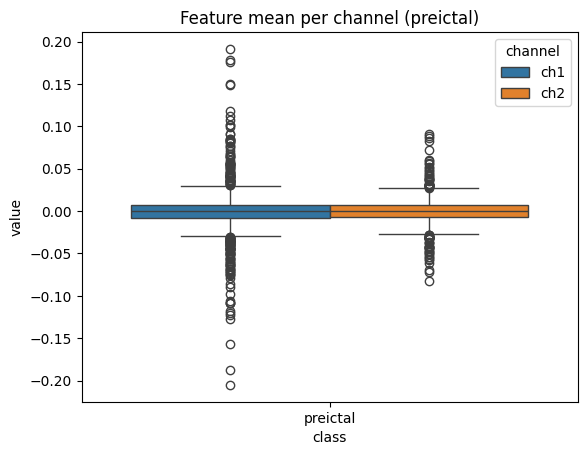

In [20]:
# TEST with only one feature
feat_ch1 = "mean_EEG_SQ_D_SQ_C"
feat_ch2 = "mean_EEG_SQ_P_SQ_C"

df_boxplot_PREICTAL_test_MEAN = pd.DataFrame({
    "value": pd.concat([group_1_PREICTAL[feat_ch1], group_1_PREICTAL[feat_ch2]], axis=0),
    "channel": ["ch1"] * len(group_1_PREICTAL) + ["ch2"] * len(group_1_PREICTAL),
    "class": pd.concat([group_1_PREICTAL["class_label"], group_1_PREICTAL["class_label"]], axis=0)
})
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df_boxplot_PREICTAL_test_MEAN,
    x="class",
    y="value",
    hue="channel"
)

plt.xticks([0], ["preictal"])  
plt.title("Feature mean per channel (preictal)")
plt.show()

#### 2.1 Test box-plot. Per feature comparission by group (ictal vs. preictal)

In [26]:
# Imports + configuración + sanity check
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# -------------------------------
# Parameters
# -------------------------------
alpha = 0.05
# difference is significative when : p_value < 0.05
# -------------------------------
# Sanity checks
# -------------------------------

# Check that feature_cols exists and is not empty
print("Number of feature columns:", len(feature_cols))

# Check dataframe shapes
print("Preictal dataframe shape:", group_1_PREICTAL.shape)
print("Seizure dataframe shape:", group_2_SEIZURE.shape)

# Check first few feature columns
print("\nFirst 5 feature columns:")
print(feature_cols[:5])

# -------------------------------
# Check that all feature columns exist in both dataframes
# -------------------------------

missing_in_preictal = [col for col in feature_cols if col not in group_1_PREICTAL.columns]
missing_in_seizure = [col for col in feature_cols if col not in group_2_SEIZURE.columns]

print("Features missing in PREICTAL dataframe:", len(missing_in_preictal))
print("Features missing in SEIZURE dataframe:", len(missing_in_seizure))

if len(missing_in_preictal) > 0:
    print("\nMissing in PREICTAL:")
    print(missing_in_preictal)

if len(missing_in_seizure) > 0:
    print("\nMissing in SEIZURE:")
    print(missing_in_seizure)

if len(missing_in_preictal) == 0 and len(missing_in_seizure) == 0:
    print("\nAll feature columns are present in both dataframes ✔️")


Number of feature columns: 28
Preictal dataframe shape: (1047, 41)
Seizure dataframe shape: (1102, 41)

First 5 feature columns:
['mean_EEG_SQ_D_SQ_C', 'std_EEG_SQ_D_SQ_C', 'var_EEG_SQ_D_SQ_C', 'rms_EEG_SQ_D_SQ_C', 'ptp_EEG_SQ_D_SQ_C']
Features missing in PREICTAL dataframe: 0
Features missing in SEIZURE dataframe: 0

All feature columns are present in both dataframes ✔️


Testing feature: mean_EEG_SQ_D_SQ_C
Number of preictal values: 1047
Number of seizure values: 1102

First preictal values:
0    0.008743
1   -0.003641
2   -0.000685
3   -0.005067
4   -0.008477
Name: mean_EEG_SQ_D_SQ_C, dtype: float32

First seizure values:
31   -0.036055
32    0.035934
33    0.022185
34   -0.028162
35    0.005231
Name: mean_EEG_SQ_D_SQ_C, dtype: float32
      value     label
0  0.008743  preictal
1 -0.003641  preictal
2 -0.000685  preictal
3 -0.005067  preictal
4 -0.008477  preictal

Shape of df_plot: (2149, 2)

Label counts:
label
seizure     1102
preictal    1047
Name: count, dtype: int64


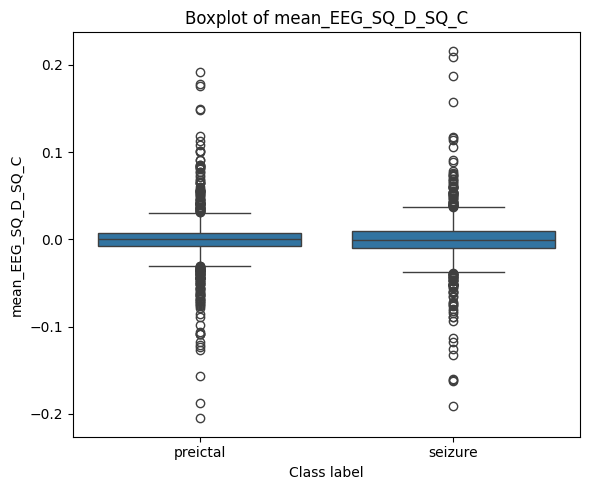

In [30]:
# -------------------------------
# Select one feature to test
# -------------------------------

feature = feature_cols[0]

print("Testing feature:", feature)
# -------------------------------
# Extract values for that feature from each label group
# -------------------------------

preictal_values = group_1_PREICTAL[feature].dropna()
seizure_values = group_2_SEIZURE[feature].dropna()

print("Number of preictal values:", len(preictal_values))
print("Number of seizure values:", len(seizure_values))

print("\nFirst preictal values:")
print(preictal_values.head())

print("\nFirst seizure values:")
print(seizure_values.head())

# -------------------------------
# Create long-format dataframe for plotting
# -------------------------------

df_plot = pd.DataFrame({
    "value": pd.concat([preictal_values, seizure_values], axis=0),
    "label": (
        ["preictal"] * len(preictal_values) +
        ["seizure"] * len(seizure_values)
    )
})

print(df_plot.head())
print("\nShape of df_plot:", df_plot.shape)
print("\nLabel counts:")
print(df_plot["label"].value_counts())

# -------------------------------
# Boxplot for one feature
# -------------------------------

plt.figure(figsize=(6, 5))

sns.boxplot(
    data=df_plot,
    x="label",
    y="value"
)

plt.title(f"Boxplot of {feature}")
plt.xlabel("Class label")
plt.ylabel(feature)

plt.tight_layout()
plt.show()

Feature: mean_EEG_SQ_D_SQ_C
Mann-Whitney U statistic: 582146.0
p-value: 0.7150802878564748
Result: No significant difference between preictal and seizure


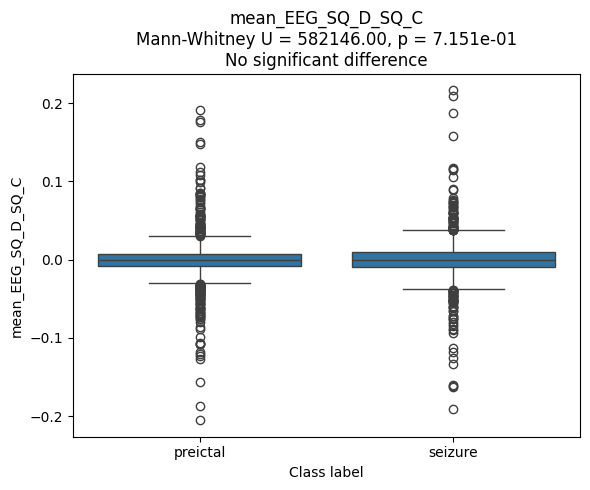

In [33]:
# -------------------------------
# Mann-Whitney U test for one feature
# -------------------------------

stat, p_value = mannwhitneyu(
    preictal_values,
    seizure_values,
    alternative="two-sided"
)

print("Feature:", feature)
print("Mann-Whitney U statistic:", stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Result: Significant difference between preictal and seizure")
else:
    print("Result: No significant difference between preictal and seizure")
    # -------------------------------
# Boxplot + Mann-Whitney result in title
# -------------------------------

if p_value < alpha:
    test_result = "Significant difference"
else:
    test_result = "No significant difference"

plt.figure(figsize=(6, 5))

sns.boxplot(
    data=df_plot,
    x="label",
    y="value"
)

plt.title(
    f"{feature}\n"
    f"Mann-Whitney U = {stat:.2f}, p = {p_value:.3e}\n"
    f"{test_result}"
)

plt.xlabel("Class label")
plt.ylabel(feature)

plt.tight_layout()
plt.show()


#### 2.2 Box-plot + Mann-W. of all features
plots by feature per category (ictal vs. preictal)

Plotting feature: mean_EEG_SQ_D_SQ_C


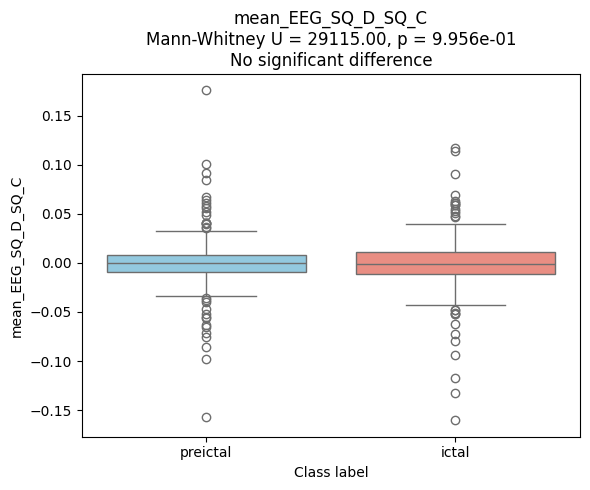

Plotting feature: std_EEG_SQ_D_SQ_C


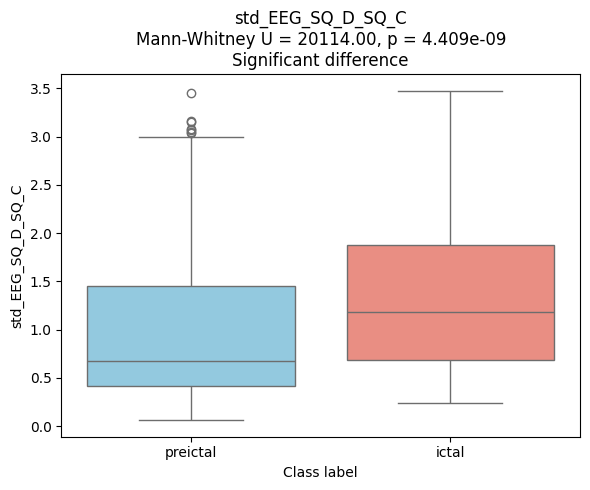

Plotting feature: var_EEG_SQ_D_SQ_C


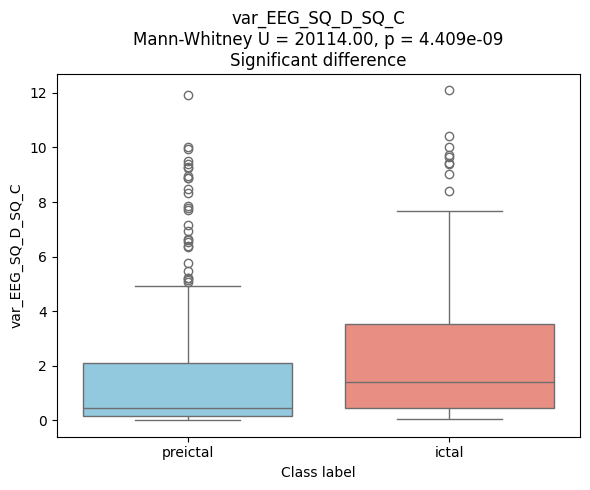

Plotting feature: rms_EEG_SQ_D_SQ_C


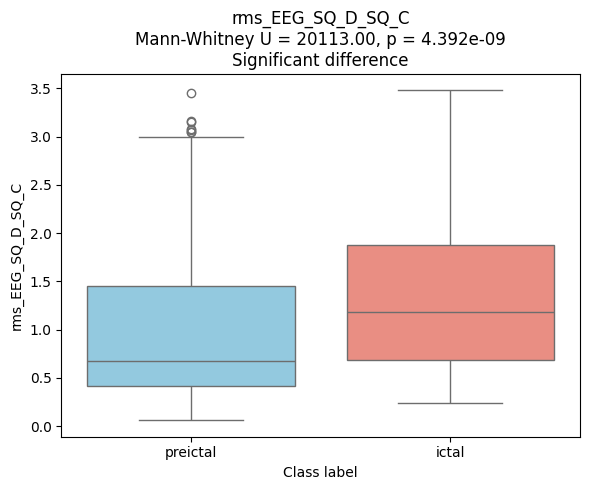

Plotting feature: ptp_EEG_SQ_D_SQ_C


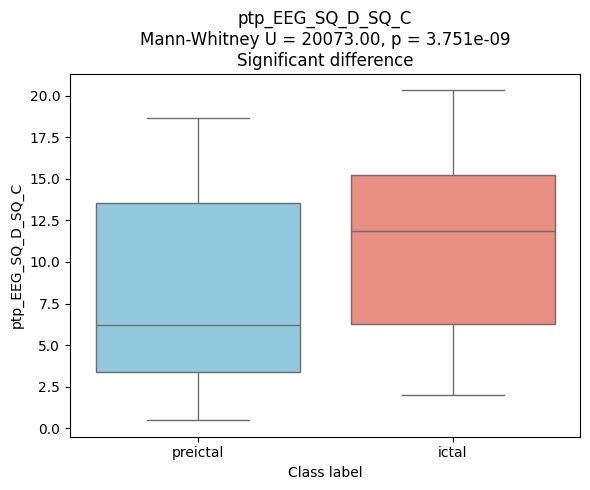

Plotting feature: line_length_EEG_SQ_D_SQ_C


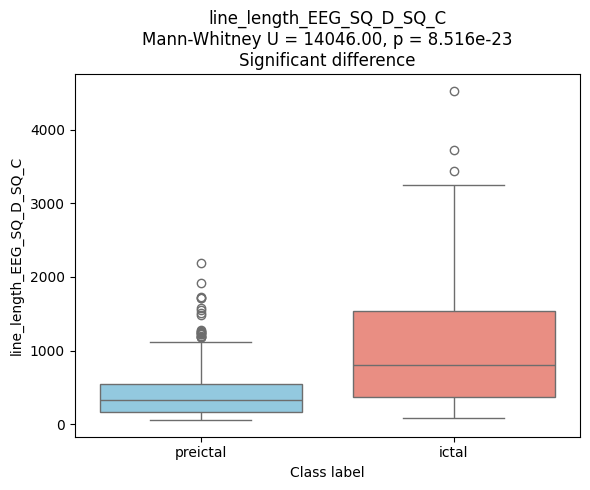

Plotting feature: skew_EEG_SQ_D_SQ_C


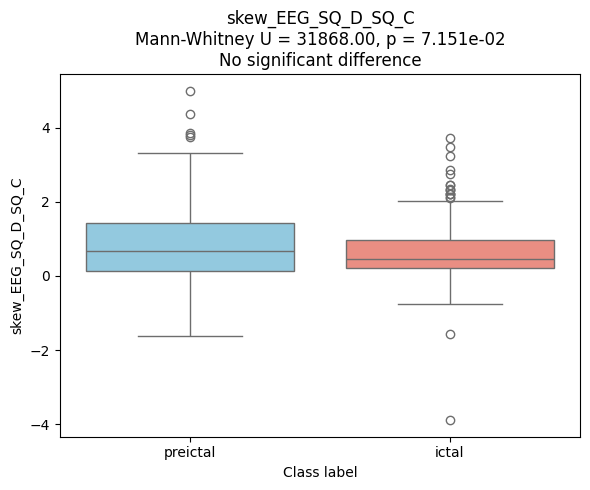

Plotting feature: kurtosis_EEG_SQ_D_SQ_C


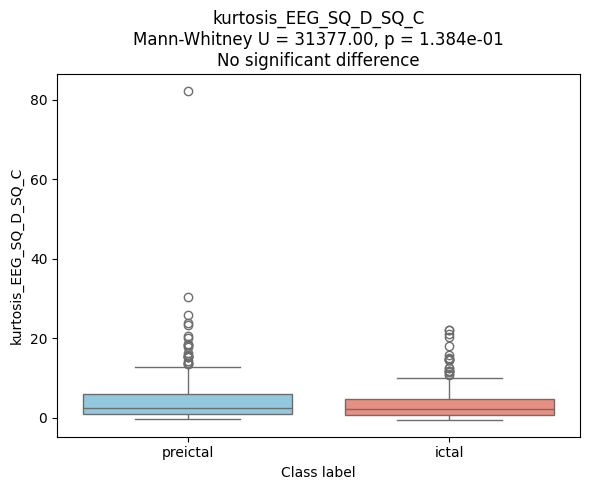

Plotting feature: mean_EEG_SQ_P_SQ_C


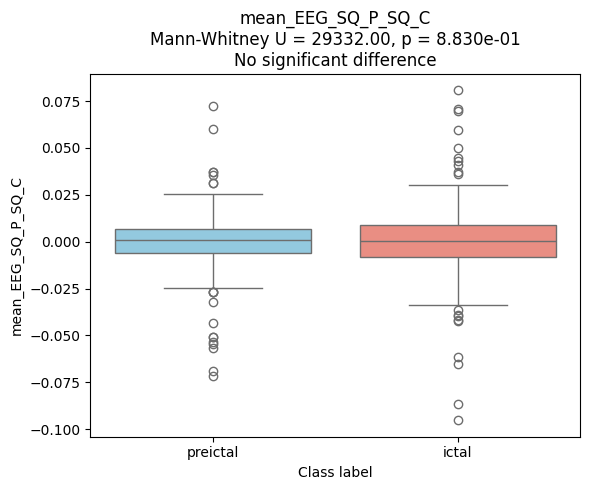

Plotting feature: std_EEG_SQ_P_SQ_C


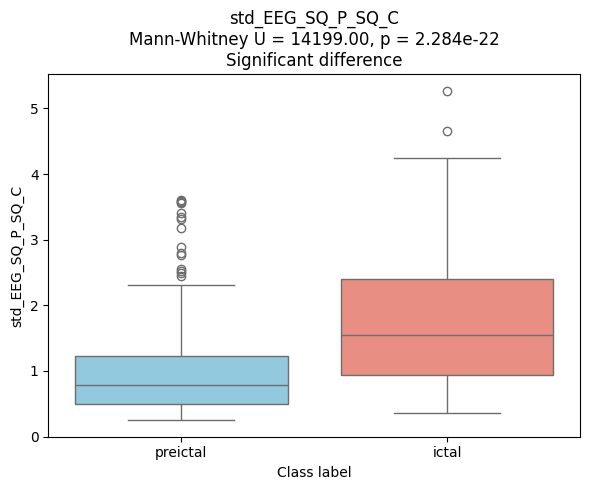

Plotting feature: var_EEG_SQ_P_SQ_C


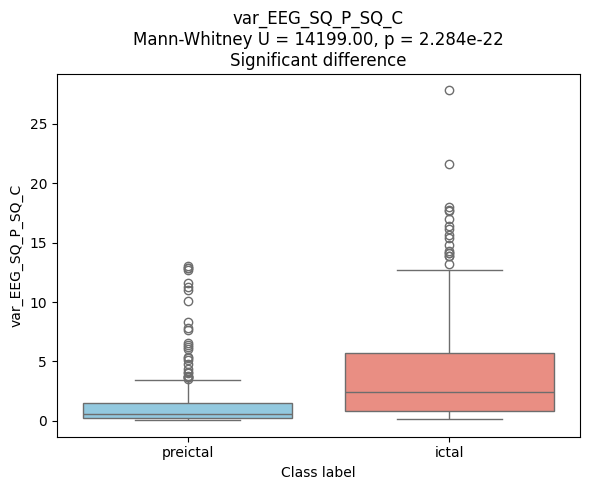

Plotting feature: rms_EEG_SQ_P_SQ_C


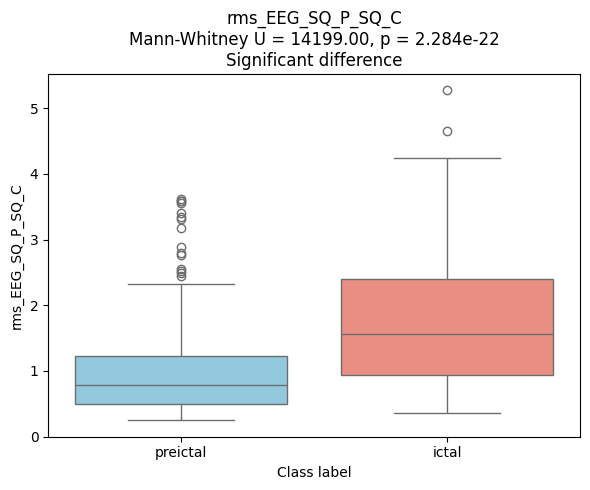

Plotting feature: ptp_EEG_SQ_P_SQ_C


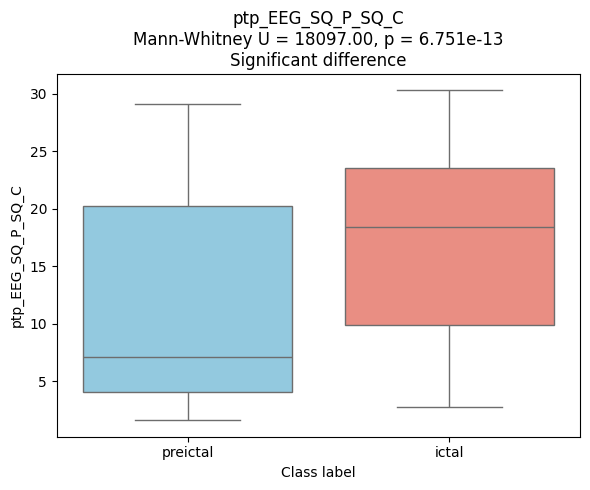

Plotting feature: line_length_EEG_SQ_P_SQ_C


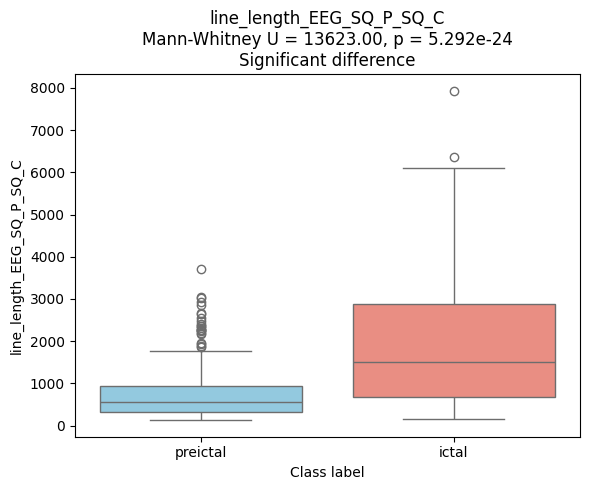

Plotting feature: skew_EEG_SQ_P_SQ_C


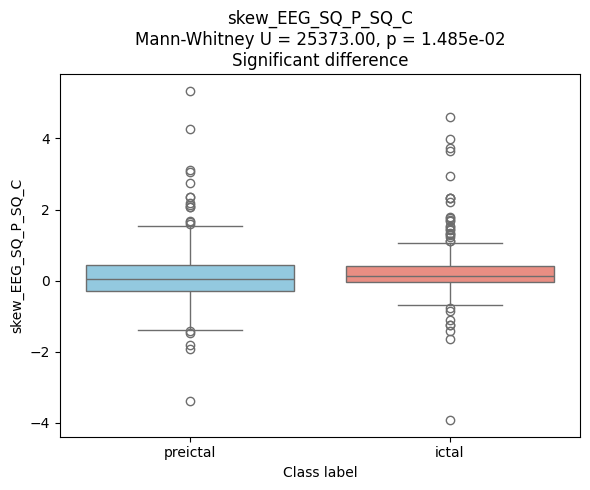

Plotting feature: kurtosis_EEG_SQ_P_SQ_C


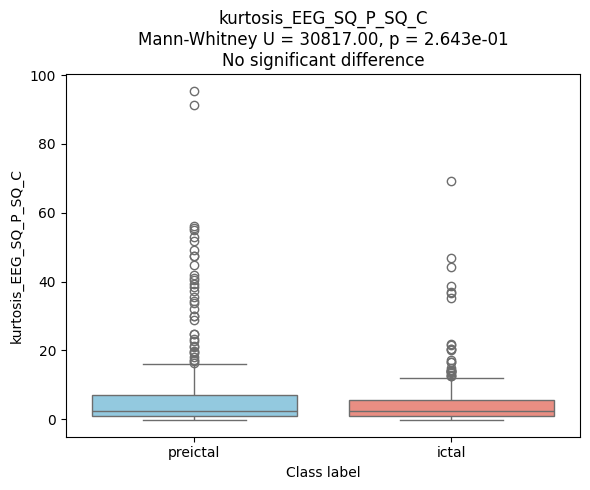

Plotting feature: delta_power_EEG_SQ_D_SQ_C


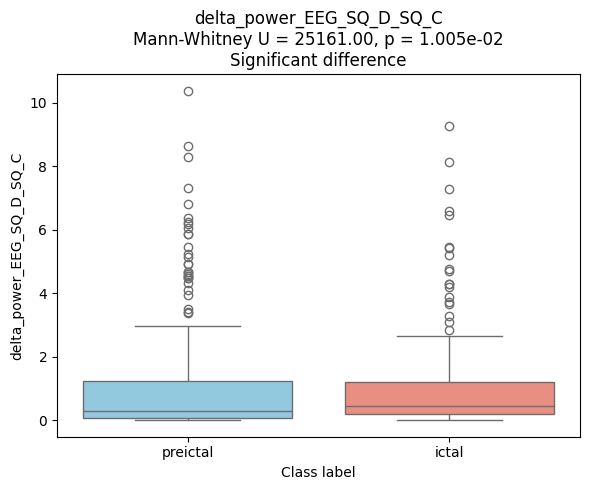

Plotting feature: theta_power_EEG_SQ_D_SQ_C


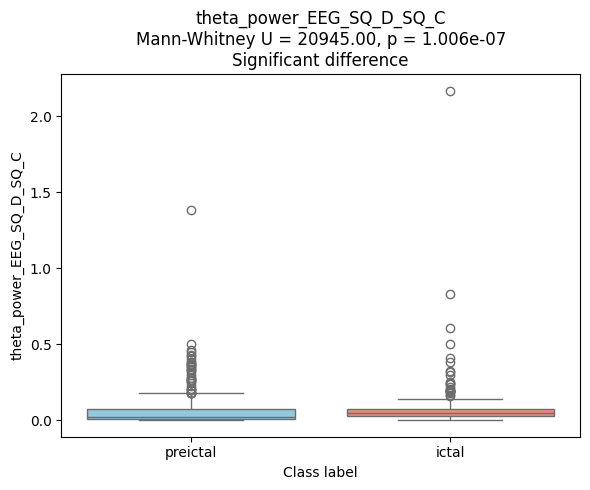

Plotting feature: alpha_power_EEG_SQ_D_SQ_C


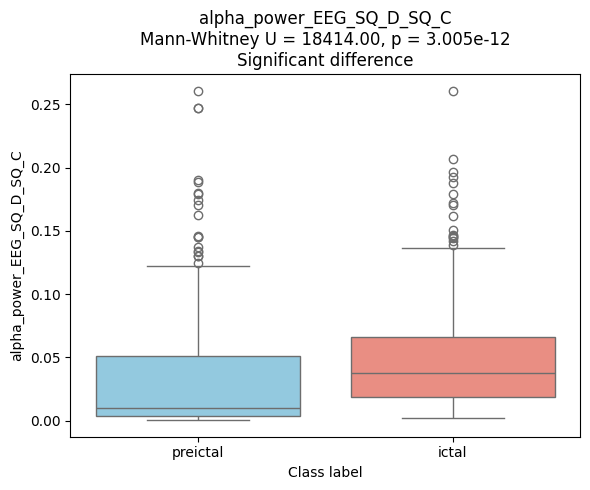

Plotting feature: beta_power_EEG_SQ_D_SQ_C


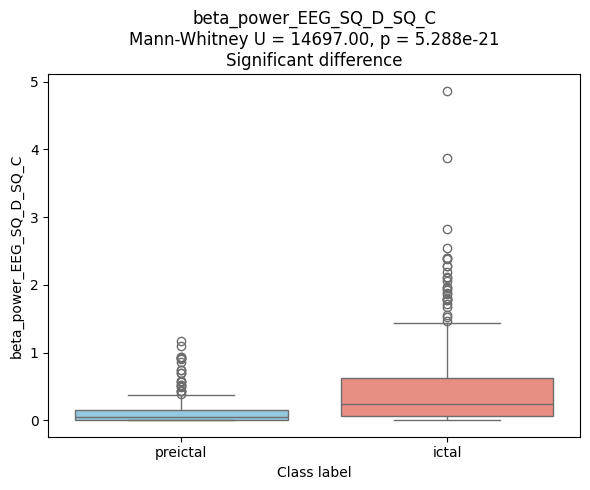

Plotting feature: gamma_power_EEG_SQ_D_SQ_C


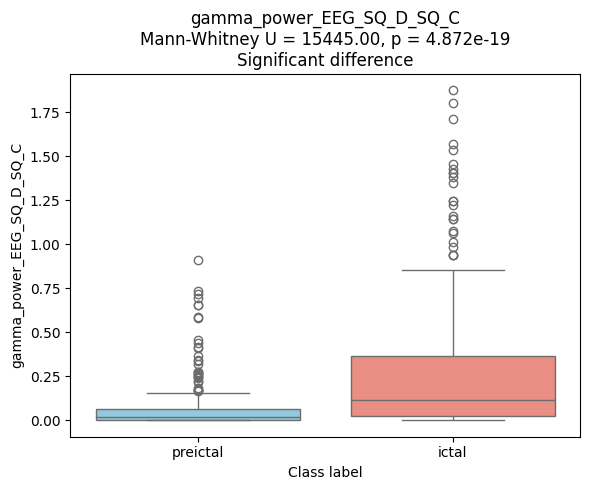

Plotting feature: peak_frequency_EEG_SQ_D_SQ_C


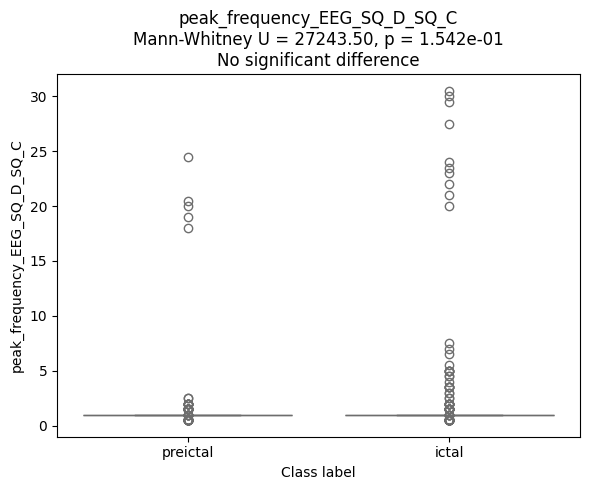

Plotting feature: delta_power_EEG_SQ_P_SQ_C


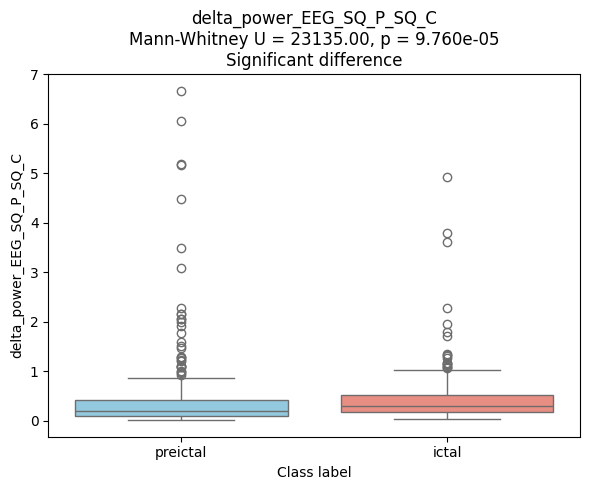

Plotting feature: theta_power_EEG_SQ_P_SQ_C


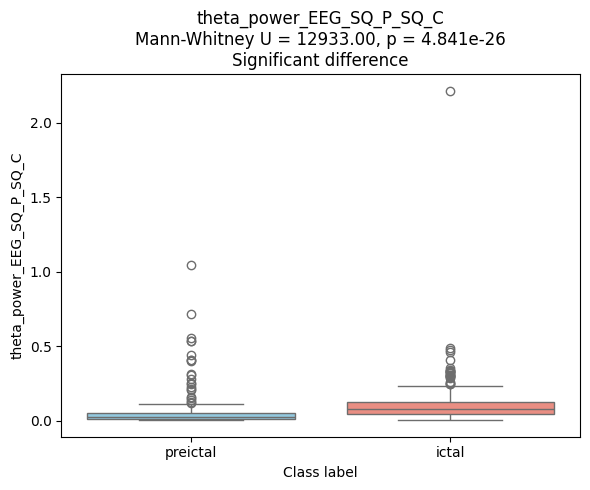

Plotting feature: alpha_power_EEG_SQ_P_SQ_C


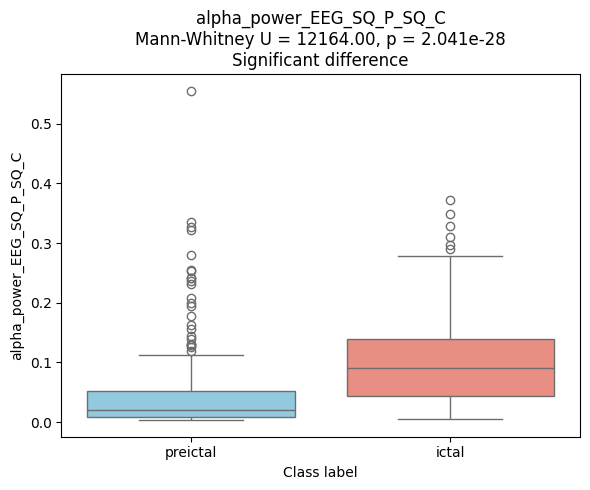

Plotting feature: beta_power_EEG_SQ_P_SQ_C


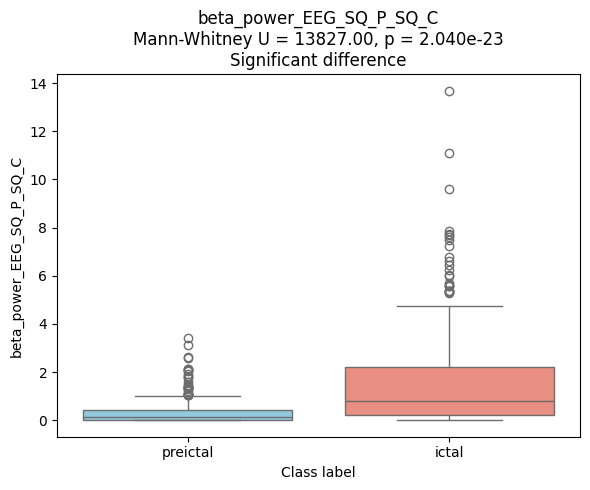

Plotting feature: gamma_power_EEG_SQ_P_SQ_C


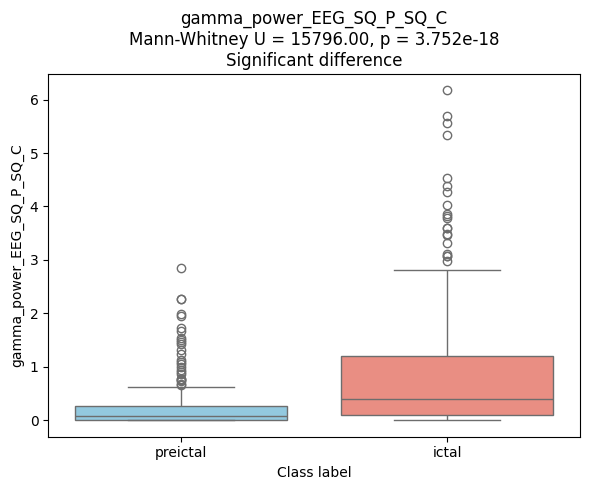

Plotting feature: peak_frequency_EEG_SQ_P_SQ_C


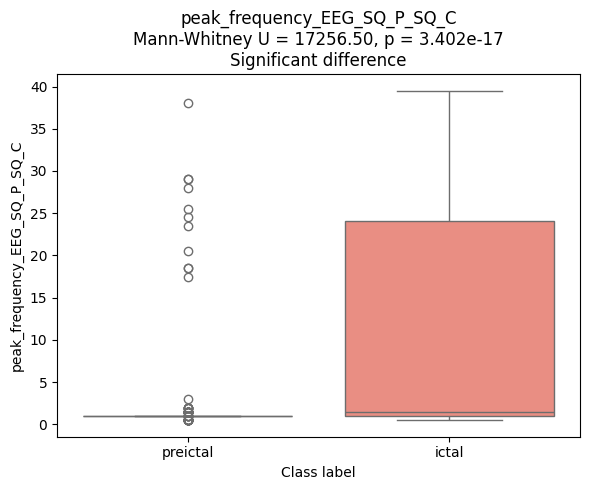

,feature,n_preictal,n_ictal,mannwhitney_U,p_value,result
24,alpha_power_EEG_SQ_P_SQ_C,231,252,12164.0,2.041385e-28,Significant difference
23,theta_power_EEG_SQ_P_SQ_C,231,252,12933.0,4.840631e-26,Significant difference
13,line_length_EEG_SQ_P_SQ_C,231,252,13623.0,5.291525e-24,Significant difference
25,beta_power_EEG_SQ_P_SQ_C,231,252,13827.0,2.039889e-23,Significant difference
5,line_length_EEG_SQ_D_SQ_C,231,252,14046.0,8.516013e-23,Significant difference
10,var_EEG_SQ_P_SQ_C,231,252,14199.0,2.283569e-22,Significant difference
9,std_EEG_SQ_P_SQ_C,231,252,14199.0,2.283569e-22,Significant difference
11,rms_EEG_SQ_P_SQ_C,231,252,14199.0,2.283569e-22,Significant difference
19,beta_power_EEG_SQ_D_SQ_C,231,252,14697.0,5.287630e-21,Significant difference
20,gamma_power_EEG_SQ_D_SQ_C,231,252,15445.0,4.871904e-19,Significant difference


In [106]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
# -------------------------------
# Parameters
# -------------------------------
alpha = 0.05

# Colors for each class
palette = {
    "preictal": "skyblue",
    "ictal": "salmon"
}

# Store Mann-Whitney results
mannwhitney_results = []

# -------------------------------
# Loop through all feature columns
# -------------------------------
for feature in feature_cols:

    print(f"Plotting feature: {feature}")

    # -------------------------------
    # Extract values from both groups
    # -------------------------------
    preictal_values = group_1_PREICTAL[feature]
    ictal_values = group_2_SEIZURE[feature]

    # Convert to numeric and remove NaN / infinite values
    preictal_values = pd.to_numeric(preictal_values, errors="coerce")
    ictal_values = pd.to_numeric(ictal_values, errors="coerce")

    preictal_values = preictal_values.replace([np.inf, -np.inf], np.nan).dropna()
    ictal_values = ictal_values.replace([np.inf, -np.inf], np.nan).dropna()

    # -------------------------------
    # Skip feature if one group has no valid values
    # -------------------------------
    if len(preictal_values) == 0 or len(ictal_values) == 0:
        print(f"Skipping {feature}: not enough valid values")
        continue

    # -------------------------------
    # Create long-format dataframe for plotting
    # -------------------------------
    df_plot = pd.DataFrame({
        "value": pd.concat([preictal_values, ictal_values], axis=0),
        "label": (
            ["preictal"] * len(preictal_values) +
            ["ictal"] * len(ictal_values)
        )
    })

    # -------------------------------
    # Mann-Whitney U test
    # -------------------------------
    stat, p_value = mannwhitneyu(
        preictal_values,
        ictal_values,
        alternative="two-sided"
    )

    if p_value < alpha:
        test_result = "Significant difference"
    else:
        test_result = "No significant difference"

    # Save result
    mannwhitney_results.append({
        "feature": feature,
        "n_preictal": len(preictal_values),
        "n_ictal": len(ictal_values),
        "mannwhitney_U": stat,
        "p_value": p_value,
        "result": test_result
    })

    # -------------------------------
    # Boxplot
    # -------------------------------
    plt.figure(figsize=(6, 5))

    sns.boxplot(
        data=df_plot,
        x="label",
        y="value",
        hue="label",
        palette=palette,
        order=["preictal", "ictal"],
        legend=False
    )

    plt.title(
        f"{feature}\n"
        f"Mann-Whitney U = {stat:.2f}, p = {p_value:.3e}\n"
        f"{test_result}"
    )

    plt.xlabel("Class label")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

# -------------------------------
# Convert statistical results to dataframe
# -------------------------------
df_mannwhitney_results = pd.DataFrame(mannwhitney_results)

# Sort by p-value
df_mannwhitney_results = df_mannwhitney_results.sort_values("p_value")

df_mannwhitney_results

### 3 Violin plots + Mann-W.

Plotting feature: mean_EEG_SQ_D_SQ_C


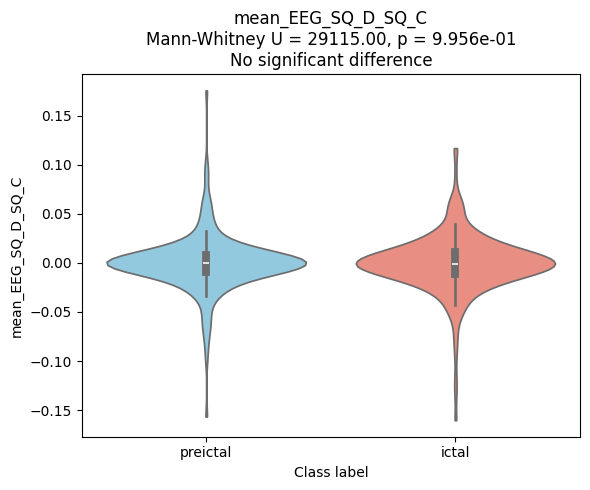

Plotting feature: std_EEG_SQ_D_SQ_C


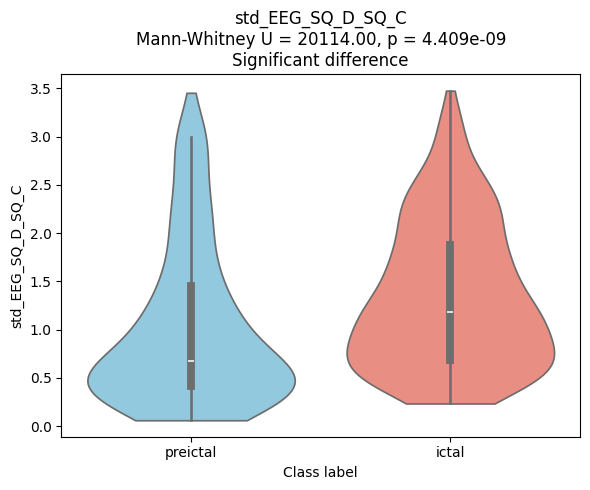

Plotting feature: var_EEG_SQ_D_SQ_C


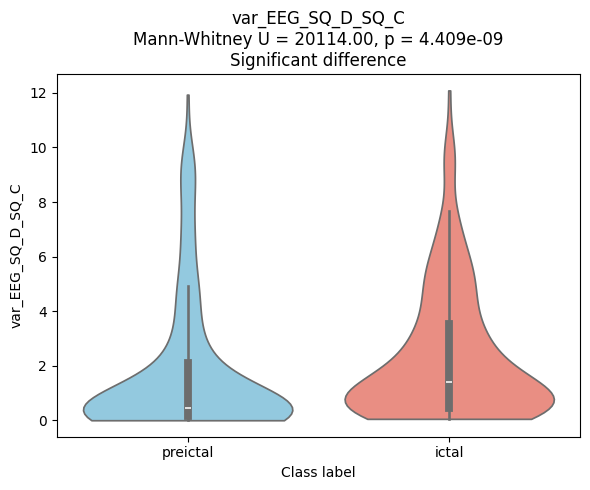

Plotting feature: rms_EEG_SQ_D_SQ_C


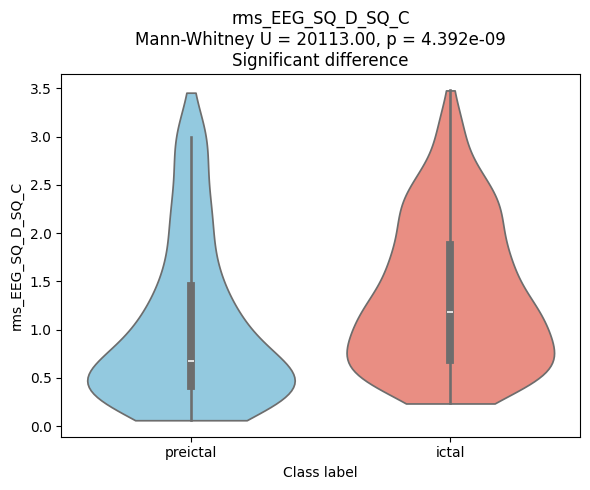

Plotting feature: ptp_EEG_SQ_D_SQ_C


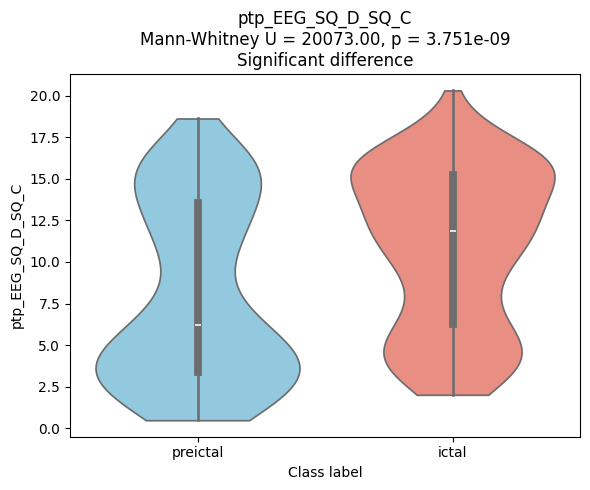

Plotting feature: line_length_EEG_SQ_D_SQ_C


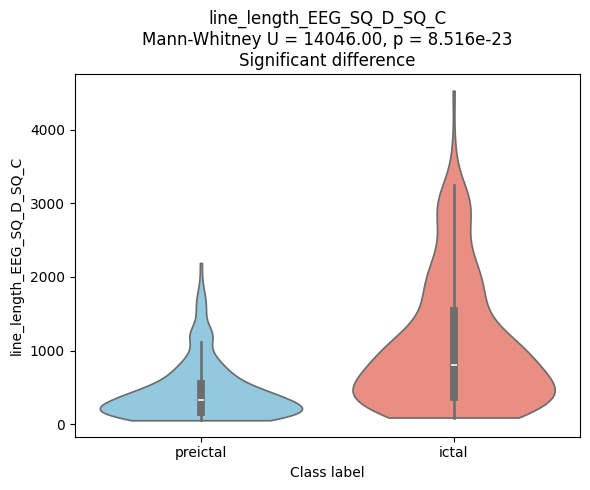

Plotting feature: skew_EEG_SQ_D_SQ_C


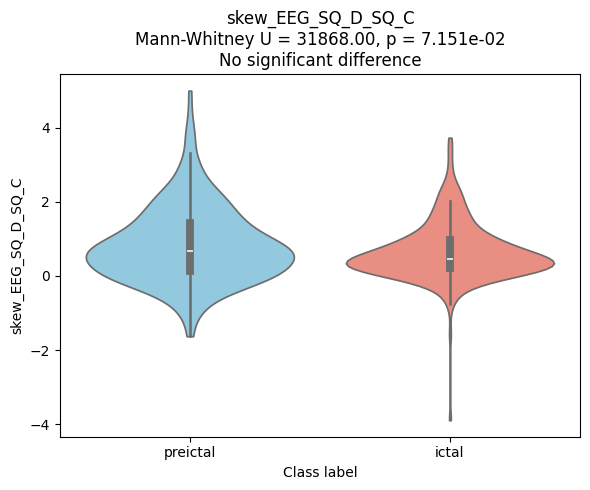

Plotting feature: kurtosis_EEG_SQ_D_SQ_C


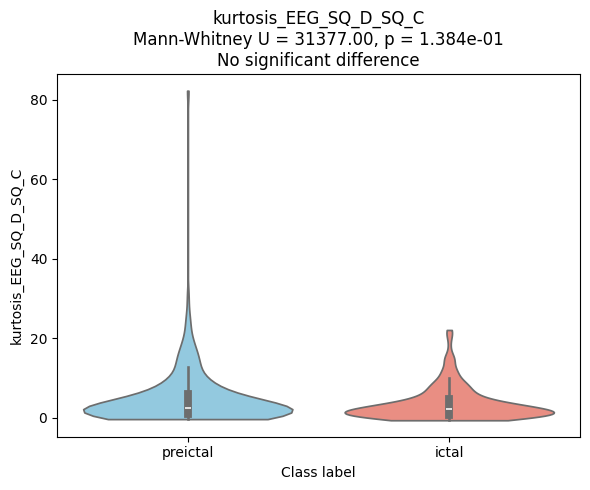

Plotting feature: mean_EEG_SQ_P_SQ_C


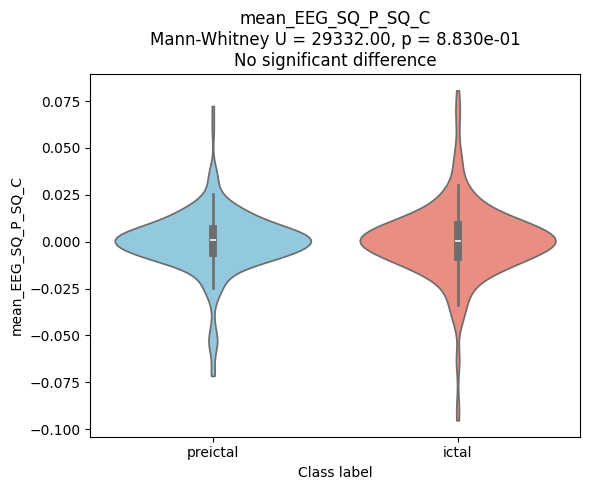

Plotting feature: std_EEG_SQ_P_SQ_C


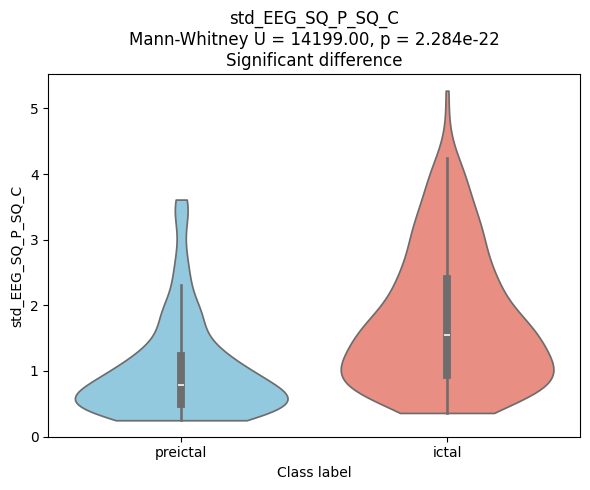

Plotting feature: var_EEG_SQ_P_SQ_C


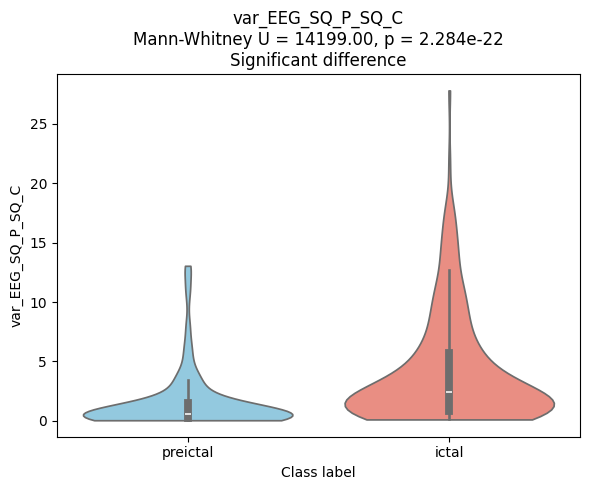

Plotting feature: rms_EEG_SQ_P_SQ_C


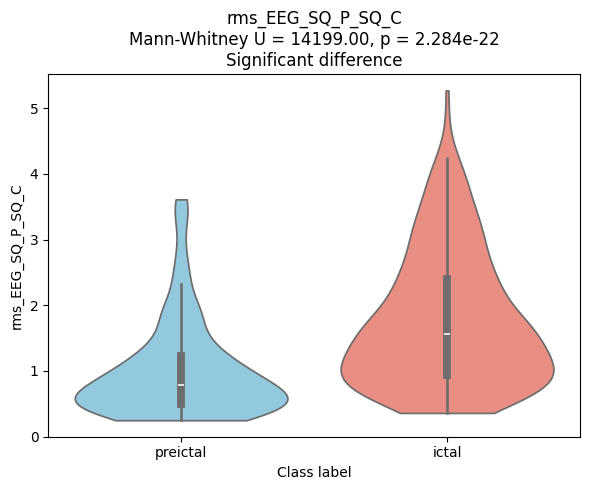

Plotting feature: ptp_EEG_SQ_P_SQ_C


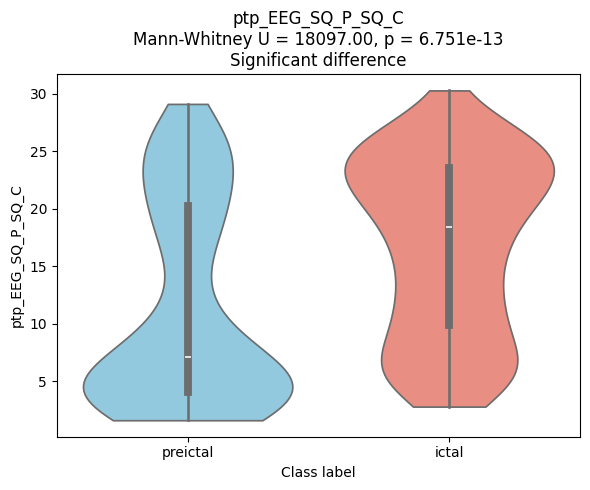

Plotting feature: line_length_EEG_SQ_P_SQ_C


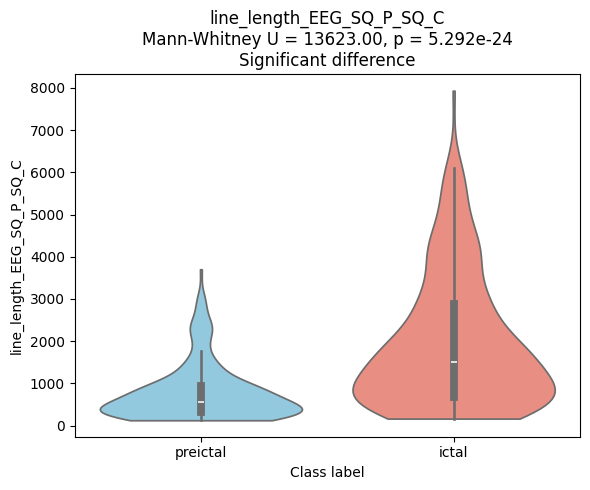

Plotting feature: skew_EEG_SQ_P_SQ_C


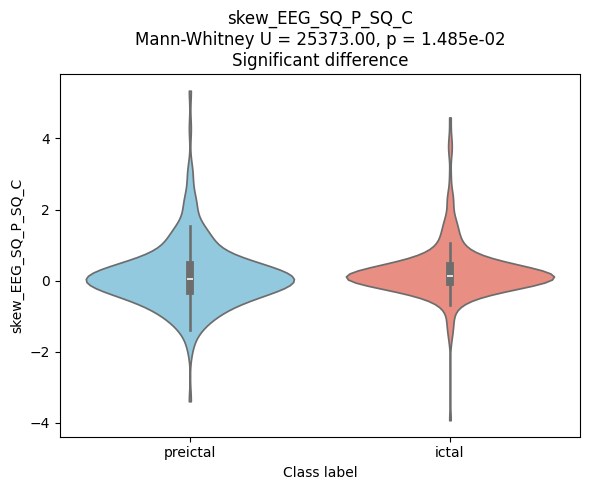

Plotting feature: kurtosis_EEG_SQ_P_SQ_C


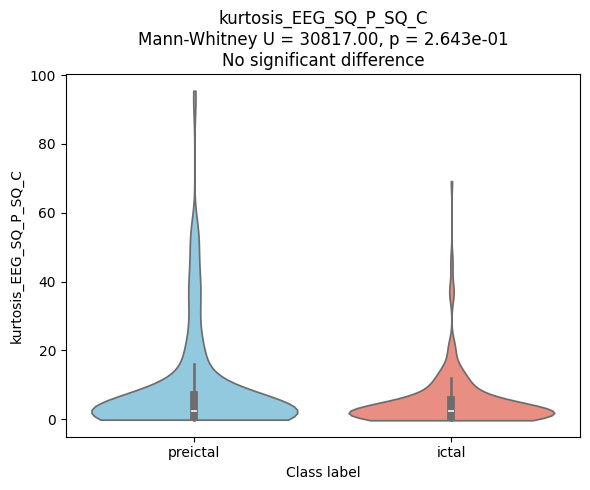

Plotting feature: delta_power_EEG_SQ_D_SQ_C


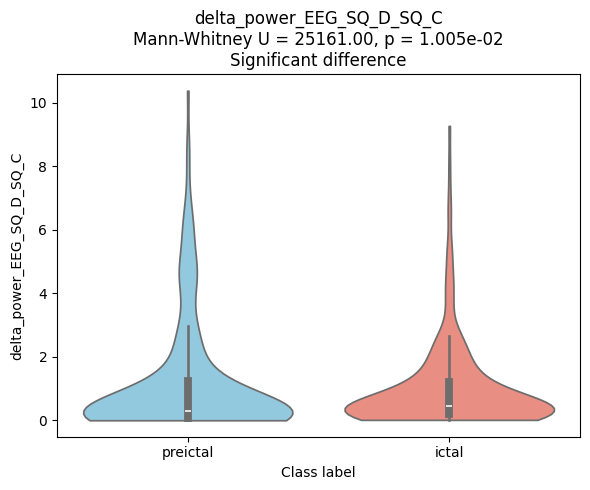

Plotting feature: theta_power_EEG_SQ_D_SQ_C


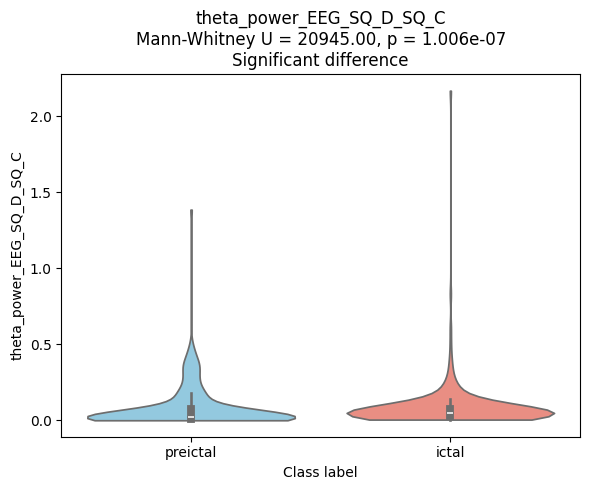

Plotting feature: alpha_power_EEG_SQ_D_SQ_C


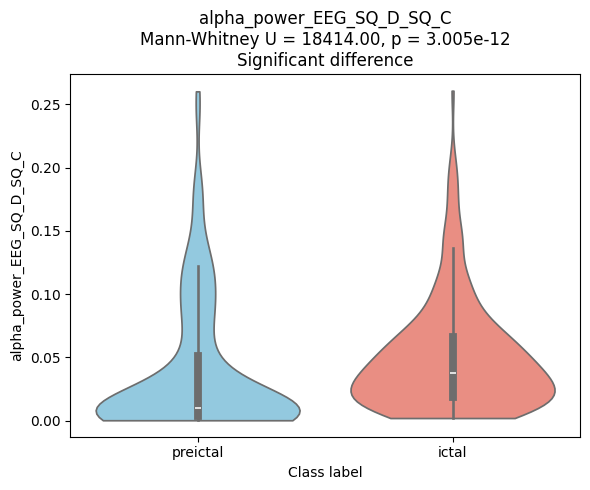

Plotting feature: beta_power_EEG_SQ_D_SQ_C


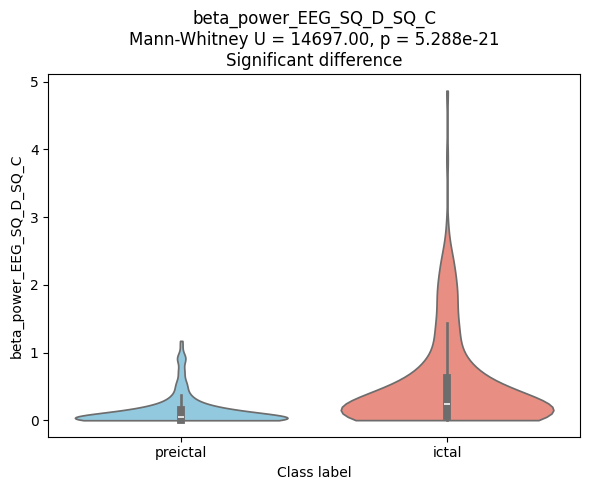

Plotting feature: gamma_power_EEG_SQ_D_SQ_C


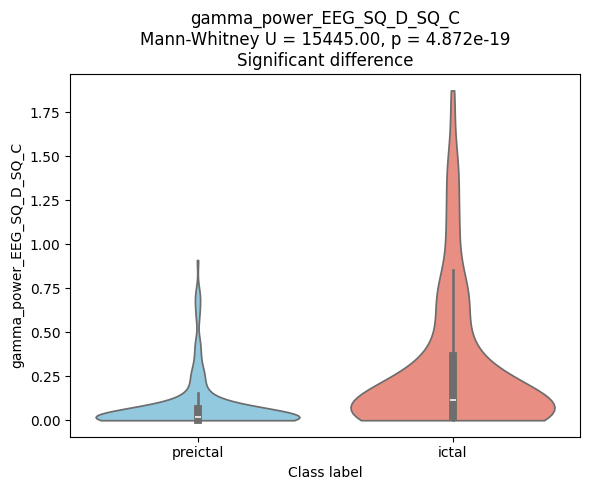

Plotting feature: peak_frequency_EEG_SQ_D_SQ_C


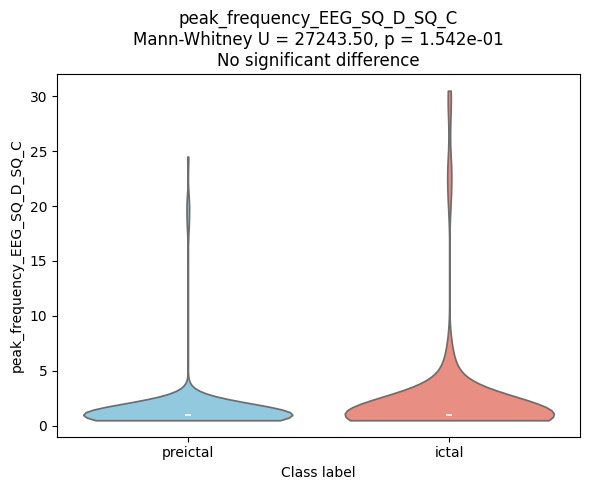

Plotting feature: delta_power_EEG_SQ_P_SQ_C


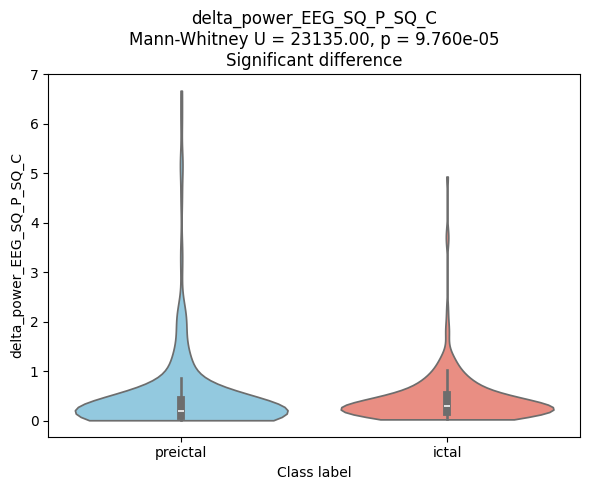

Plotting feature: theta_power_EEG_SQ_P_SQ_C


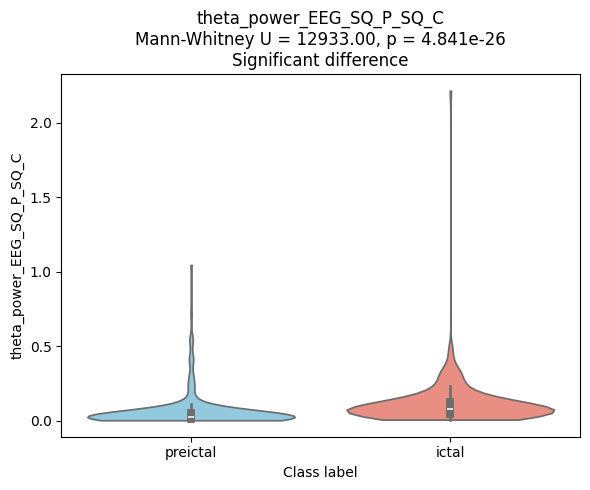

Plotting feature: alpha_power_EEG_SQ_P_SQ_C


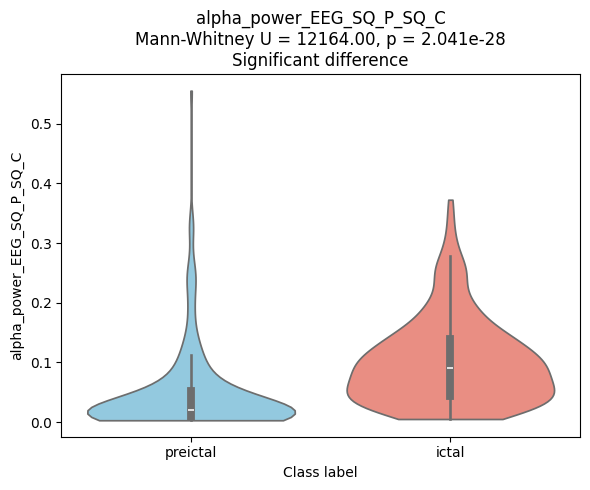

Plotting feature: beta_power_EEG_SQ_P_SQ_C


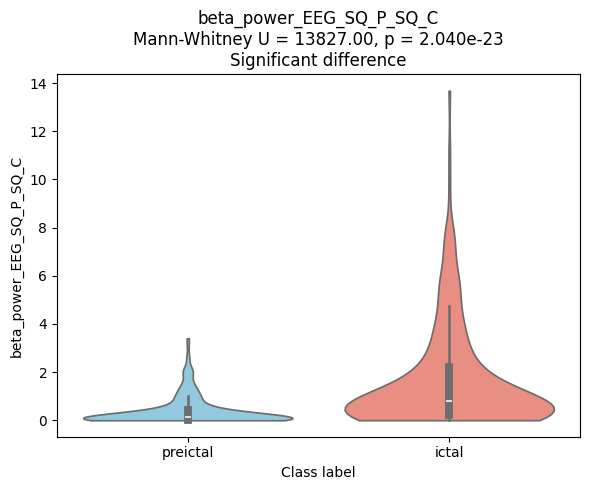

Plotting feature: gamma_power_EEG_SQ_P_SQ_C


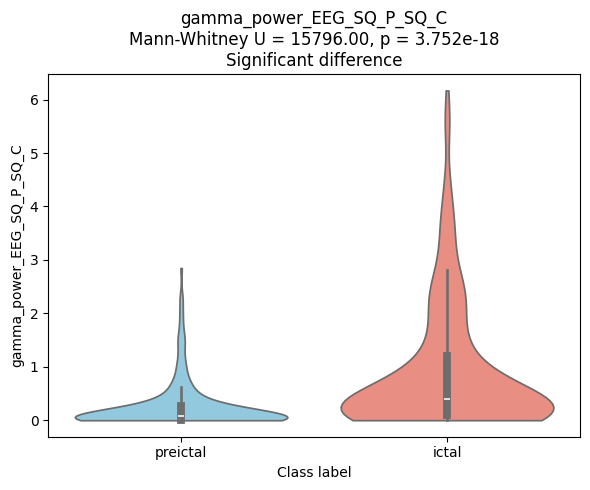

Plotting feature: peak_frequency_EEG_SQ_P_SQ_C


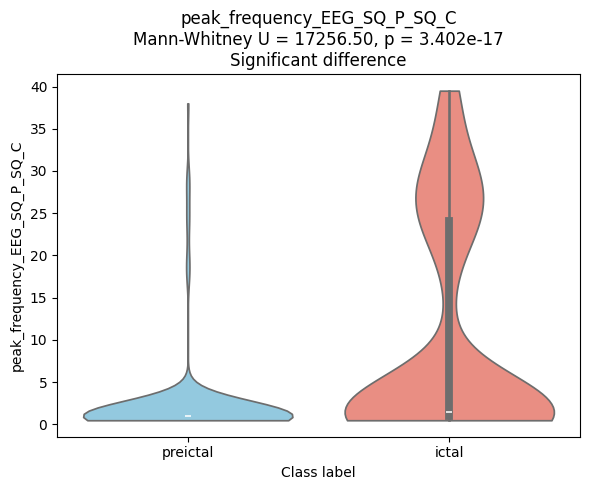

,feature,n_preictal,n_ictal,mannwhitney_U,p_value,result
24,alpha_power_EEG_SQ_P_SQ_C,231,252,12164.0,2.041385e-28,Significant difference
23,theta_power_EEG_SQ_P_SQ_C,231,252,12933.0,4.840631e-26,Significant difference
13,line_length_EEG_SQ_P_SQ_C,231,252,13623.0,5.291525e-24,Significant difference
25,beta_power_EEG_SQ_P_SQ_C,231,252,13827.0,2.039889e-23,Significant difference
5,line_length_EEG_SQ_D_SQ_C,231,252,14046.0,8.516013e-23,Significant difference
10,var_EEG_SQ_P_SQ_C,231,252,14199.0,2.283569e-22,Significant difference
9,std_EEG_SQ_P_SQ_C,231,252,14199.0,2.283569e-22,Significant difference
11,rms_EEG_SQ_P_SQ_C,231,252,14199.0,2.283569e-22,Significant difference
19,beta_power_EEG_SQ_D_SQ_C,231,252,14697.0,5.287630e-21,Significant difference
20,gamma_power_EEG_SQ_D_SQ_C,231,252,15445.0,4.871904e-19,Significant difference


In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# -------------------------------
# Parameters
# -------------------------------
alpha = 0.05

# Colors for each class
palette = {
    "preictal": "skyblue",
    "ictal": "salmon"
}

# Store Mann-Whitney results
mannwhitney_results_violin = []

# -------------------------------
# Loop through all feature columns
# -------------------------------
for feature in feature_cols:

    print(f"Plotting feature: {feature}")

    # -------------------------------
    # Extract values from both groups
    # -------------------------------
    preictal_values = group_1_PREICTAL[feature]
    ictal_values = group_2_SEIZURE[feature]

    # Convert to numeric and remove NaN / infinite values
    preictal_values = pd.to_numeric(preictal_values, errors="coerce")
    ictal_values = pd.to_numeric(ictal_values, errors="coerce")

    preictal_values = preictal_values.replace([np.inf, -np.inf], np.nan).dropna()
    ictal_values = ictal_values.replace([np.inf, -np.inf], np.nan).dropna()

    # -------------------------------
    # Skip feature if one group has no valid values
    # -------------------------------
    if len(preictal_values) == 0 or len(ictal_values) == 0:
        print(f"Skipping {feature}: not enough valid values")
        continue

    # -------------------------------
    # Create long-format dataframe for plotting
    # -------------------------------
    df_plot = pd.DataFrame({
        "value": pd.concat([preictal_values, ictal_values], axis=0),
        "label": (
            ["preictal"] * len(preictal_values) +
            ["ictal"] * len(ictal_values)
        )
    })

    # -------------------------------
    # Mann-Whitney U test
    # -------------------------------
    stat, p_value = mannwhitneyu(
        preictal_values,
        ictal_values,
        alternative="two-sided"
    )

    if p_value < alpha:
        test_result = "Significant difference"
    else:
        test_result = "No significant difference"

    # Save result
    mannwhitney_results_violin.append({
        "feature": feature,
        "n_preictal": len(preictal_values),
        "n_ictal": len(ictal_values),
        "mannwhitney_U": stat,
        "p_value": p_value,
        "result": test_result
    })

    # -------------------------------
    # Violin plot
    # -------------------------------
    plt.figure(figsize=(6, 5))

    sns.violinplot(
        data=df_plot,
        x="label",
        y="value",
        hue="label",
        palette=palette,
        order=["preictal", "ictal"],
        legend=False,
        inner="box",
        cut=0
    )

    plt.title(
        f"{feature}\n"
        f"Mann-Whitney U = {stat:.2f}, p = {p_value:.3e}\n"
        f"{test_result}"
    )

    plt.xlabel("Class label")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

# -------------------------------
# Convert statistical results to dataframe
# -------------------------------
df_mannwhitney_results_violin = pd.DataFrame(mannwhitney_results_violin)

# Sort by p-value
df_mannwhitney_results_violin = df_mannwhitney_results_violin.sort_values("p_value")

df_mannwhitney_results_violin

### 4. Analyzing Mann-W results

#### 4.1 Barplot of top features (most significative by Mann-W test)

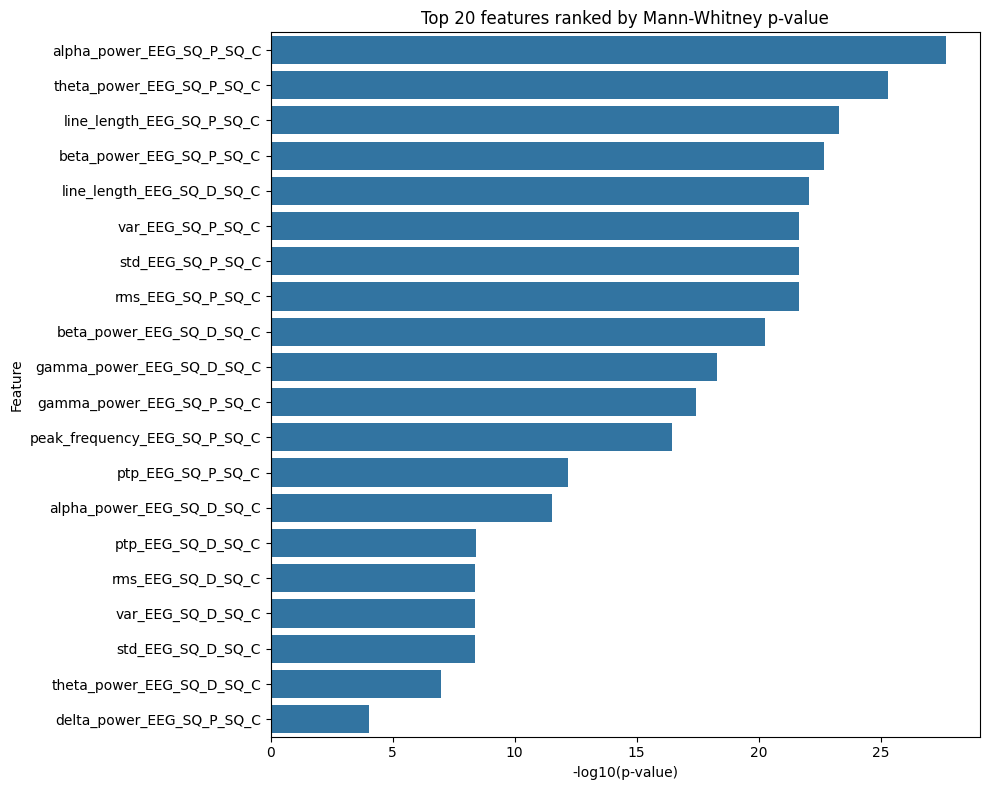

In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Copy results
df_ranked = df_mannwhitney_results.copy()

# Add -log10(p-value)
df_ranked["minus_log10_p"] = -np.log10(df_ranked["p_value"])

# Select top N features
top_n = 20
df_top = df_ranked.head(top_n)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=df_top,
    x="minus_log10_p",
    y="feature"
)

plt.xlabel("-log10(p-value)")
plt.ylabel("Feature")
plt.title(f"Top {top_n} features ranked by Mann-Whitney p-value")

plt.tight_layout()
plt.show()

#### 4.2 Scatter-plot 

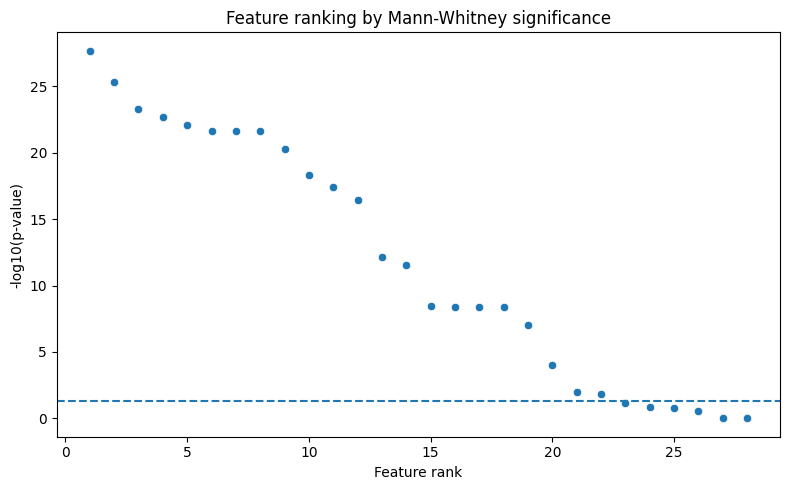

In [12]:
df_ranked = df_ranked.reset_index(drop=True)
df_ranked["rank"] = df_ranked.index + 1

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_ranked,
    x="rank",
    y="minus_log10_p"
)

plt.axhline(-np.log10(0.05), linestyle="--")

plt.xlabel("Feature rank")
plt.ylabel("-log10(p-value)")
plt.title("Feature ranking by Mann-Whitney significance")

plt.tight_layout()
plt.show()

most features are significantly different (pvalue < 0.05)

#### 4.3 Simple bar-plot

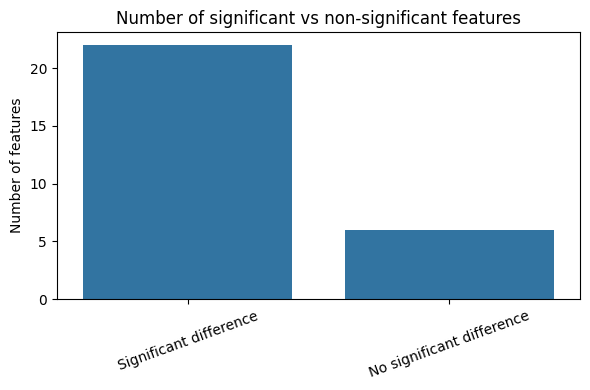

In [13]:

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_mannwhitney_results,
    x="result"
)

plt.xlabel("")
plt.ylabel("Number of features")
plt.title("Number of significant vs non-significant features")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

#### 4.4 Bar-plot of top features per channel

In [16]:
# -------------------------------
# Extract channel and base feature name
# -------------------------------

channel_patterns = [
    "EEG_SQ_D_SQ_C",
    "EEG_SQ_P_SQ_C"
]

def extract_channel(feature_name):
    for ch in channel_patterns:
        if ch in feature_name:
            return ch
    return "unknown"


def extract_base_feature(feature_name):
    base = feature_name
    for ch in channel_patterns:
        base = base.replace(f"_{ch}", "")
        base = base.replace(ch, "")
    return base.rstrip("_")


df_ranked["channel"] = df_ranked["feature"].apply(extract_channel)
df_ranked["base_feature"] = df_ranked["feature"].apply(extract_base_feature)

df_ranked.shape

(28, 10)

In [17]:
# -------------------------------
# Select top N base features
# -------------------------------

top_n = 20

top_base_features = (
    df_ranked
    .groupby("base_feature")["p_value"]
    .min()
    .sort_values()
    .head(top_n)
    .index
)

df_top = df_ranked[df_ranked["base_feature"].isin(top_base_features)].copy()

# Sort plot by significance
df_top["base_feature"] = pd.Categorical(
    df_top["base_feature"],
    categories=top_base_features,
    ordered=True
)

df_top = df_top.sort_values("base_feature")

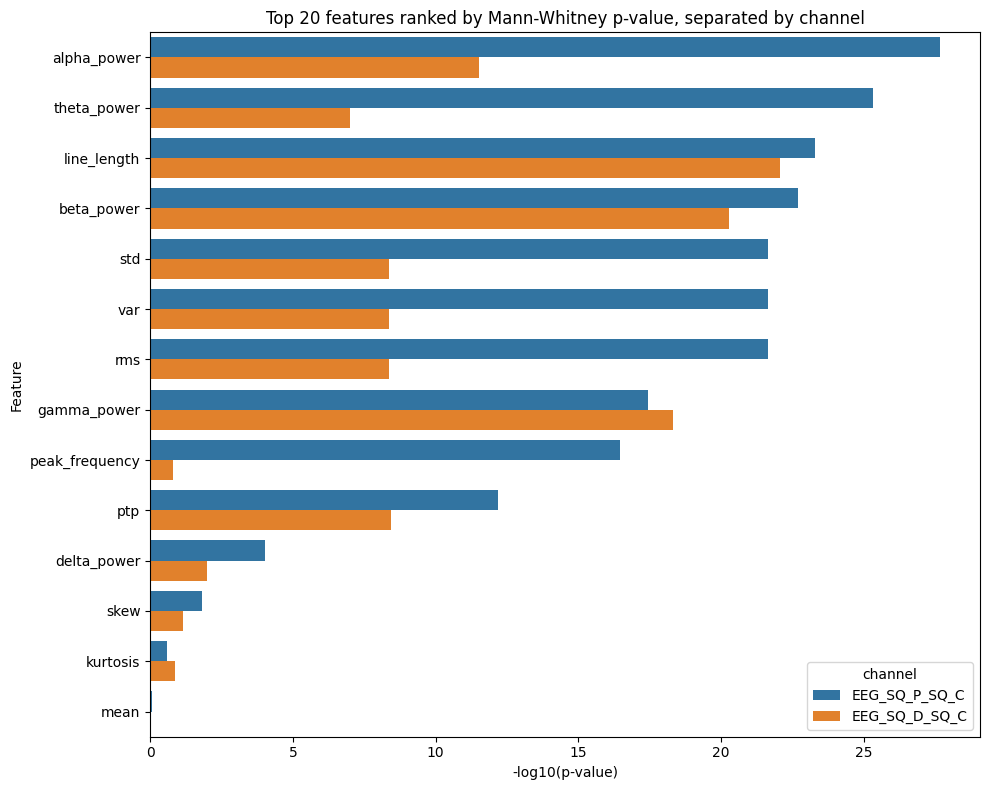

In [18]:
# -------------------------------
# Barplot: top features separated by channel
# -------------------------------

plt.figure(figsize=(10, 8))

sns.barplot(
    data=df_top,
    x="minus_log10_p",
    y="base_feature",
    hue="channel"
)

plt.xlabel("-log10(p-value)")
plt.ylabel("Feature")
plt.title(f"Top {top_n} features ranked by Mann-Whitney p-value, separated by channel")

plt.tight_layout()
plt.show()

### 4.4 effect size evaluation

In [28]:
def compare_effect_size_metrics_for_features(
    feature_cols,
    group_1_PREICTAL,
    group_2_SEIZURE,
    patient_id=None,
    eps=1e-12
):
    """
    Compare several effect-size metrics per feature.

    Positive values mean higher values in ictal windows.
    Negative values mean higher values in preictal windows.
    """

    import numpy as np
    import pandas as pd
    from scipy.stats import mannwhitneyu
    from sklearn.metrics import roc_auc_score

    rows = []

    for feature in feature_cols:

        preictal = pd.to_numeric(
            group_1_PREICTAL[feature],
            errors="coerce"
        ).replace([np.inf, -np.inf], np.nan).dropna().values

        ictal = pd.to_numeric(
            group_2_SEIZURE[feature],
            errors="coerce"
        ).replace([np.inf, -np.inf], np.nan).dropna().values

        n_preictal = len(preictal)
        n_ictal = len(ictal)

        if n_preictal == 0 or n_ictal == 0:
            continue

        # Mann-Whitney U with ictal first
        u_ictal, p_value = mannwhitneyu(
            ictal,
            preictal,
            alternative="two-sided"
        )

        # Rank-biserial effect size
        rank_biserial = (
            (2 * u_ictal) / (n_ictal * n_preictal)
        ) - 1

        # Means and medians
        mean_preictal = np.mean(preictal)
        mean_ictal = np.mean(ictal)

        median_preictal = np.median(preictal)
        median_ictal = np.median(ictal)

        sd_preictal = np.std(preictal, ddof=1)
        sd_ictal = np.std(ictal, ddof=1)

        # Cohen's d
        pooled_sd = np.sqrt(
            ((n_preictal - 1) * sd_preictal**2 +
             (n_ictal - 1) * sd_ictal**2) /
            (n_preictal + n_ictal - 2)
        )

        if pooled_sd > 0:
            cohens_d = (mean_ictal - mean_preictal) / pooled_sd
        else:
            cohens_d = np.nan

        # Hedges' g correction
        correction = 1 - (3 / (4 * (n_preictal + n_ictal) - 9))
        hedges_g = cohens_d * correction if not np.isnan(cohens_d) else np.nan

        # Robust median difference normalised by MAD
        mad_preictal = np.median(np.abs(preictal - median_preictal))
        mad_ictal = np.median(np.abs(ictal - median_ictal))

        pooled_mad = np.sqrt((mad_preictal**2 + mad_ictal**2) / 2)

        if pooled_mad > 0:
            robust_median_diff_mad = (
                median_ictal - median_preictal
            ) / pooled_mad
        else:
            robust_median_diff_mad = np.nan

        # log2 median fold-change
        if median_preictal > 0 and median_ictal > 0:
            log2_median_fc = np.log2(
                (median_ictal + eps) / (median_preictal + eps)
            )
        else:
            log2_median_fc = np.nan

        # Univariate AUROC
        y_true = np.array(
            [0] * n_preictal +
            [1] * n_ictal
        )

        values = np.concatenate([preictal, ictal])

        try:
            auroc = roc_auc_score(y_true, values)
        except ValueError:
            auroc = np.nan

        # Directional AUROC effect:
        # positive = ictal higher, negative = preictal higher
        if not np.isnan(auroc):
            auroc_effect = (auroc - 0.5) * 2
        else:
            auroc_effect = np.nan

        rows.append({
            "patient_id": patient_id,
            "feature": feature,
            "n_preictal": n_preictal,
            "n_ictal": n_ictal,
            "p_value": p_value,
            "neg_log10_p": -np.log10(max(p_value, np.nextafter(0, 1))),
            "rank_biserial": rank_biserial,
            "hedges_g": hedges_g,
            "robust_median_diff_mad": robust_median_diff_mad,
            "log2_median_fold_change": log2_median_fc,
            "univariate_auroc": auroc,
            "auroc_effect": auroc_effect,
            "median_preictal": median_preictal,
            "median_ictal": median_ictal,
            "mean_preictal": mean_preictal,
            "mean_ictal": mean_ictal
        })

    return pd.DataFrame(rows)

In [29]:
df_effect_comparison = compare_effect_size_metrics_for_features(
    feature_cols=feature_cols,
    group_1_PREICTAL=group_1_PREICTAL,
    group_2_SEIZURE=group_2_SEIZURE,
    patient_id= "XB47Y"
)

In [30]:
effect_cols = [
    "rank_biserial",
    "hedges_g",
    "robust_median_diff_mad",
    "log2_median_fold_change"
]

target_col = "auroc_effect"

for col in effect_cols:
    valid = df_effect_comparison[[col, target_col]].dropna()

    corr = valid[col].abs().corr(
        valid[target_col].abs(),
        method="spearman"
    )

    print(col, corr)

rank_biserial 1.0
hedges_g 0.834999511051144
robust_median_diff_mad 0.8449674069455259
log2_median_fold_change 0.6039409123395896


### 4.5 volcano plot testing

Plotting feature: mean_EEG_SQ_D_SQ_C


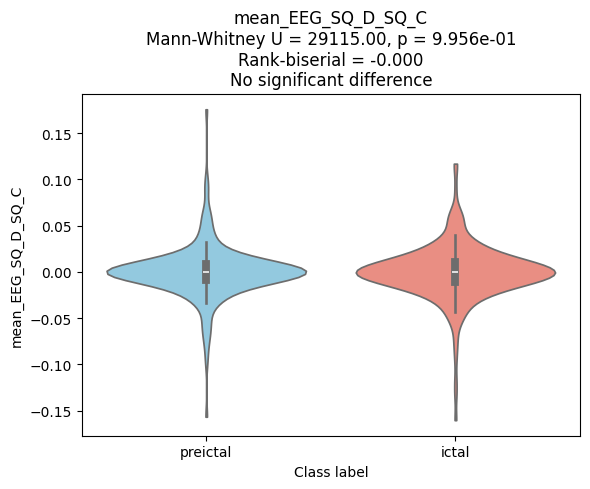

Plotting feature: std_EEG_SQ_D_SQ_C


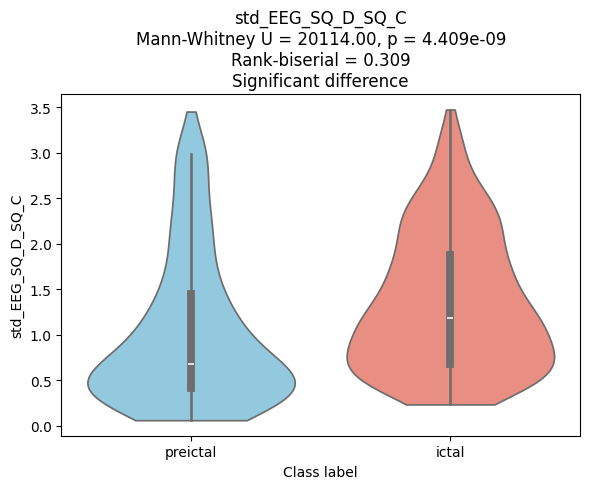

Plotting feature: var_EEG_SQ_D_SQ_C


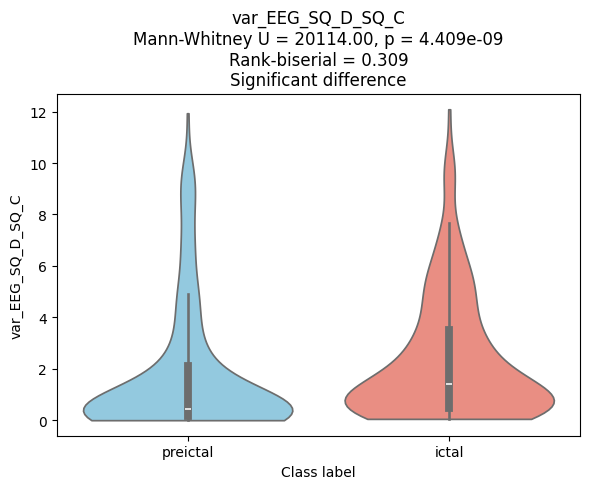

Plotting feature: rms_EEG_SQ_D_SQ_C


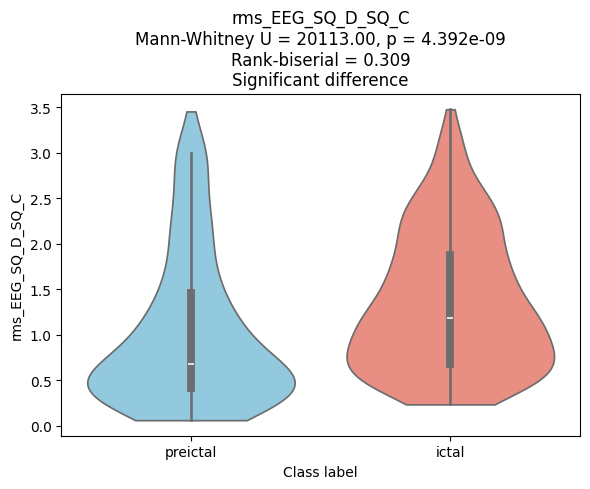

Plotting feature: ptp_EEG_SQ_D_SQ_C


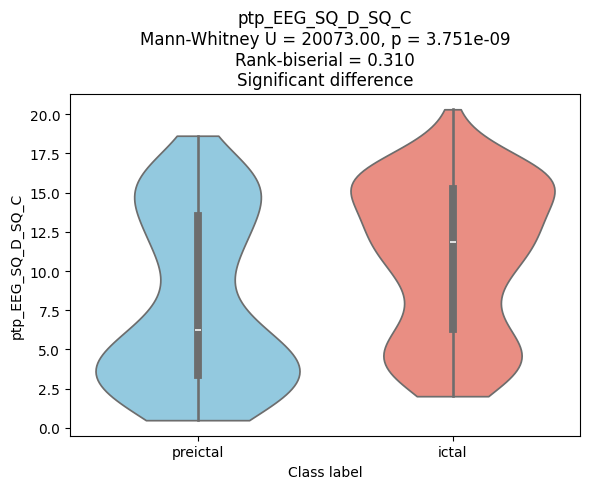

Plotting feature: line_length_EEG_SQ_D_SQ_C


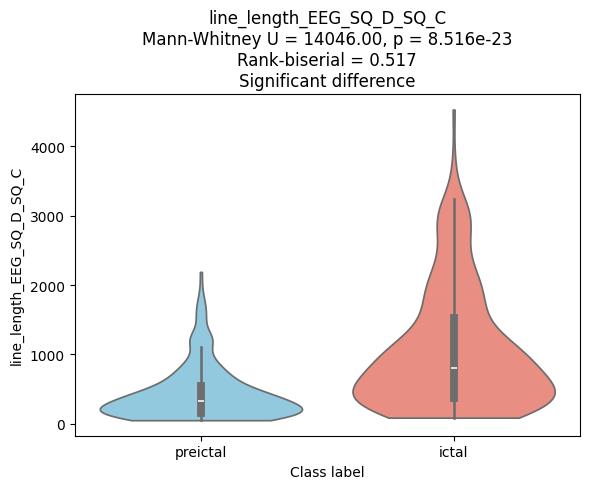

Plotting feature: skew_EEG_SQ_D_SQ_C


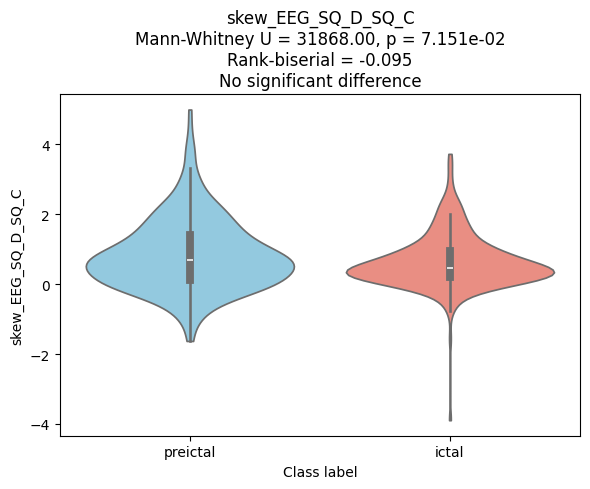

Plotting feature: kurtosis_EEG_SQ_D_SQ_C


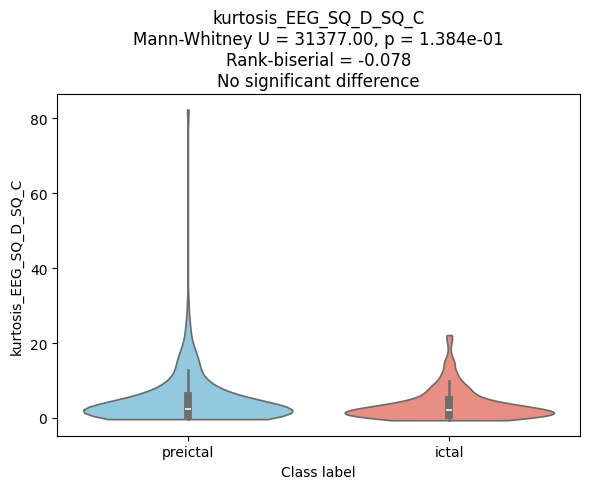

Plotting feature: mean_EEG_SQ_P_SQ_C


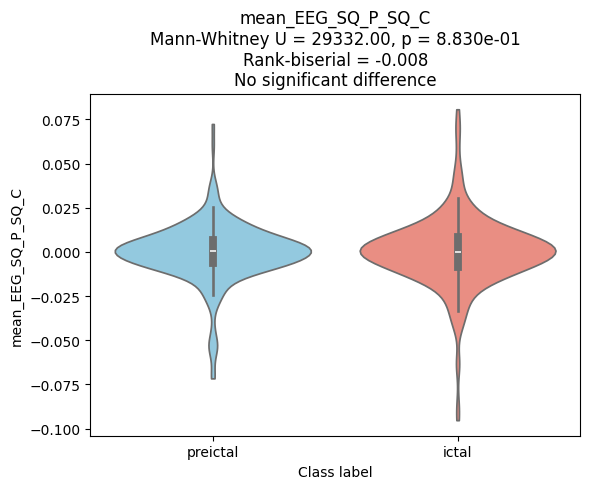

Plotting feature: std_EEG_SQ_P_SQ_C


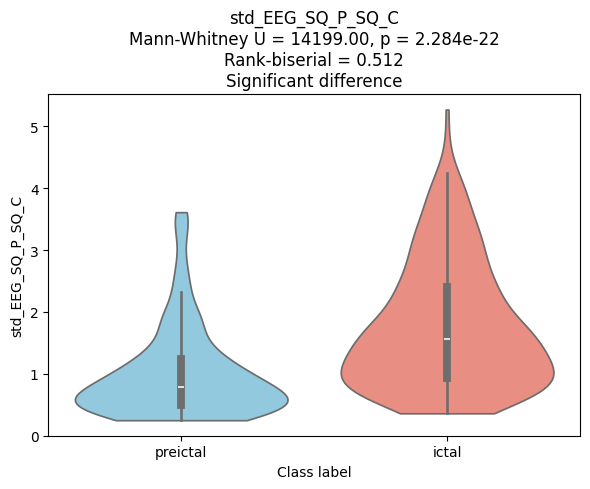

Plotting feature: var_EEG_SQ_P_SQ_C


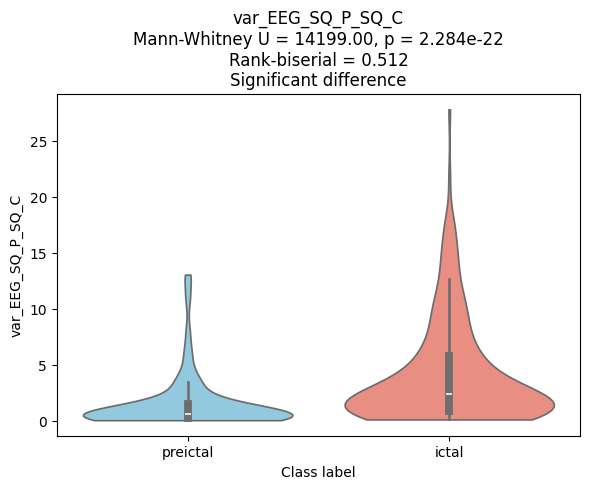

Plotting feature: rms_EEG_SQ_P_SQ_C


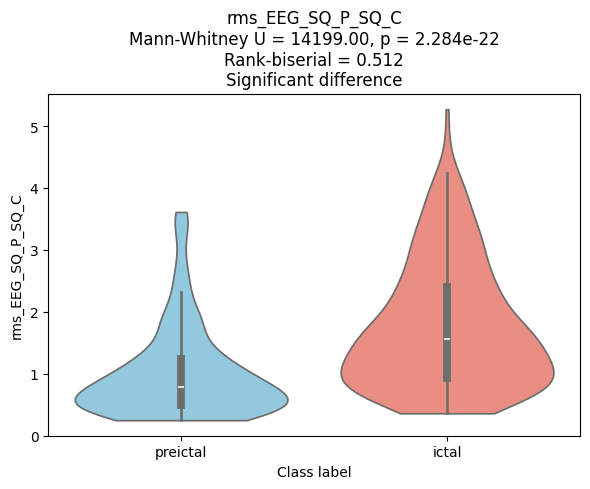

Plotting feature: ptp_EEG_SQ_P_SQ_C


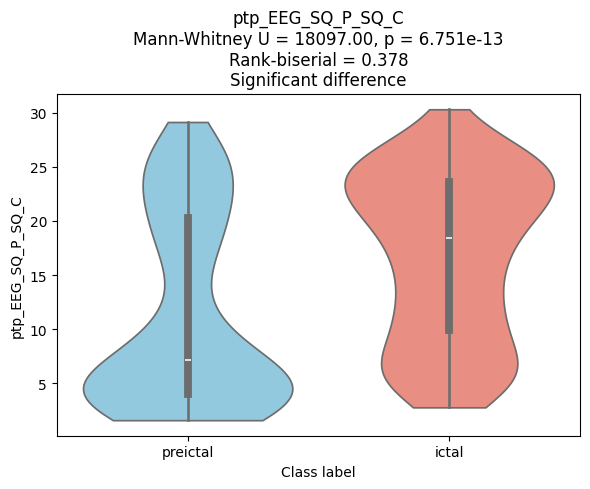

Plotting feature: line_length_EEG_SQ_P_SQ_C


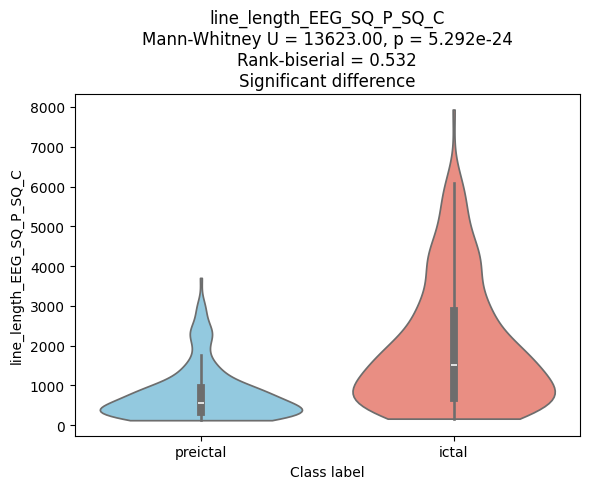

Plotting feature: skew_EEG_SQ_P_SQ_C


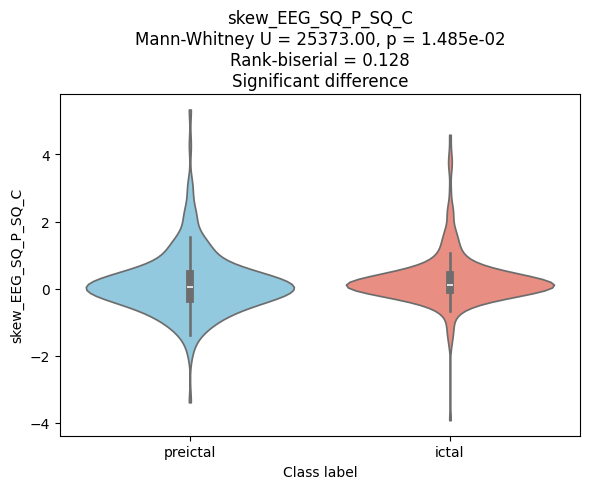

Plotting feature: kurtosis_EEG_SQ_P_SQ_C


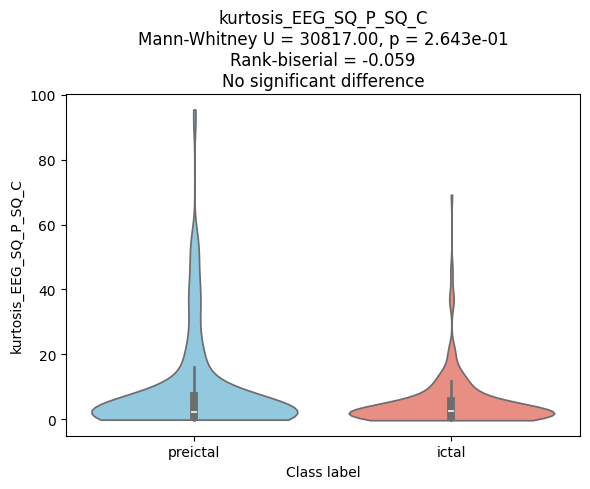

Plotting feature: delta_power_EEG_SQ_D_SQ_C


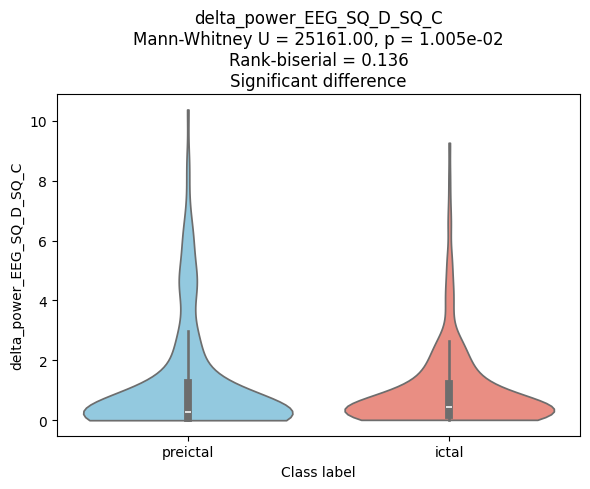

Plotting feature: theta_power_EEG_SQ_D_SQ_C


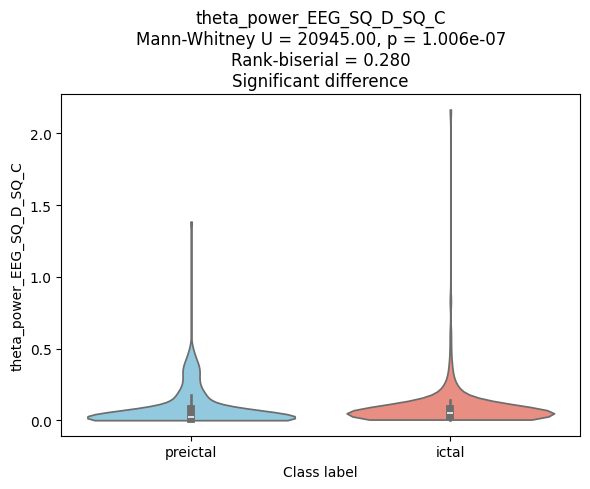

Plotting feature: alpha_power_EEG_SQ_D_SQ_C


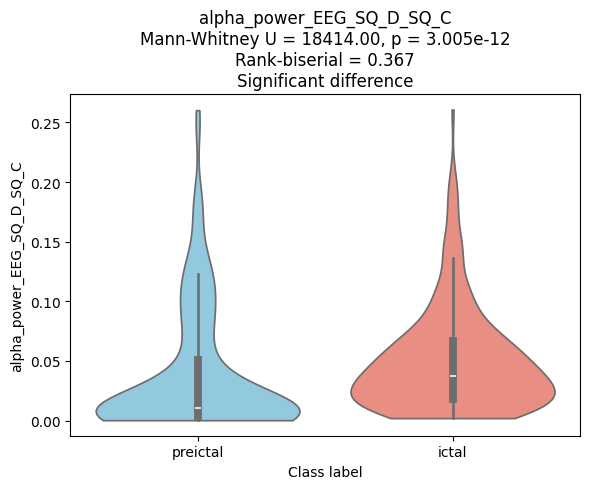

Plotting feature: beta_power_EEG_SQ_D_SQ_C


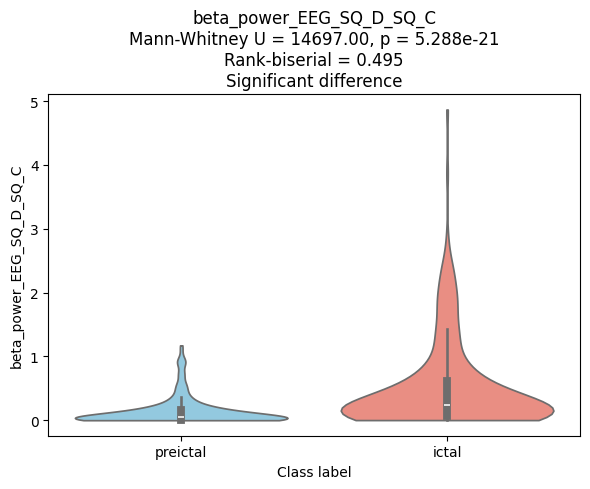

Plotting feature: gamma_power_EEG_SQ_D_SQ_C


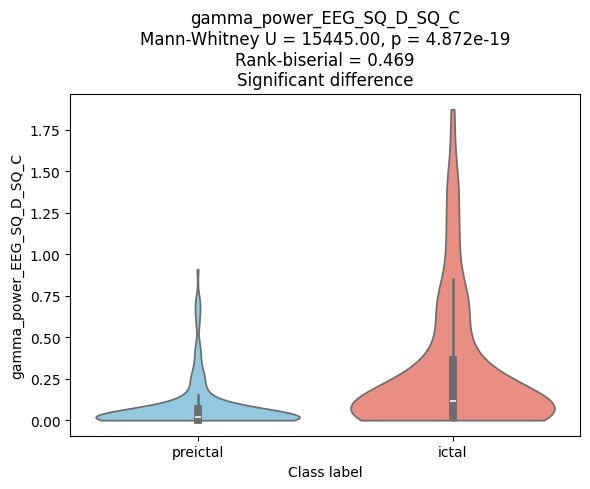

Plotting feature: peak_frequency_EEG_SQ_D_SQ_C


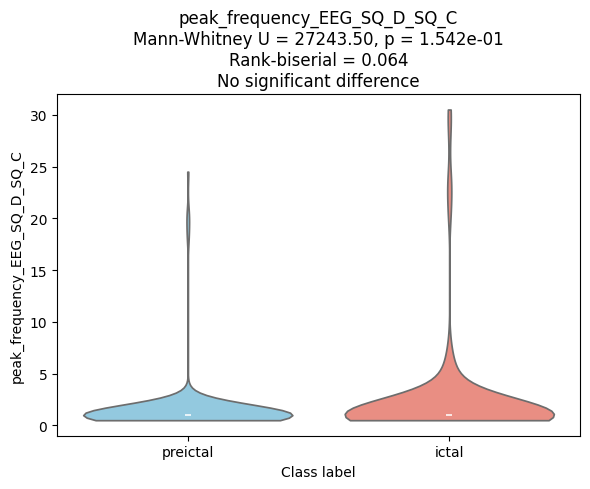

Plotting feature: delta_power_EEG_SQ_P_SQ_C


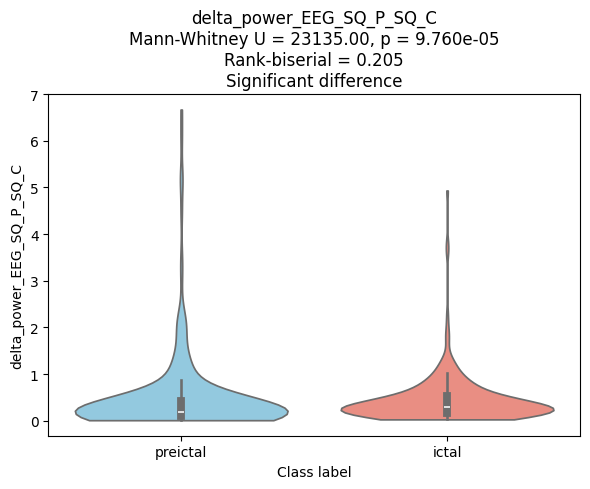

Plotting feature: theta_power_EEG_SQ_P_SQ_C


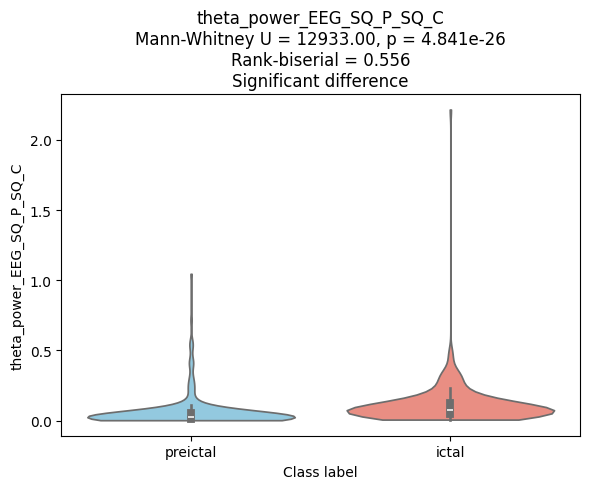

Plotting feature: alpha_power_EEG_SQ_P_SQ_C


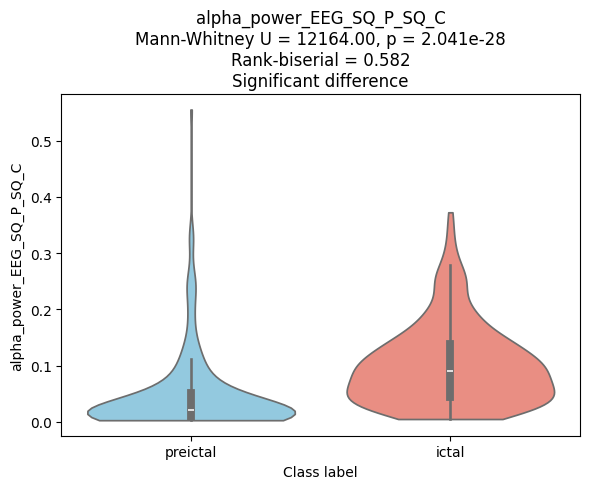

Plotting feature: beta_power_EEG_SQ_P_SQ_C


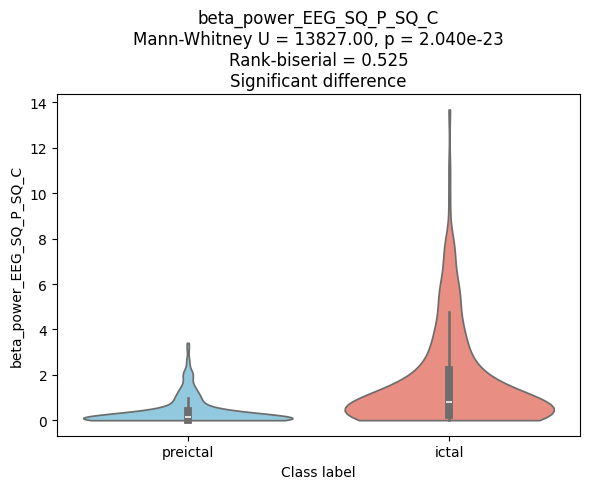

Plotting feature: gamma_power_EEG_SQ_P_SQ_C


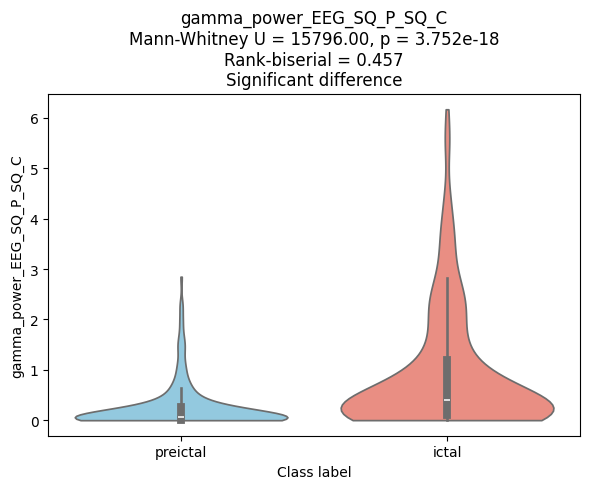

Plotting feature: peak_frequency_EEG_SQ_P_SQ_C


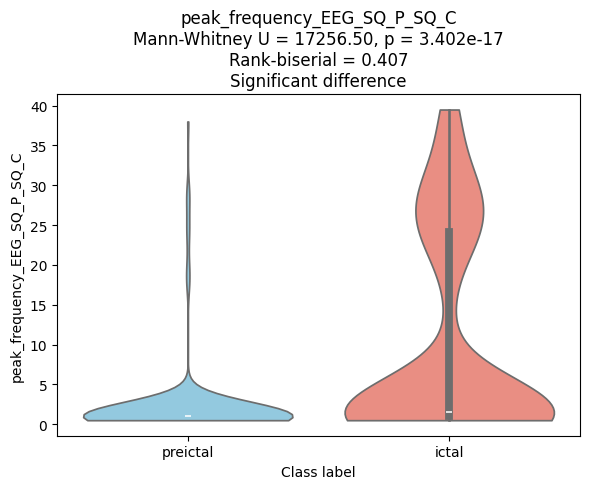

,feature,n_preictal,n_ictal,mannwhitney_U_preictal,mannwhitney_U_ictal,p_value,neg_log10_p,effect_size_rank_biserial,abs_effect_size_rank_biserial,median_preictal,median_ictal,mean_preictal,mean_ictal,median_difference_ictal_minus_preictal,mean_difference_ictal_minus_preictal,result
0,alpha_power_EEG_SQ_P_SQ_C,231,252,12164.0,46048.0,2.041385e-28,27.690075,0.582079,0.582079,0.020448,0.089886,0.047197,0.101142,0.069438,0.053945,Significant difference
1,theta_power_EEG_SQ_P_SQ_C,231,252,12933.0,45279.0,4.840631e-26,25.315098,0.555659,0.555659,0.027298,0.077286,0.060969,0.111606,0.049988,0.050637,Significant difference
2,line_length_EEG_SQ_P_SQ_C,231,252,13623.0,44589.0,5.291525e-24,23.276419,0.531952,0.531952,563.538696,1517.075684,783.156250,1961.591187,953.536987,1178.434937,Significant difference
3,beta_power_EEG_SQ_P_SQ_C,231,252,13827.0,44385.0,2.039889e-23,22.690393,0.524943,0.524943,0.126441,0.816837,0.387882,1.638413,0.690396,1.250530,Significant difference
4,line_length_EEG_SQ_D_SQ_C,231,252,14046.0,44166.0,8.516013e-23,22.069764,0.517419,0.517419,330.244904,806.974365,438.252014,1061.924316,476.729462,623.672302,Significant difference
5,var_EEG_SQ_P_SQ_C,231,252,14199.0,44013.0,2.283569e-22,21.641386,0.512162,0.512162,0.609728,2.418694,1.538639,4.159790,1.808966,2.621150,Significant difference
6,std_EEG_SQ_P_SQ_C,231,252,14199.0,44013.0,2.283569e-22,21.641386,0.512162,0.512162,0.780851,1.555215,1.002449,1.770051,0.774364,0.767602,Significant difference
7,rms_EEG_SQ_P_SQ_C,231,252,14199.0,44013.0,2.283569e-22,21.641386,0.512162,0.512162,0.781052,1.555303,1.002565,1.770157,0.774250,0.767592,Significant difference
8,beta_power_EEG_SQ_D_SQ_C,231,252,14697.0,43515.0,5.287630e-21,20.276739,0.495053,0.495053,0.051572,0.235066,0.137670,0.515785,0.183494,0.378115,Significant difference
9,gamma_power_EEG_SQ_D_SQ_C,231,252,15445.0,42767.0,4.871904e-19,18.312301,0.469353,0.469353,0.018620,0.113758,0.074960,0.286705,0.095138,0.211745,Significant difference


In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# -------------------------------
# Parameters
# -------------------------------
alpha = 0.05

# Colors for each class
palette = {
    "preictal": "skyblue",
    "ictal": "salmon"
}

# Store Mann-Whitney results
mannwhitney_results_violin = []

# -------------------------------
# Loop through all feature columns
# -------------------------------
for feature in feature_cols:

    print(f"Plotting feature: {feature}")

    # -------------------------------
    # Extract values from both groups
    # -------------------------------
    preictal_values = group_1_PREICTAL[feature]
    ictal_values = group_2_SEIZURE[feature]

    # Convert to numeric and remove NaN / infinite values
    preictal_values = pd.to_numeric(preictal_values, errors="coerce")
    ictal_values = pd.to_numeric(ictal_values, errors="coerce")

    preictal_values = (
        preictal_values
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    ictal_values = (
        ictal_values
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    # -------------------------------
    # Skip feature if one group has no valid values
    # -------------------------------
    if len(preictal_values) == 0 or len(ictal_values) == 0:
        print(f"Skipping {feature}: not enough valid values")
        continue

    # -------------------------------
    # Create long-format dataframe for plotting
    # -------------------------------
    df_plot = pd.DataFrame({
        "value": pd.concat([preictal_values, ictal_values], axis=0),
        "label": (
            ["preictal"] * len(preictal_values) +
            ["ictal"] * len(ictal_values)
        )
    })

    # -------------------------------
    # Mann-Whitney U test
    # -------------------------------
    # stat is U for the first group: preictal
    stat, p_value = mannwhitneyu(
        preictal_values,
        ictal_values,
        alternative="two-sided"
    )

    if p_value < alpha:
        test_result = "Significant difference"
    else:
        test_result = "No significant difference"

    # -------------------------------
    # Rank-biserial effect size
    # -------------------------------
    n_preictal = len(preictal_values)
    n_ictal = len(ictal_values)

    # U for preictal, because preictal was passed first
    u_preictal = stat

    # U for ictal
    u_ictal = (n_preictal * n_ictal) - u_preictal

    # Rank-biserial correlation
    # Positive = feature tends to be higher in ictal
    # Negative = feature tends to be higher in preictal
    effect_size_rank_biserial = (
        (2 * u_ictal) / (n_preictal * n_ictal)
    ) - 1

    abs_effect_size_rank_biserial = abs(effect_size_rank_biserial)

    # -------------------------------
    # Descriptive statistics
    # -------------------------------
    median_preictal = np.median(preictal_values)
    median_ictal = np.median(ictal_values)

    mean_preictal = np.mean(preictal_values)
    mean_ictal = np.mean(ictal_values)

    median_difference_ictal_minus_preictal = (
        median_ictal - median_preictal
    )

    mean_difference_ictal_minus_preictal = (
        mean_ictal - mean_preictal
    )

    # -------------------------------
    # -log10 p-value for volcano plot
    # -------------------------------
    neg_log10_p = -np.log10(
        max(p_value, np.nextafter(0, 1))
    )

    # -------------------------------
    # Save result
    # -------------------------------
    mannwhitney_results_violin.append({
        "feature": feature,
        "n_preictal": n_preictal,
        "n_ictal": n_ictal,
        "mannwhitney_U_preictal": u_preictal,
        "mannwhitney_U_ictal": u_ictal,
        "p_value": p_value,
        "neg_log10_p": neg_log10_p,
        "effect_size_rank_biserial": effect_size_rank_biserial,
        "abs_effect_size_rank_biserial": abs_effect_size_rank_biserial,
        "median_preictal": median_preictal,
        "median_ictal": median_ictal,
        "mean_preictal": mean_preictal,
        "mean_ictal": mean_ictal,
        "median_difference_ictal_minus_preictal": median_difference_ictal_minus_preictal,
        "mean_difference_ictal_minus_preictal": mean_difference_ictal_minus_preictal,
        "result": test_result
    })

    # -------------------------------
    # Violin plot
    # -------------------------------
    plt.figure(figsize=(6, 5))

    sns.violinplot(
        data=df_plot,
        x="label",
        y="value",
        hue="label",
        palette=palette,
        order=["preictal", "ictal"],
        legend=False,
        inner="box",
        cut=0
    )

    plt.title(
        f"{feature}\n"
        f"Mann-Whitney U = {stat:.2f}, p = {p_value:.3e}\n"
        f"Rank-biserial = {effect_size_rank_biserial:.3f}\n"
        f"{test_result}"
    )

    plt.xlabel("Class label")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

# -------------------------------
# Convert statistical results to dataframe
# -------------------------------
df_mannwhitney_results_violin = pd.DataFrame(mannwhitney_results_violin)

# Sort by p-value
if not df_mannwhitney_results_violin.empty:
    df_mannwhitney_results_violin = (
        df_mannwhitney_results_violin
        .sort_values("p_value")
        .reset_index(drop=True)
    )

df_mannwhitney_results_violin

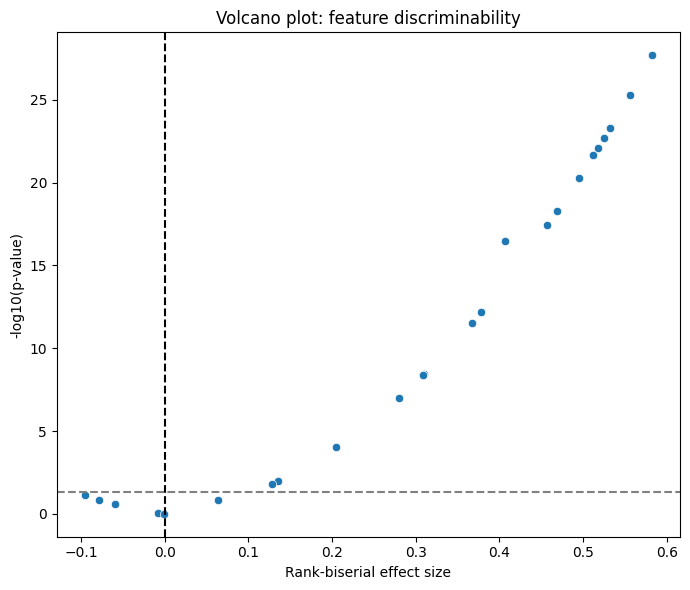

In [32]:
plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=df_mannwhitney_results_violin,
    x="effect_size_rank_biserial",
    y="neg_log10_p"
)

plt.axvline(0, linestyle="--", color="black")
plt.axhline(-np.log10(alpha), linestyle="--", color="grey")

plt.xlabel("Rank-biserial effect size")
plt.ylabel("-log10(p-value)")
plt.title("Volcano plot: feature discriminability")

plt.tight_layout()
plt.show()

In [ ]:
threshold de effect size: rank-biserial correlation
#+1  → ictal siempre tiene valores mayores que preictal
# 0  → no hay separación clara entre ictal y preictal
#-1  → preictal siempre tiene valores mayores que ictal
Para este paciente, las features más discriminativas parecen estar aumentadas 
en ventanas ictales, no en preictales. Hay varias features con evidencia estadística fuerte y efecto moderado/grande,
mientras que las features cercanas a cero aportan poca separación práctica.

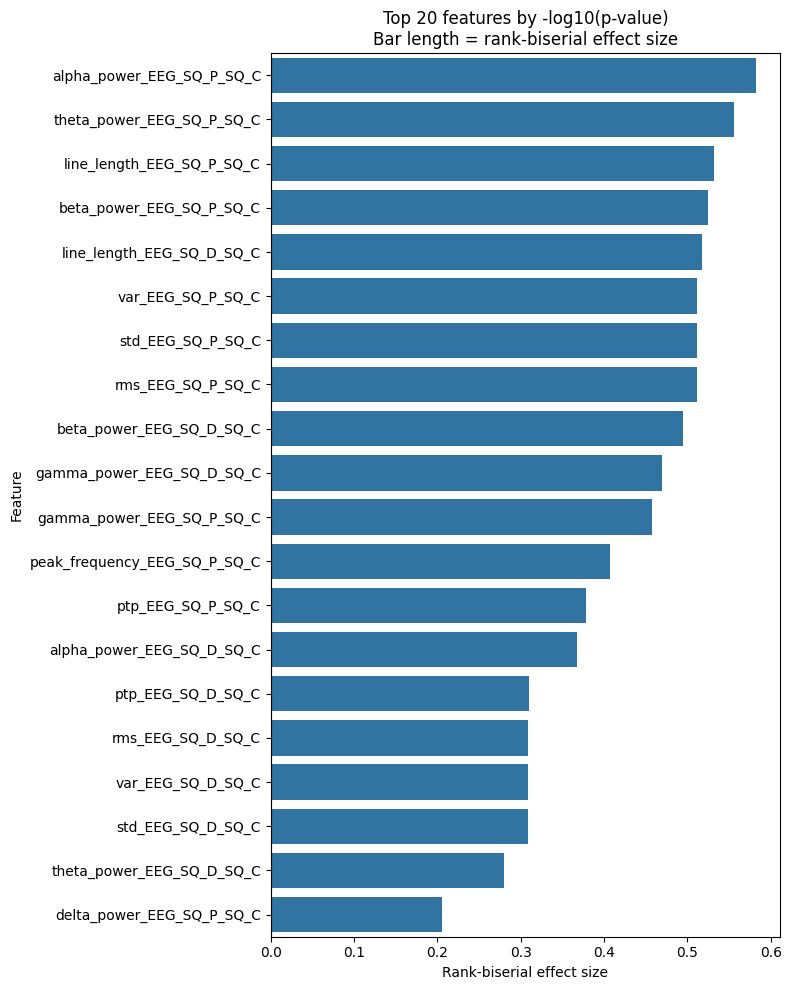

In [33]:
# -------------------------------
# Barplot: features vs effect size
# Ordered by -log10(p-value)
# -------------------------------

# Optional: choose top N most significant features
top_n = 20

df_bar = (
    df_mannwhitney_results_violin
    .sort_values("neg_log10_p", ascending=False)
    .head(top_n)
    .copy()
)

# Create feature order based on -log10(p)
feature_order = df_bar["feature"].tolist()

plt.figure(figsize=(8, 0.4 * len(df_bar) + 2))

sns.barplot(
    data=df_bar,
    y="feature",
    x="effect_size_rank_biserial",
    order=feature_order
)

plt.axvline(0, linestyle="--", color="black")

plt.xlabel("Rank-biserial effect size")
plt.ylabel("Feature")
plt.title(
    f"Top {top_n} features by -log10(p-value)\n"
    "Bar length = rank-biserial effect size"
)

plt.tight_layout()
plt.show()

# 8888 playing with function from module


In [107]:
[name for name in dir(TEEG_FE) if "violin" in name.lower()]

['plot_mannwhitney_feature_violins_2_8',
 'plot_mannwhitney_feature_violins_2_8_V2',
 'plot_mannwhitney_feature_violins_2_8_V3_log2fold']

Plotting feature: mean_EEG_SQ_D_SQ_C


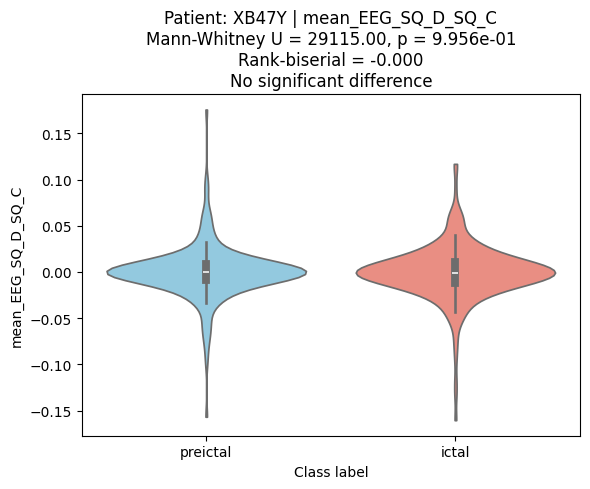

Plotting feature: std_EEG_SQ_D_SQ_C


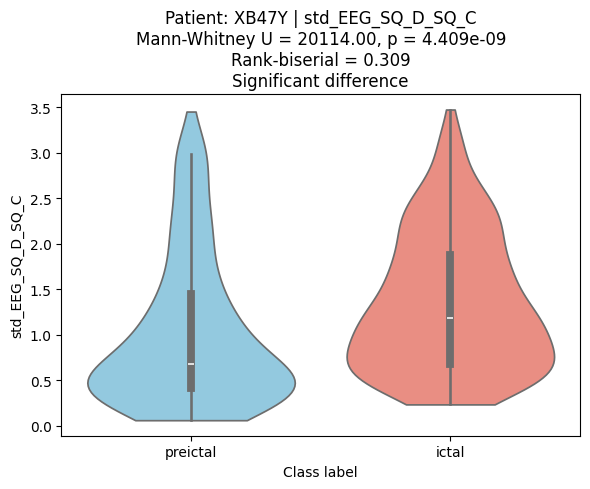

Plotting feature: var_EEG_SQ_D_SQ_C


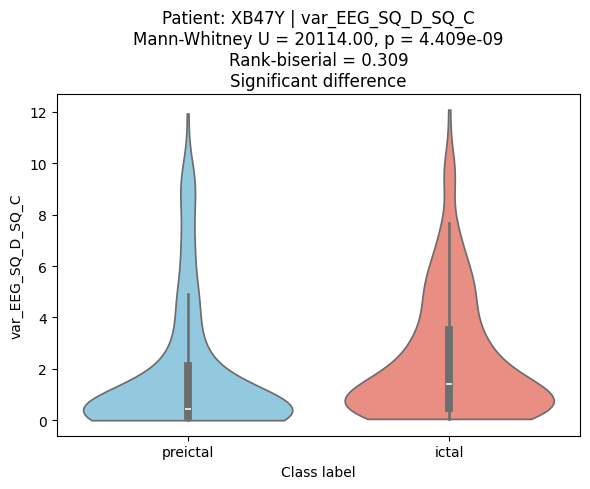

Plotting feature: rms_EEG_SQ_D_SQ_C


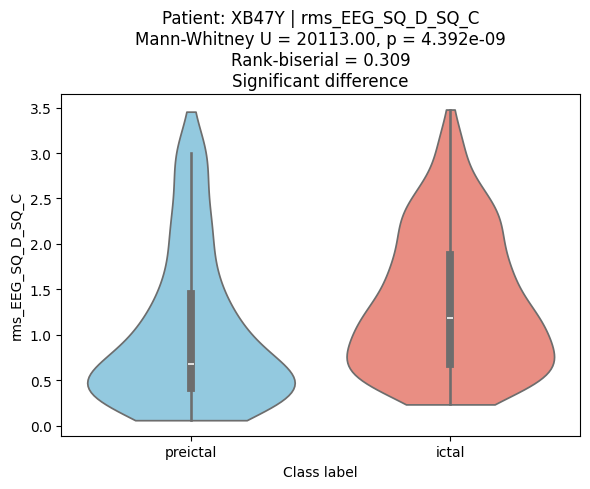

Plotting feature: ptp_EEG_SQ_D_SQ_C


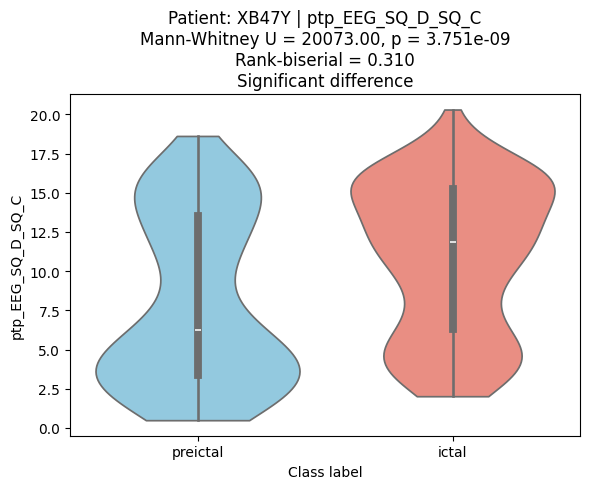

Plotting feature: line_length_EEG_SQ_D_SQ_C


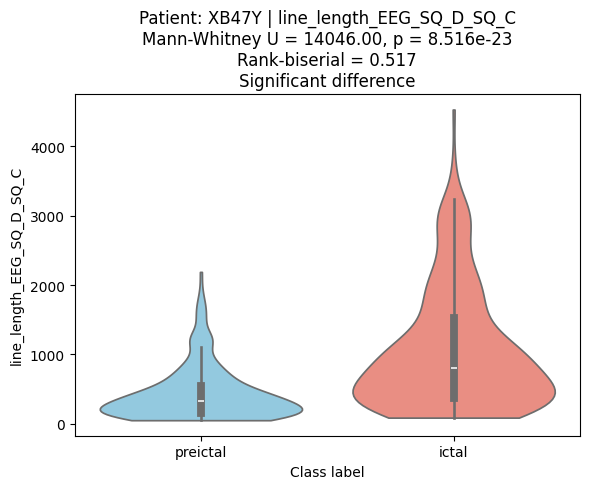

Plotting feature: skew_EEG_SQ_D_SQ_C


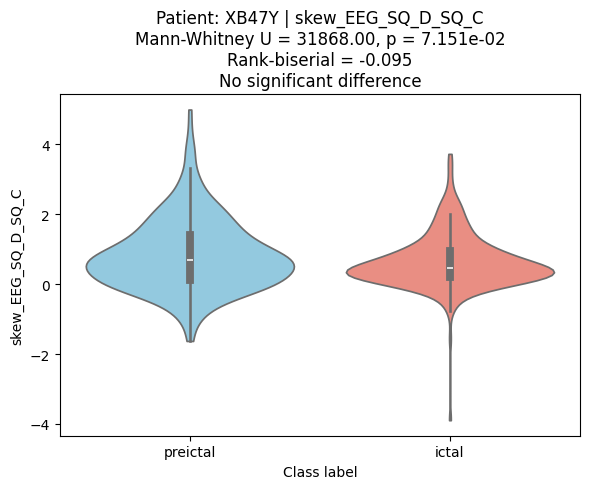

Plotting feature: kurtosis_EEG_SQ_D_SQ_C


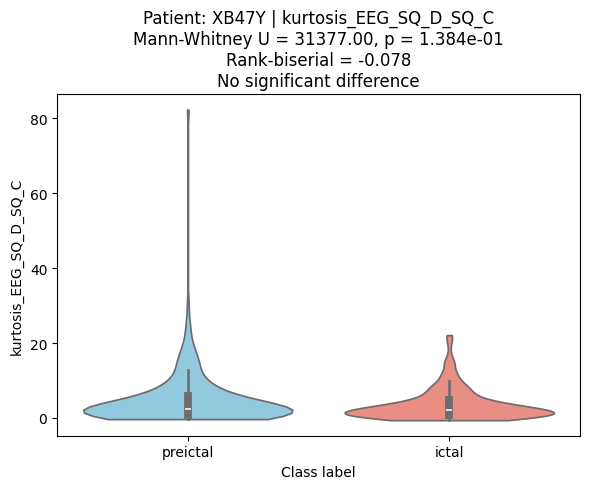

Plotting feature: mean_EEG_SQ_P_SQ_C


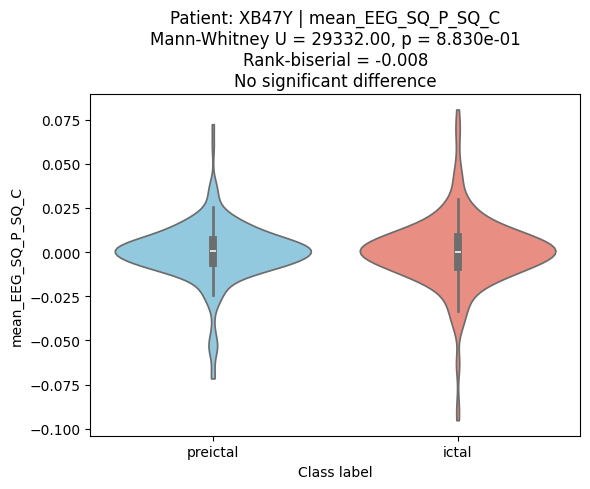

Plotting feature: std_EEG_SQ_P_SQ_C


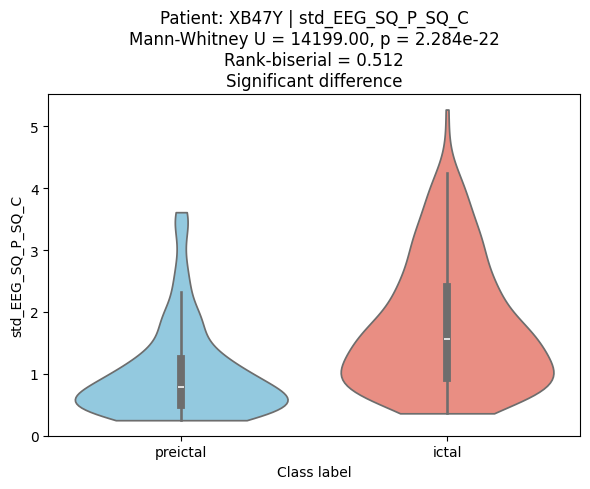

Plotting feature: var_EEG_SQ_P_SQ_C


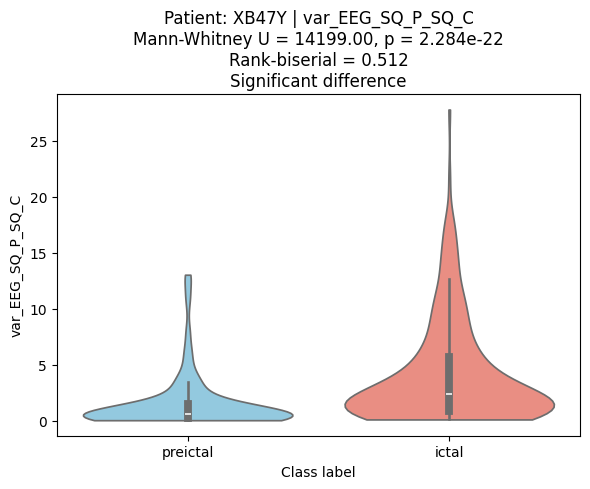

Plotting feature: rms_EEG_SQ_P_SQ_C


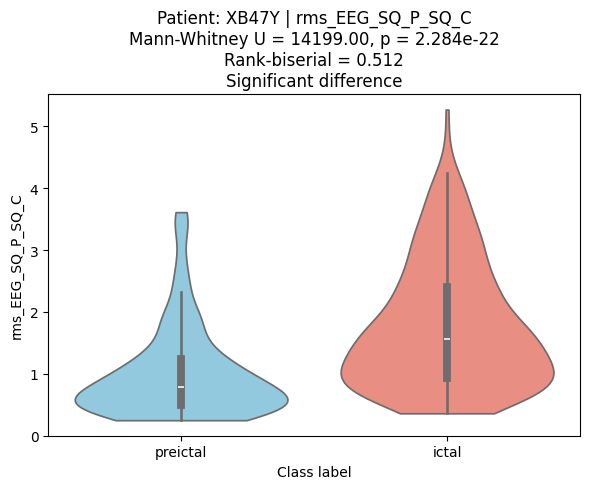

Plotting feature: ptp_EEG_SQ_P_SQ_C


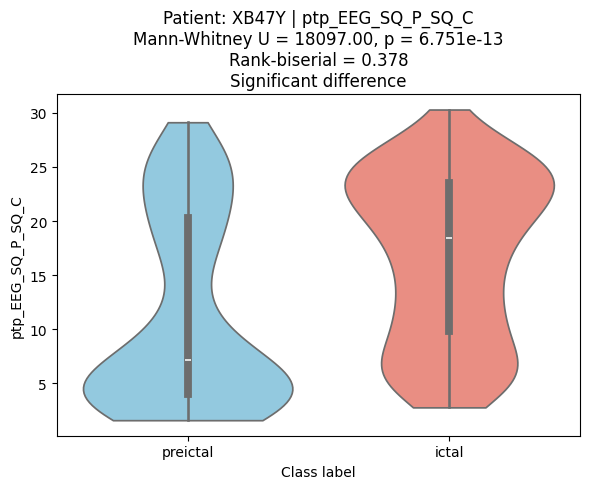

Plotting feature: line_length_EEG_SQ_P_SQ_C


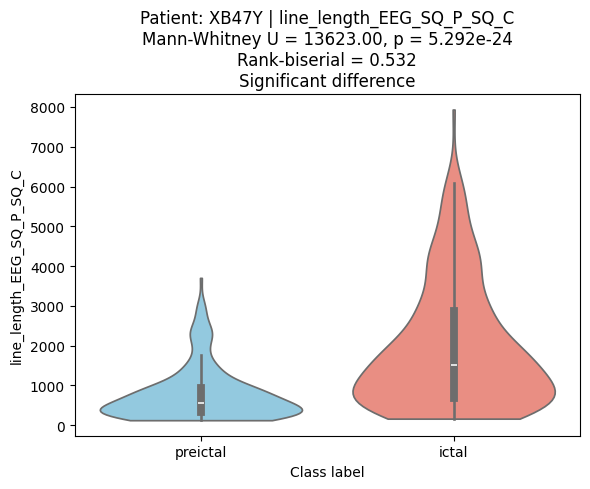

Plotting feature: skew_EEG_SQ_P_SQ_C


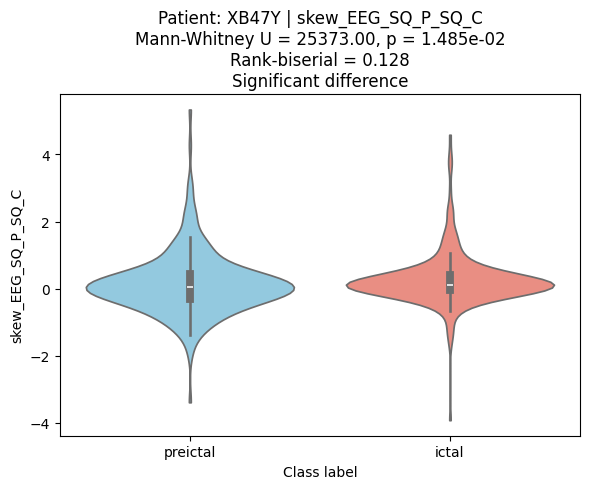

Plotting feature: kurtosis_EEG_SQ_P_SQ_C


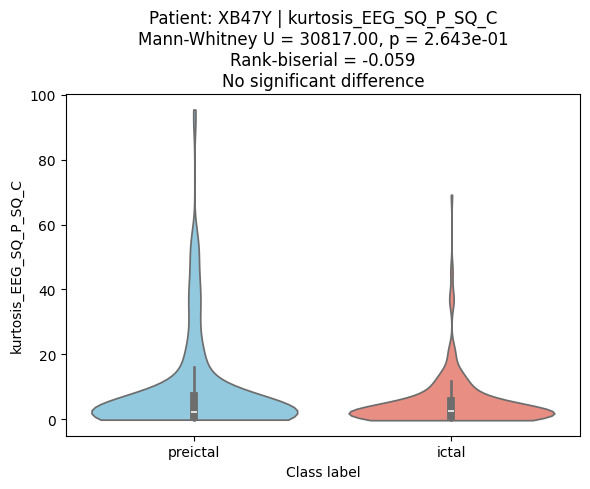

Plotting feature: delta_power_EEG_SQ_D_SQ_C


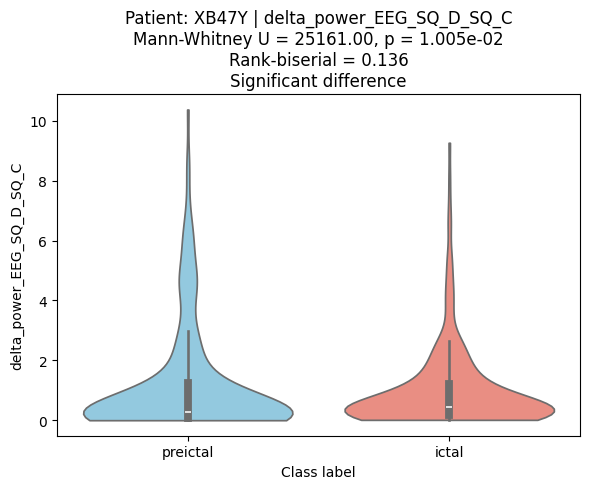

Plotting feature: theta_power_EEG_SQ_D_SQ_C


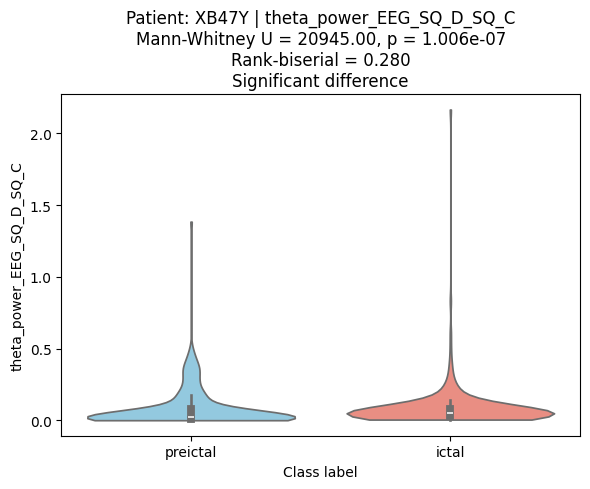

Plotting feature: alpha_power_EEG_SQ_D_SQ_C


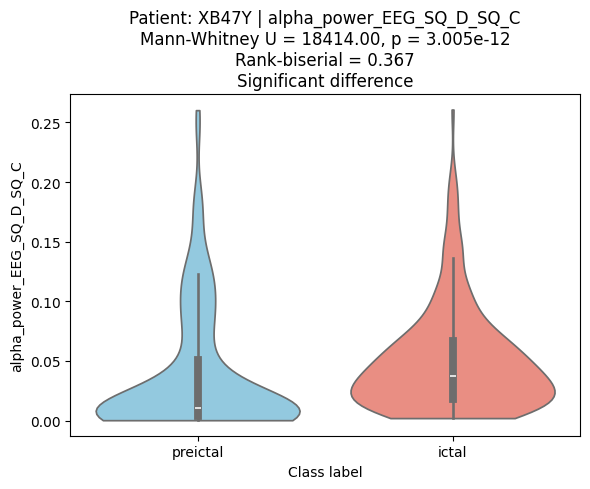

Plotting feature: beta_power_EEG_SQ_D_SQ_C


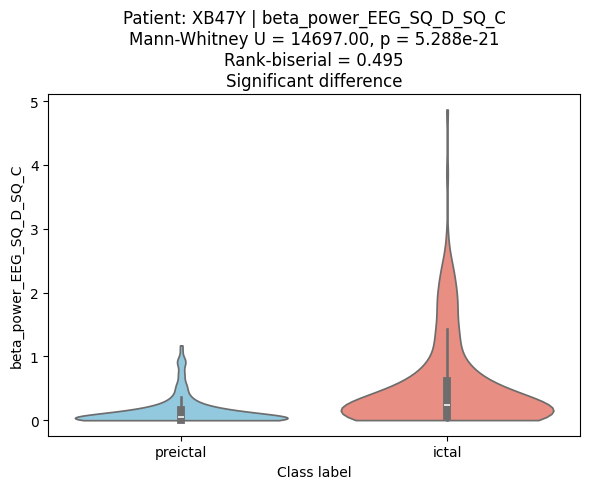

Plotting feature: gamma_power_EEG_SQ_D_SQ_C


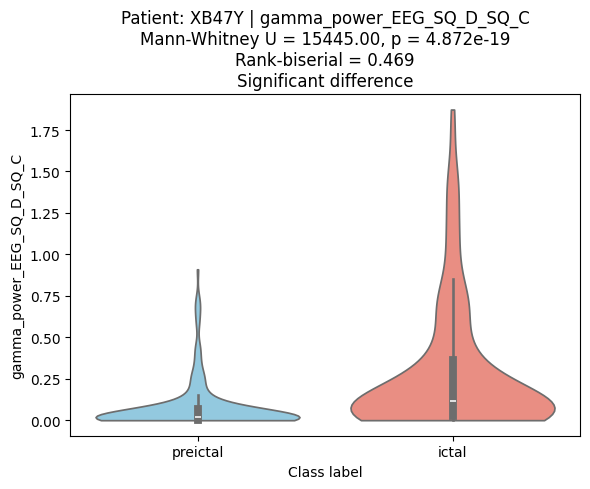

Plotting feature: peak_frequency_EEG_SQ_D_SQ_C


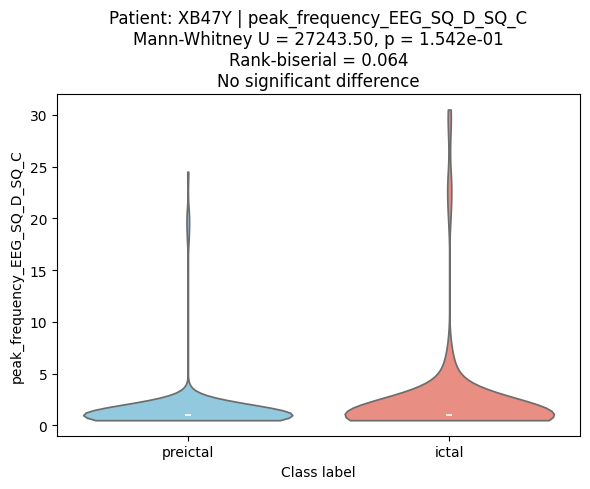

Plotting feature: delta_power_EEG_SQ_P_SQ_C


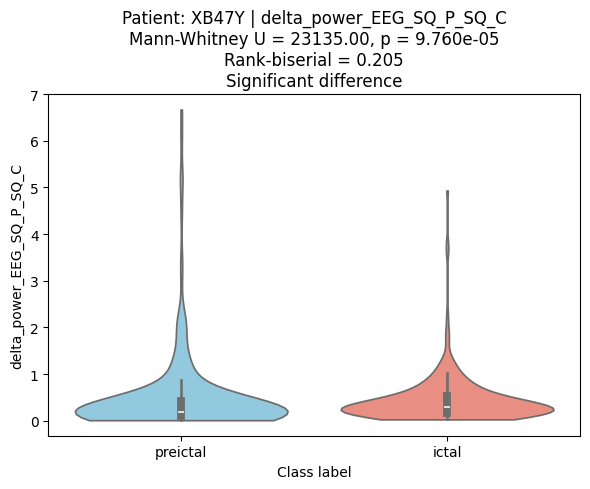

Plotting feature: theta_power_EEG_SQ_P_SQ_C


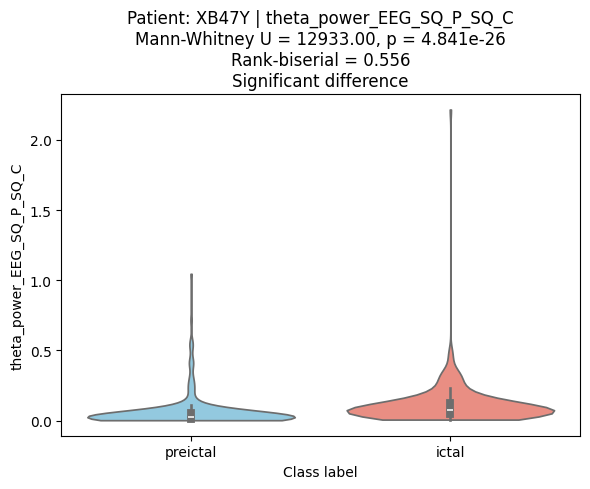

Plotting feature: alpha_power_EEG_SQ_P_SQ_C


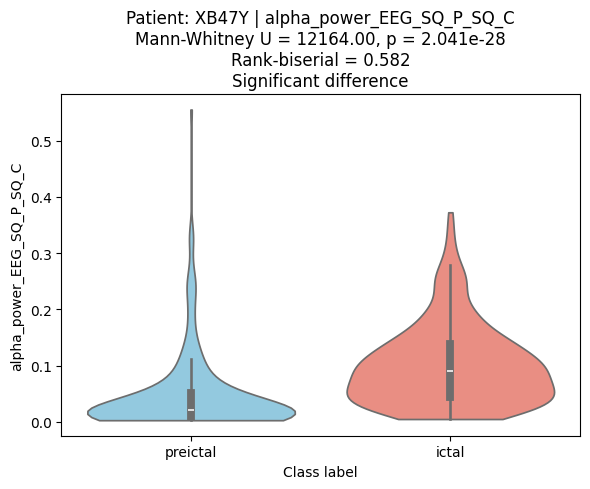

Plotting feature: beta_power_EEG_SQ_P_SQ_C


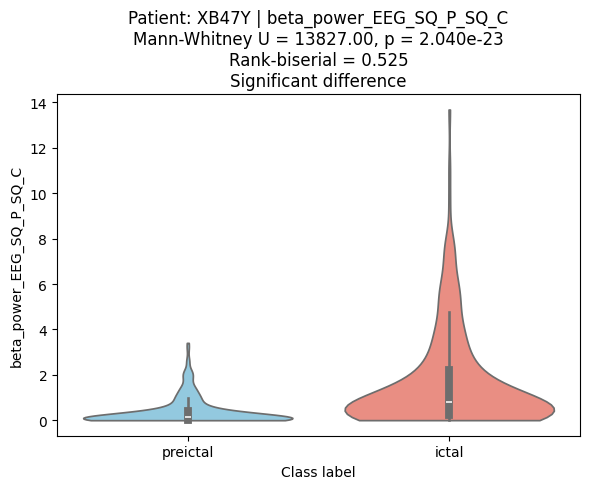

Plotting feature: gamma_power_EEG_SQ_P_SQ_C


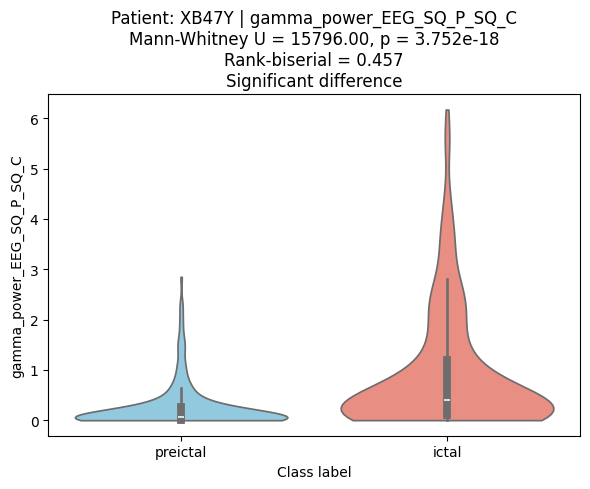

Plotting feature: peak_frequency_EEG_SQ_P_SQ_C


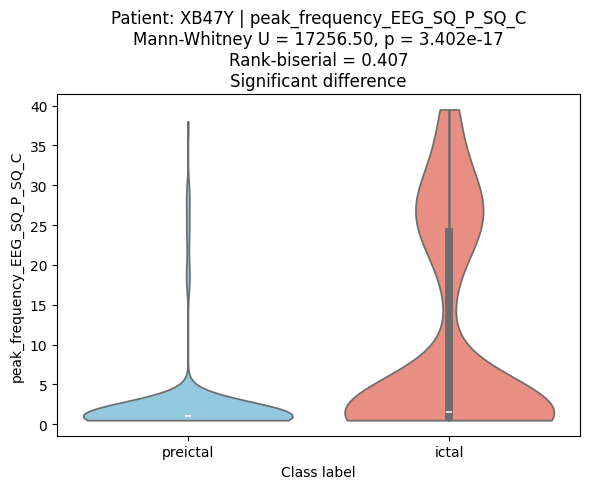

PDF saved to: Tomas_PS_DissertationKCL2026/Main_project/XB47Y_mannwhitney_violin_plots.pdf


In [108]:
violin_pdf_path = "Tomas_PS_DissertationKCL2026/Main_project/XB47Y_mannwhitney_violin_plots.pdf"
df_mannwhitney_results_violin = TEEG_FE.plot_mannwhitney_feature_violins_2_8_V2(
    feature_cols=feature_cols,
    group_1_PREICTAL=group_1_PREICTAL,
    group_2_SEIZURE=group_2_SEIZURE,
    pdf_output_path=violin_pdf_path,
    alpha=alpha,
    show_plots=True,
    patient_id= "XB47Y"
)

In [109]:
df_mannwhitney_results_violin.head()

,patient_id,feature,n_preictal,n_ictal,mannwhitney_U_preictal,mannwhitney_U_ictal,p_value,neg_log10_p,effect_size_rank_biserial,abs_effect_size_rank_biserial,median_preictal,median_ictal,mean_preictal,mean_ictal,median_difference_ictal_minus_preictal,mean_difference_ictal_minus_preictal,feature_subcategory,feature_color,result
0,XB47Y,alpha_power_EEG_SQ_P_SQ_C,231,252,12164.0,46048.0,2.041385e-28,27.690075,0.582079,0.582079,0.020448,0.089886,0.047197,0.101142,0.069438,0.053945,Band-specific spectral power,#D55E00,Significant difference
1,XB47Y,theta_power_EEG_SQ_P_SQ_C,231,252,12933.0,45279.0,4.840631e-26,25.315098,0.555659,0.555659,0.027298,0.077286,0.060969,0.111606,0.049988,0.050637,Band-specific spectral power,#D55E00,Significant difference
2,XB47Y,line_length_EEG_SQ_P_SQ_C,231,252,13623.0,44589.0,5.291525e-24,23.276419,0.531952,0.531952,563.538696,1517.075684,783.156250,1961.591187,953.536987,1178.434937,Temporal waveform change / signal complexity,#009E73,Significant difference
3,XB47Y,beta_power_EEG_SQ_P_SQ_C,231,252,13827.0,44385.0,2.039889e-23,22.690393,0.524943,0.524943,0.126441,0.816837,0.387882,1.638413,0.690396,1.250530,Band-specific spectral power,#D55E00,Significant difference
4,XB47Y,line_length_EEG_SQ_D_SQ_C,231,252,14046.0,44166.0,8.516013e-23,22.069764,0.517419,0.517419,330.244904,806.974365,438.252014,1061.924316,476.729462,623.672302,Temporal waveform change / signal complexity,#009E73,Significant difference


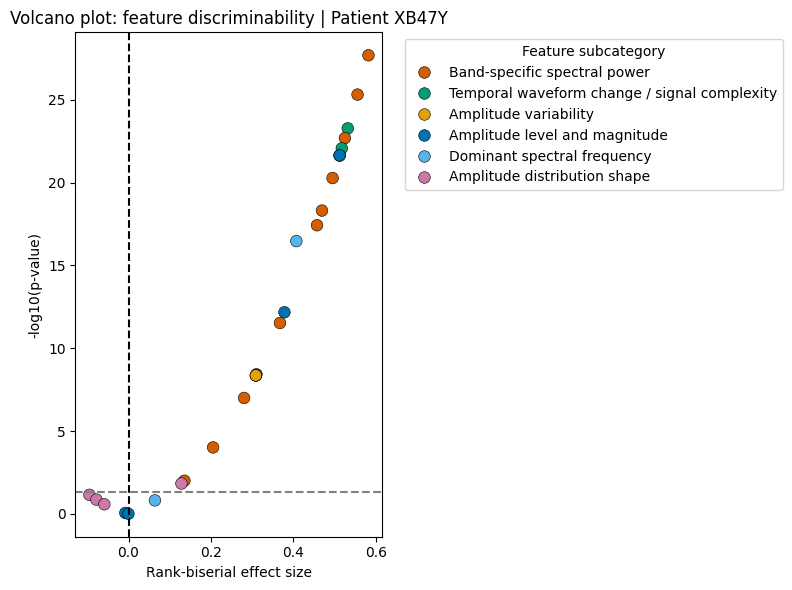

In [110]:
subcategory_palette = TEEG_FE.get_feature_subcategory_palette()

plt.figure(figsize=(8, 6))
patient_id = "XB47Y"
sns.scatterplot(
    data=df_mannwhitney_results_violin,
    x="effect_size_rank_biserial",
    y="neg_log10_p",
    hue="feature_subcategory",
    palette=subcategory_palette,
    s=70,
    edgecolor="black",
    linewidth=0.4
)

plt.axvline(0, linestyle="--", color="black")
plt.axhline(-np.log10(alpha), linestyle="--", color="grey")

plt.xlabel("Rank-biserial effect size")
plt.ylabel("-log10(p-value)")
plt.title(f"Volcano plot: feature discriminability | Patient {patient_id}")

plt.legend(
    title="Feature subcategory",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

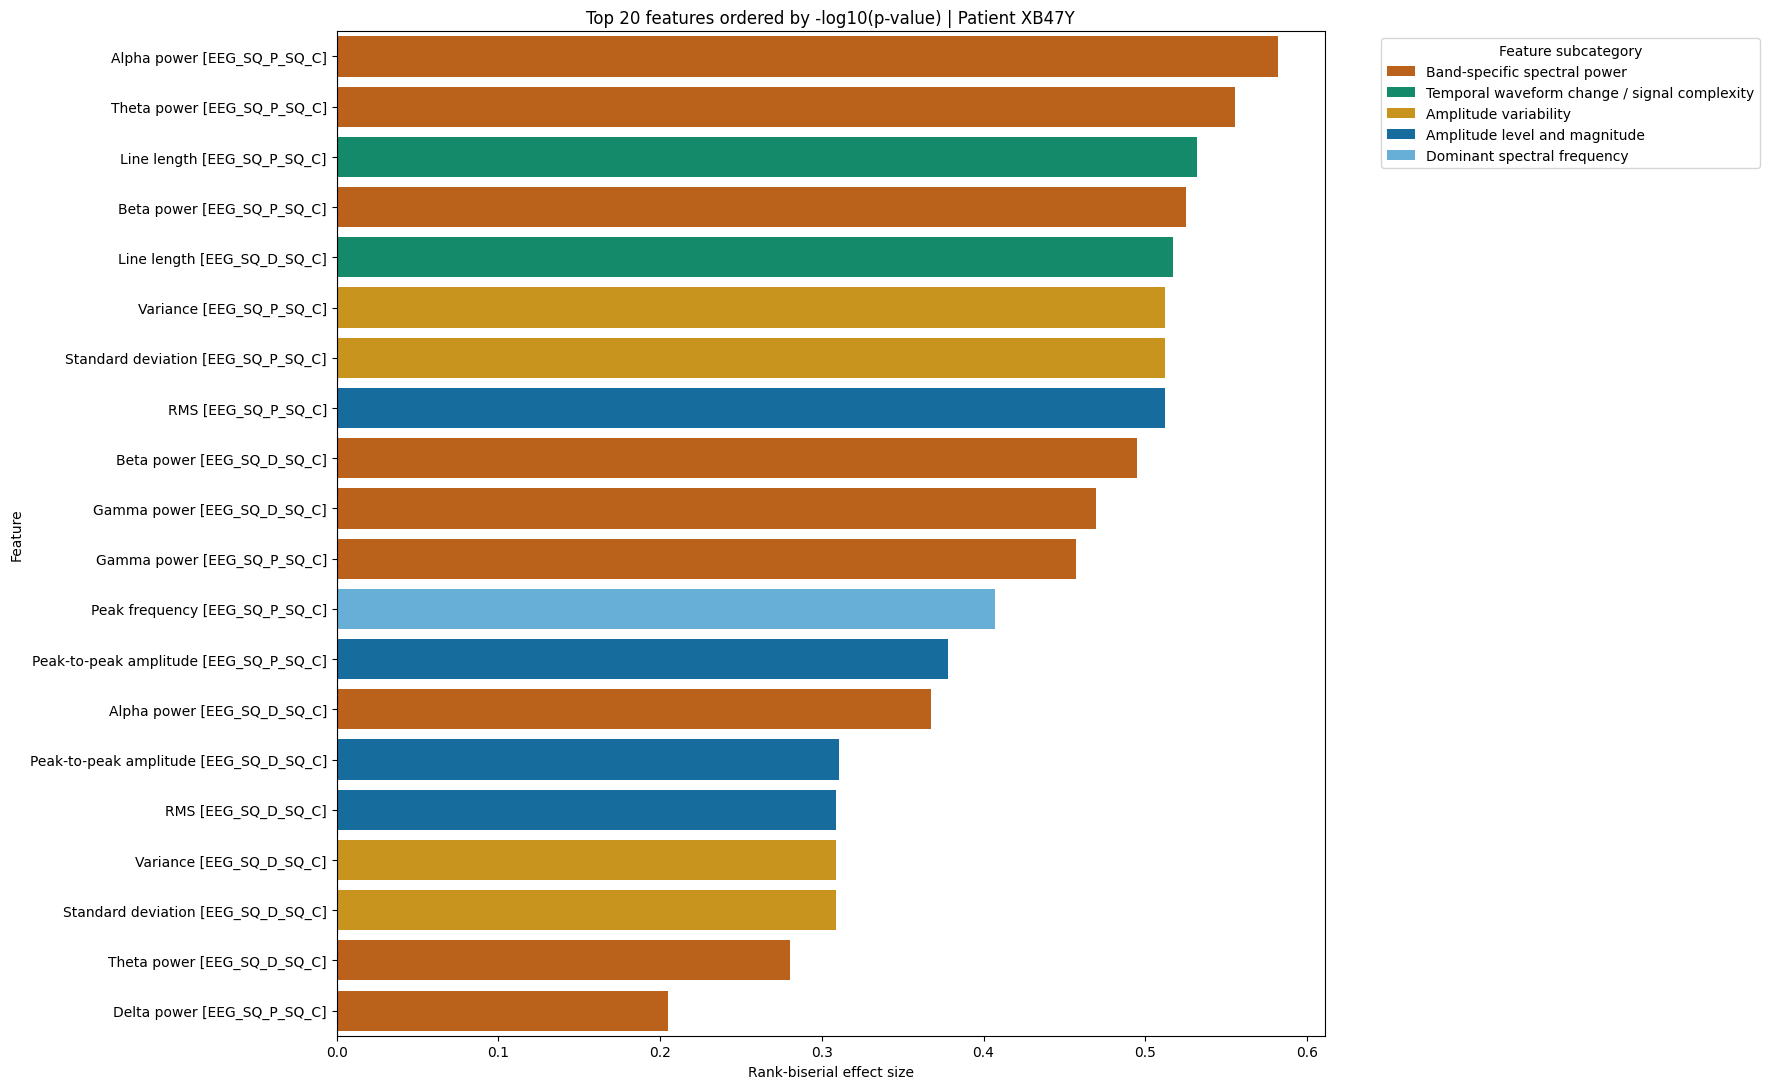

In [111]:
subcategory_palette = TEEG_FE.get_feature_subcategory_palette()

top_n = 20

df_bar = (
    df_mannwhitney_results_violin
    .sort_values("neg_log10_p", ascending=False)
    .head(top_n)
    .copy()
)

df_bar["feature_display"] = (
    df_bar["feature"]
    .apply(TEEG_FE.format_feature_label_for_plot)
)

feature_order = df_bar["feature_display"].tolist()

plt.figure(figsize=(18, 0.45 * len(df_bar) + 2))

sns.barplot(
    data=df_bar,
    y="feature_display",
    x="effect_size_rank_biserial",
    hue="feature_subcategory",
    palette=subcategory_palette,
    order=feature_order,
    dodge=False
)

plt.axvline(0, linestyle="--", color="black")

plt.xlabel("Rank-biserial effect size")
plt.ylabel("Feature")
plt.title(
    f"Top {top_n} features ordered by -log10(p-value) | Patient {patient_id}"
)

plt.legend(
    title="Feature subcategory",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Plotting feature: mean_EEG_SQ_D_SQ_C


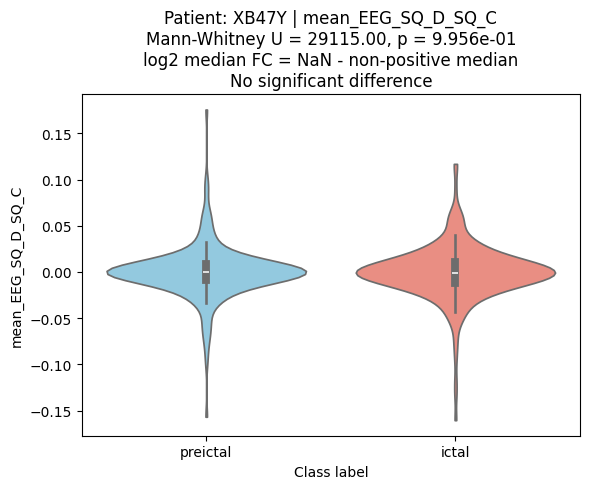

Plotting feature: std_EEG_SQ_D_SQ_C


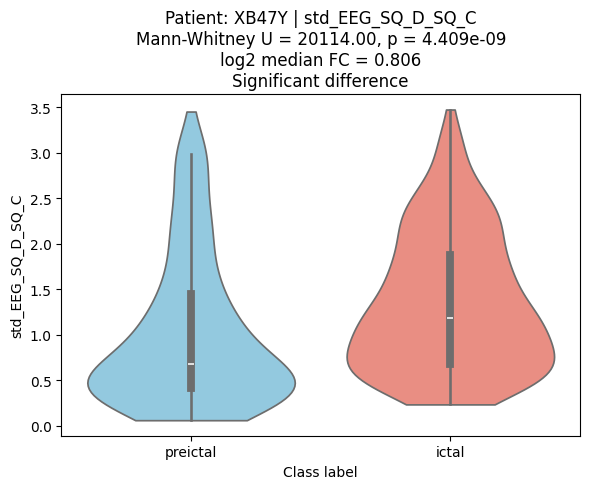

Plotting feature: var_EEG_SQ_D_SQ_C


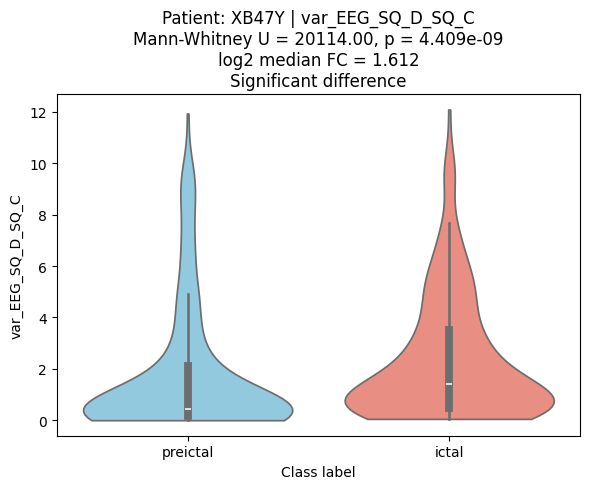

Plotting feature: rms_EEG_SQ_D_SQ_C


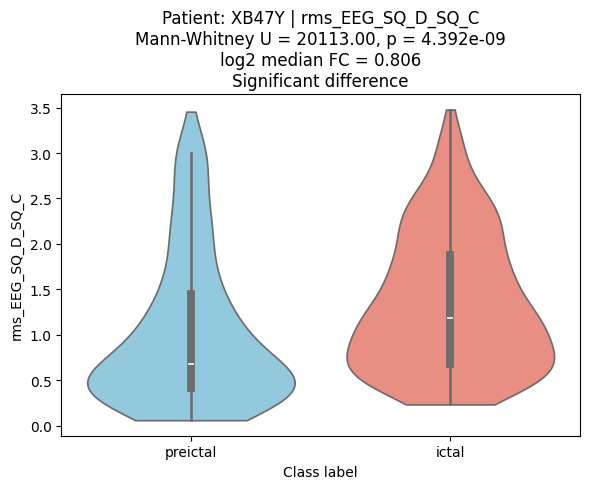

Plotting feature: ptp_EEG_SQ_D_SQ_C


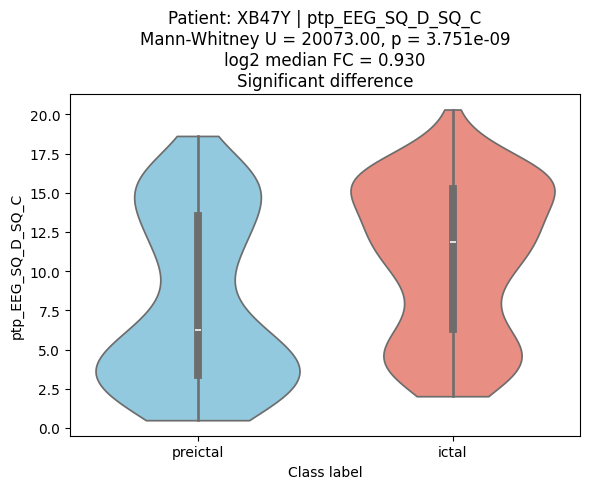

Plotting feature: line_length_EEG_SQ_D_SQ_C


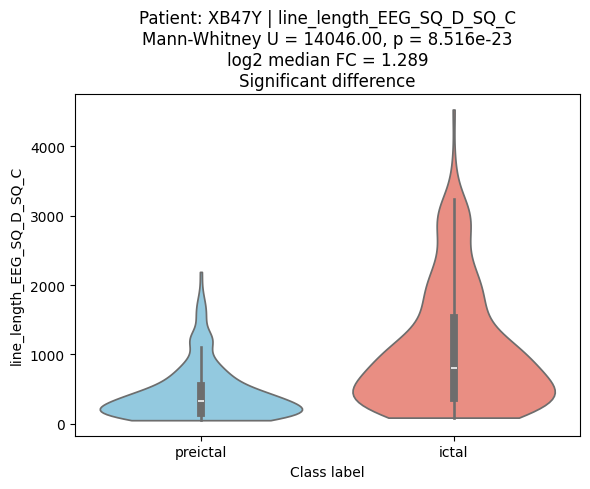

Plotting feature: skew_EEG_SQ_D_SQ_C


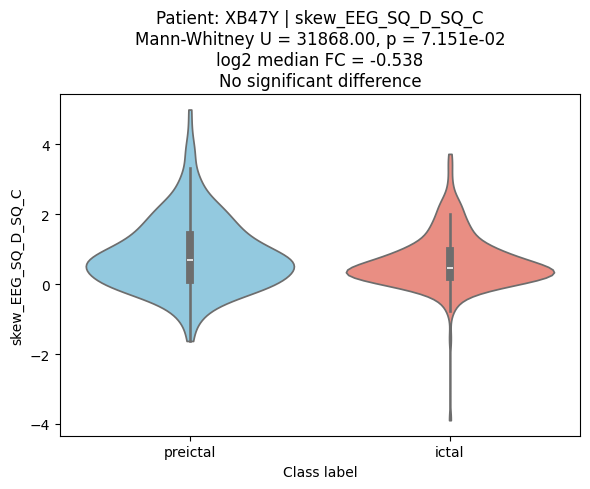

Plotting feature: kurtosis_EEG_SQ_D_SQ_C


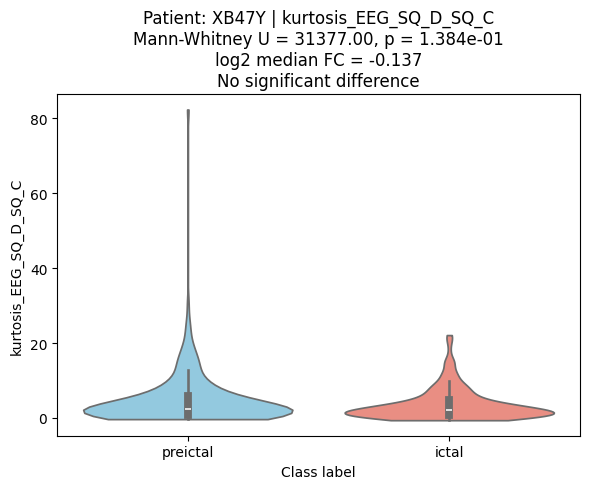

Plotting feature: mean_EEG_SQ_P_SQ_C


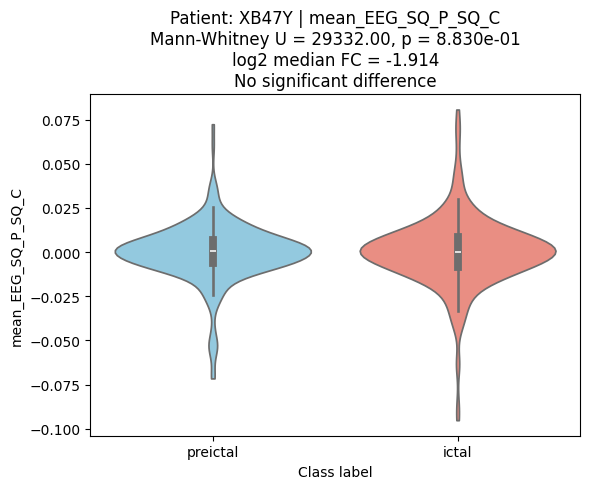

Plotting feature: std_EEG_SQ_P_SQ_C


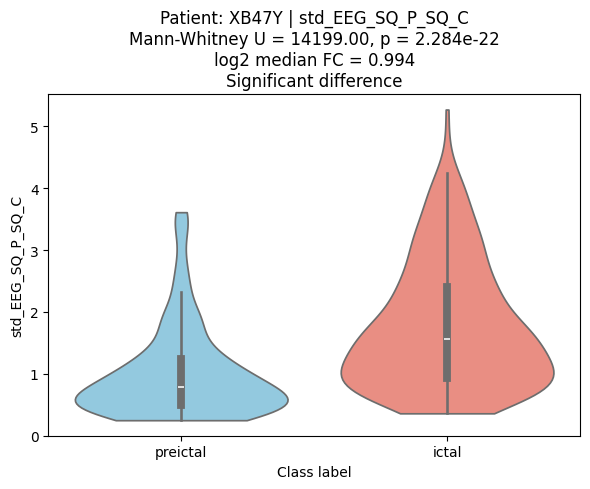

Plotting feature: var_EEG_SQ_P_SQ_C


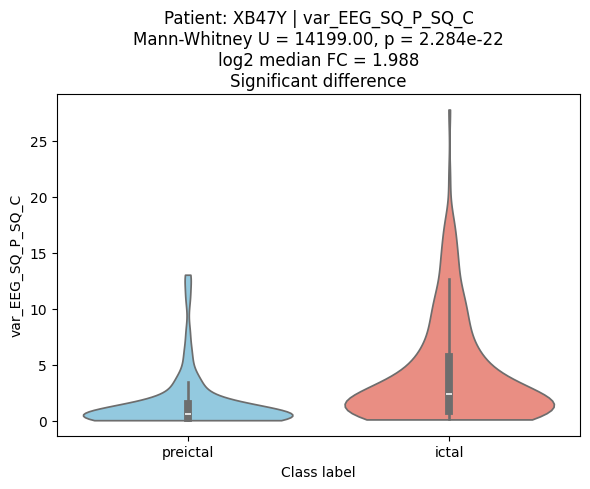

Plotting feature: rms_EEG_SQ_P_SQ_C


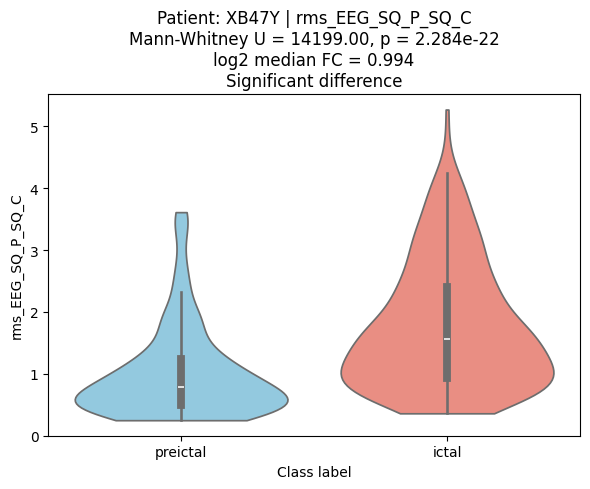

Plotting feature: ptp_EEG_SQ_P_SQ_C


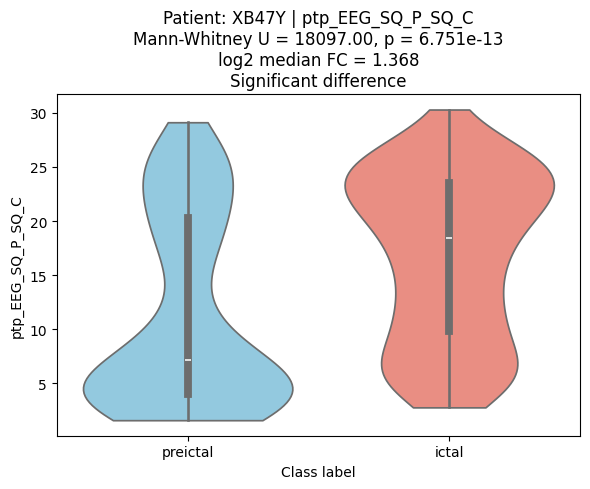

Plotting feature: line_length_EEG_SQ_P_SQ_C


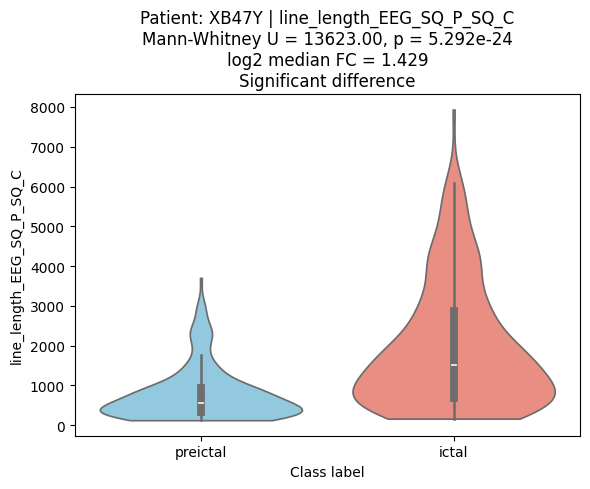

Plotting feature: skew_EEG_SQ_P_SQ_C


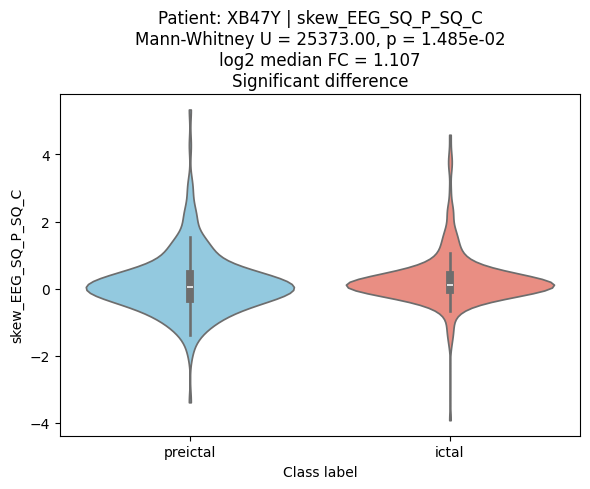

Plotting feature: kurtosis_EEG_SQ_P_SQ_C


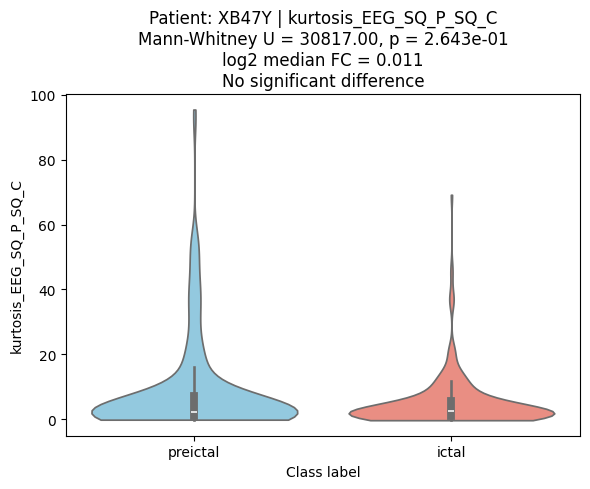

Plotting feature: delta_power_EEG_SQ_D_SQ_C


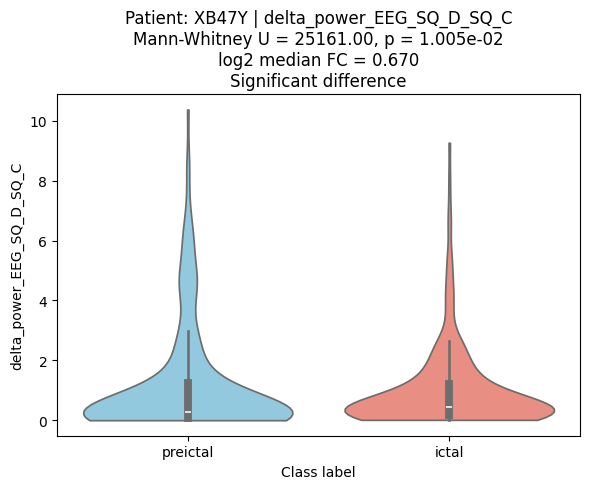

Plotting feature: theta_power_EEG_SQ_D_SQ_C


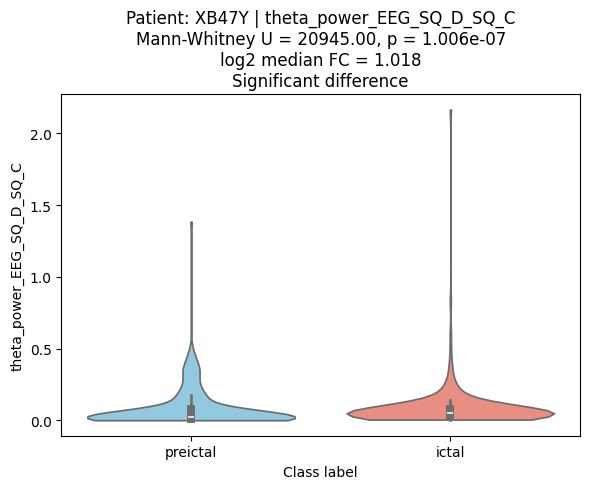

Plotting feature: alpha_power_EEG_SQ_D_SQ_C


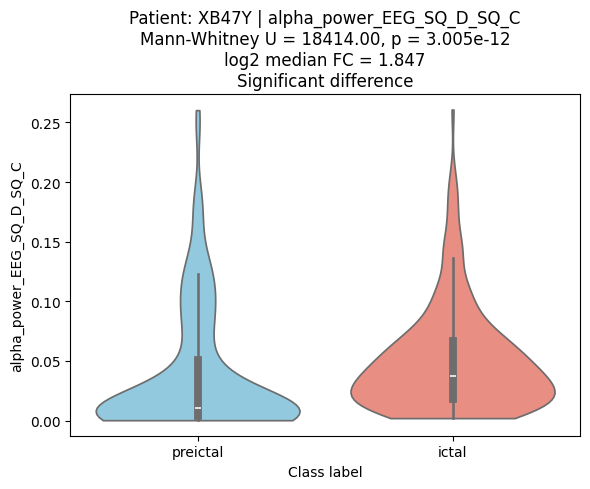

Plotting feature: beta_power_EEG_SQ_D_SQ_C


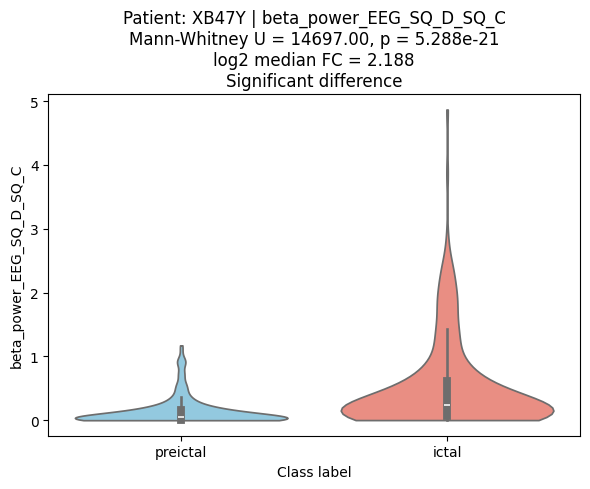

Plotting feature: gamma_power_EEG_SQ_D_SQ_C


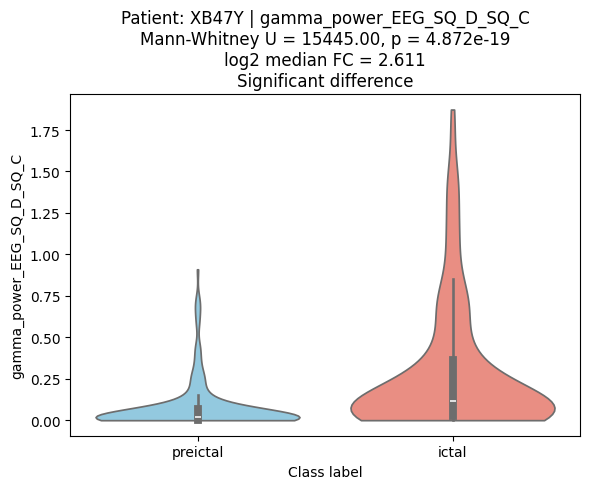

Plotting feature: peak_frequency_EEG_SQ_D_SQ_C


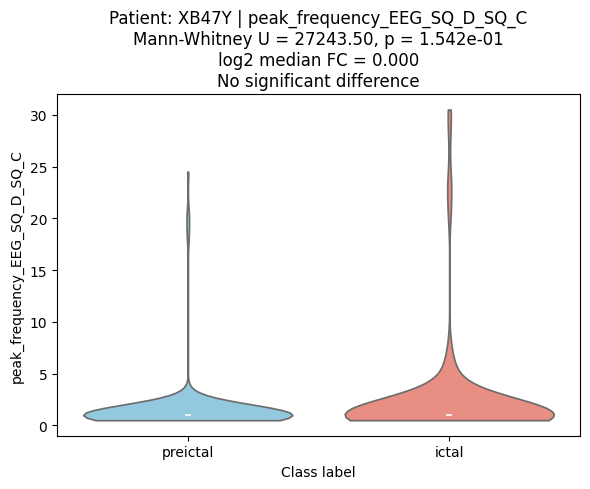

Plotting feature: delta_power_EEG_SQ_P_SQ_C


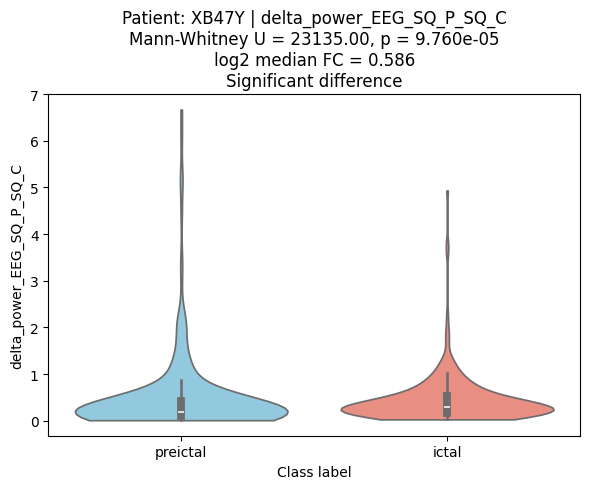

Plotting feature: theta_power_EEG_SQ_P_SQ_C


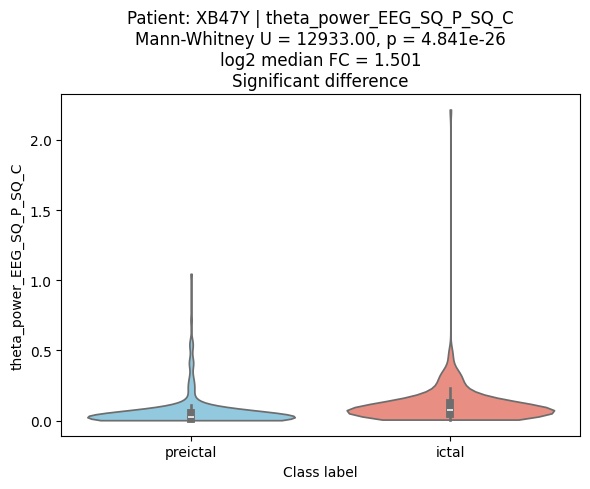

Plotting feature: alpha_power_EEG_SQ_P_SQ_C


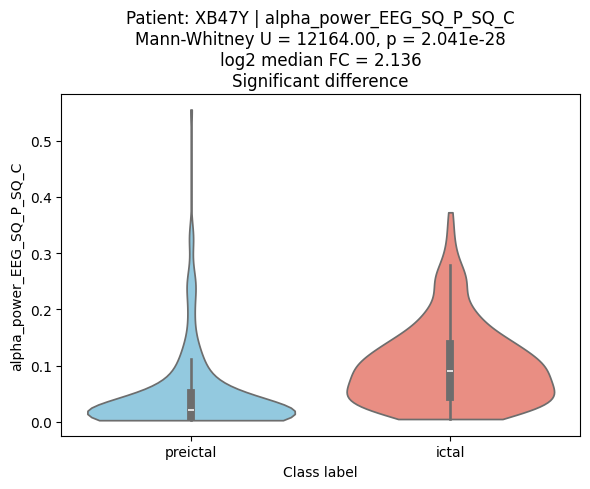

Plotting feature: beta_power_EEG_SQ_P_SQ_C


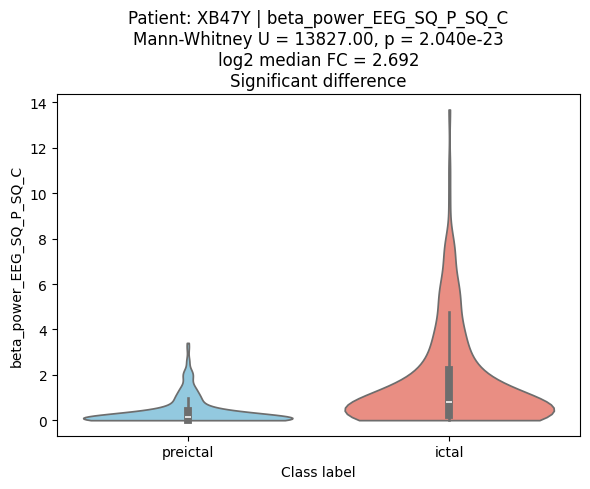

Plotting feature: gamma_power_EEG_SQ_P_SQ_C


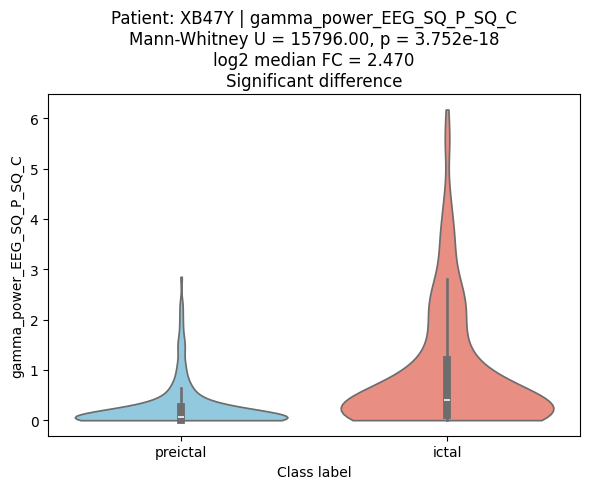

Plotting feature: peak_frequency_EEG_SQ_P_SQ_C


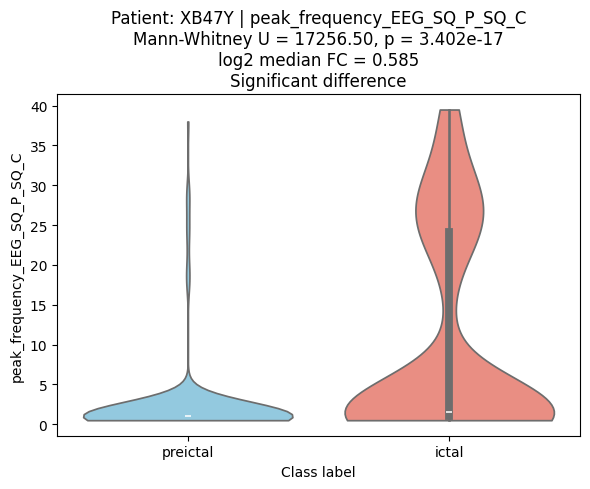

PDF saved to: Tomas_PS_DissertationKCL2026/Main_project/XB47Y_mannwhitney_violin_plots.pdf


In [112]:
## NOW TRY WITH LOG2FOLD
df_mannwhitney_results_log2fc = TEEG_FE.plot_mannwhitney_feature_violins_2_8_V3_log2fold(
    feature_cols=feature_cols,
    group_1_PREICTAL=group_1_PREICTAL,
    group_2_SEIZURE=group_2_SEIZURE,
    pdf_output_path=violin_pdf_path,
    alpha=alpha,
    show_plots=True,
    patient_id= "XB47Y"
)

In [114]:
df_mannwhitney_results_log2fc.head()

,patient_id,feature,n_preictal,n_ictal,mannwhitney_U_preictal,p_value,neg_log10_p,effect_size_log2_median_fold_change,abs_effect_size_log2_median_fold_change,fold_change_median_ictal_over_preictal,valid_log2_fold_change,median_preictal,median_ictal,mean_preictal,mean_ictal,median_difference_ictal_minus_preictal,mean_difference_ictal_minus_preictal,feature_subcategory,feature_color,result
0,XB47Y,alpha_power_EEG_SQ_P_SQ_C,231,252,12164.0,2.041385e-28,27.690075,2.136140,2.136140,4.395842,True,0.020448,0.089886,0.047197,0.101142,0.069438,0.053945,Band-specific spectral power,#D55E00,Significant difference
1,XB47Y,theta_power_EEG_SQ_P_SQ_C,231,252,12933.0,4.840631e-26,25.315098,1.501434,1.501434,2.831241,True,0.027298,0.077286,0.060969,0.111606,0.049988,0.050637,Band-specific spectral power,#D55E00,Significant difference
2,XB47Y,line_length_EEG_SQ_P_SQ_C,231,252,13623.0,5.291525e-24,23.276419,1.428707,1.428707,2.692052,True,563.538696,1517.075684,783.156250,1961.591187,953.536987,1178.434937,Temporal waveform change / signal complexity,#009E73,Significant difference
3,XB47Y,beta_power_EEG_SQ_P_SQ_C,231,252,13827.0,2.039889e-23,22.690393,2.691579,2.691579,6.460203,True,0.126441,0.816837,0.387882,1.638413,0.690396,1.250530,Band-specific spectral power,#D55E00,Significant difference
4,XB47Y,line_length_EEG_SQ_D_SQ_C,231,252,14046.0,8.516013e-23,22.069764,1.288987,1.288987,2.443563,True,330.244904,806.974365,438.252014,1061.924316,476.729462,623.672302,Temporal waveform change / signal complexity,#009E73,Significant difference


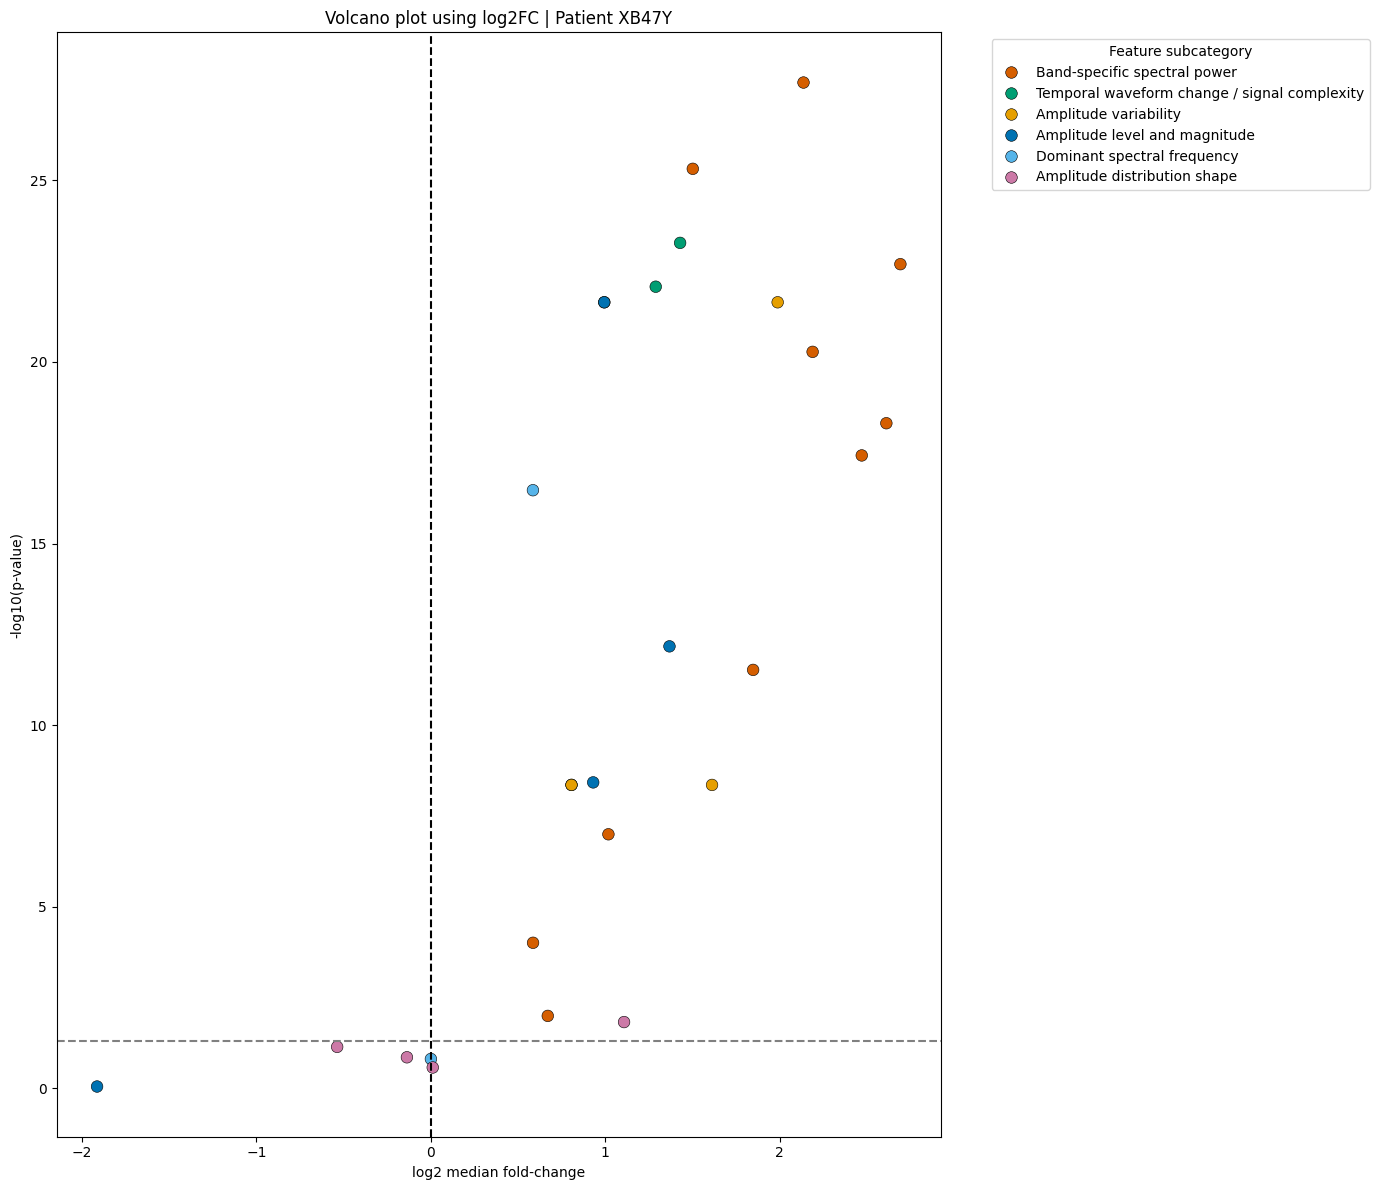

In [97]:
df_plot = df_mannwhitney_results_log2fc[
    df_mannwhitney_results_log2fc["valid_log2_fold_change"] == True
].copy()

plt.figure(figsize=(14, 12))

sns.scatterplot(
    data=df_plot,
    x="effect_size_log2_median_fold_change",
    y="neg_log10_p",
    hue="feature_subcategory",
    palette=TEEG_FE.get_feature_subcategory_palette(),
    s=70,
    edgecolor="black",
    linewidth=0.4
)

plt.axvline(0, linestyle="--", color="black")
plt.axhline(-np.log10(alpha), linestyle="--", color="grey")

plt.xlabel("log2 median fold-change")
plt.ylabel("-log10(p-value)")
plt.title(f"Volcano plot using log2FC | Patient {patient_id}")

plt.legend(
    title="Feature subcategory",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

log2FC = 1
→ ictal es 2 veces mayor que preictal

log2FC = -1
→ ictal es la mitad de preictal
→ o preictal es 2 veces mayor que ictal
n
eg

log2FC = 0.58
→ ictal es aproximadamente 1.5 veces mayor

log2FC = -0.58
→ ictal es aproximadamente 0.67 veces preictal
→ preictal es aproximadamente 1.5 veces mayor

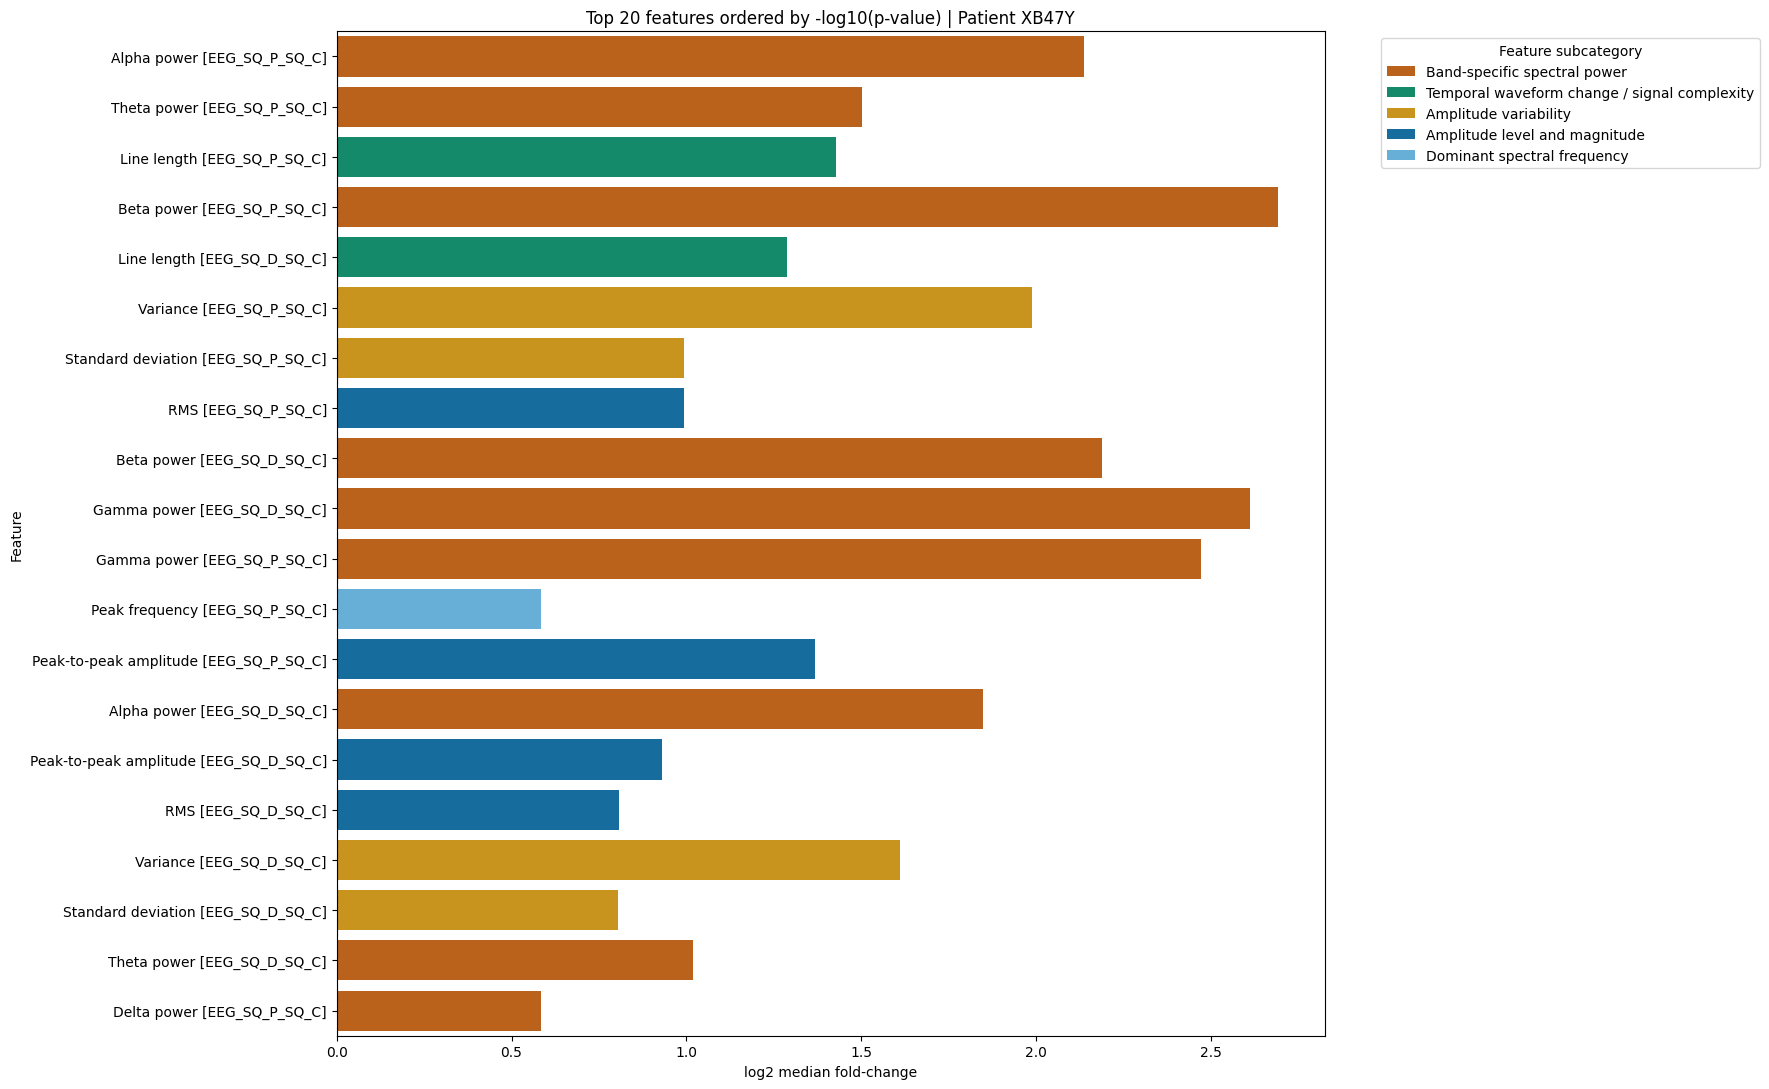

In [98]:
top_n = 20

df_bar = (
    df_mannwhitney_results_log2fc
    .query("valid_log2_fold_change == True")
    .sort_values("neg_log10_p", ascending=False)
    .head(top_n)
    .copy()
)

df_bar["feature_display"] = (
    df_bar["feature"]
    .apply(TEEG_FE.format_feature_label_for_plot)
)

feature_order = df_bar["feature_display"].tolist()

plt.figure(figsize=(18, 0.45 * len(df_bar) + 2))

sns.barplot(
    data=df_bar,
    y="feature_display",
    x="effect_size_log2_median_fold_change",
    hue="feature_subcategory",
    palette=TEEG_FE.get_feature_subcategory_palette(),
    order=feature_order,
    dodge=False
)

plt.axvline(0, linestyle="--", color="black")

plt.xlabel("log2 median fold-change")
plt.ylabel("Feature")
plt.title(
    f"Top {top_n} features ordered by -log10(p-value) | Patient {patient_id}"
)

plt.legend(
    title="Feature subcategory",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [84]:
# -------------------------------
# Check negative, zero, and non-positive medians per feature
# -------------------------------

feature_value_check = []

for feature in feature_cols:

    if feature not in group_1_PREICTAL.columns or feature not in group_2_SEIZURE.columns:
        continue

    preictal_values = pd.to_numeric(
        group_1_PREICTAL[feature],
        errors="coerce"
    ).replace([np.inf, -np.inf], np.nan).dropna()

    ictal_values = pd.to_numeric(
        group_2_SEIZURE[feature],
        errors="coerce"
    ).replace([np.inf, -np.inf], np.nan).dropna()

    if len(preictal_values) == 0 or len(ictal_values) == 0:
        continue

    all_values = pd.concat([preictal_values, ictal_values], axis=0)

    min_value = all_values.min()
    max_value = all_values.max()

    median_preictal = preictal_values.median()
    median_ictal = ictal_values.median()

    has_negative_values = (all_values < 0).any()
    has_zero_values = (all_values == 0).any()

    valid_for_log2fc = (
        median_preictal > 0 and
        median_ictal > 0
    )

    feature_value_check.append({
        "feature": feature,
        "min_value": min_value,
        "max_value": max_value,
        "median_preictal": median_preictal,
        "median_ictal": median_ictal,
        "has_negative_values": has_negative_values,
        "has_zero_values": has_zero_values,
        "valid_for_log2fc": valid_for_log2fc
    })

df_feature_value_check = pd.DataFrame(feature_value_check)

df_feature_value_check

,feature,min_value,max_value,median_preictal,median_ictal,has_negative_values,has_zero_values,valid_for_log2fc
0,mean_EEG_SQ_D_SQ_C,-0.160274,0.175667,-0.000436,-0.000700,True,False,False
1,std_EEG_SQ_D_SQ_C,0.059833,3.477012,0.675583,1.181054,False,False,True
2,var_EEG_SQ_D_SQ_C,0.003580,12.089616,0.456413,1.394898,False,False,True
3,rms_EEG_SQ_D_SQ_C,0.059834,3.478977,0.675585,1.181245,False,False,True
4,ptp_EEG_SQ_D_SQ_C,0.495154,20.305931,6.222886,11.859030,False,False,True
5,line_length_EEG_SQ_D_SQ_C,52.735535,4530.404785,330.244904,806.974365,False,False,True
6,skew_EEG_SQ_D_SQ_C,-3.893530,4.994149,0.679481,0.468135,True,False,True
7,kurtosis_EEG_SQ_D_SQ_C,-0.590918,82.288086,2.462992,2.239169,True,False,True
8,mean_EEG_SQ_P_SQ_C,-0.095200,0.080678,0.000681,0.000181,True,False,True
9,std_EEG_SQ_P_SQ_C,0.249218,5.271098,0.780851,1.555215,False,False,True


In [86]:
# -------------------------------
# Check negative, zero, and non-positive medians per feature
# -------------------------------

feature_value_check = []

for feature in feature_cols:

    if feature not in group_1_PREICTAL.columns or feature not in group_2_SEIZURE.columns:
        continue

    preictal_values = pd.to_numeric(
        group_1_PREICTAL[feature],
        errors="coerce"
    ).replace([np.inf, -np.inf], np.nan).dropna()

    ictal_values = pd.to_numeric(
        group_2_SEIZURE[feature],
        errors="coerce"
    ).replace([np.inf, -np.inf], np.nan).dropna()

    if len(preictal_values) == 0 or len(ictal_values) == 0:
        continue

    all_values = pd.concat([preictal_values, ictal_values], axis=0)

    min_value = all_values.min()
    max_value = all_values.max()

    median_preictal = preictal_values.median()
    median_ictal = ictal_values.median()

    n_total_values = len(all_values)

    n_negative_values = (all_values < 0).sum()
    n_zero_values = (all_values == 0).sum()
    n_non_positive_values = (all_values <= 0).sum()

    prop_negative_values = n_negative_values / n_total_values
    prop_zero_values = n_zero_values / n_total_values
    prop_non_positive_values = n_non_positive_values / n_total_values

    has_negative_values = n_negative_values > 0
    has_zero_values = n_zero_values > 0

    valid_for_log2fc = (
        median_preictal > 0 and
        median_ictal > 0
    )

    feature_value_check.append({
        "feature": feature,
        "min_value": min_value,
        "max_value": max_value,
        "median_preictal": median_preictal,
        "median_ictal": median_ictal,

        "n_total_values": n_total_values,
        "n_negative_values": n_negative_values,
        "n_zero_values": n_zero_values,
        "n_non_positive_values": n_non_positive_values,

        "prop_negative_values": prop_negative_values,
        "prop_zero_values": prop_zero_values,
        "prop_non_positive_values": prop_non_positive_values,

        "has_negative_values": has_negative_values,
        "has_zero_values": has_zero_values,
        "valid_for_log2fc": valid_for_log2fc
    })

df_feature_value_check = pd.DataFrame(feature_value_check)

df_feature_value_check

,feature,min_value,max_value,median_preictal,median_ictal,n_total_values,n_negative_values,n_zero_values,n_non_positive_values,prop_negative_values,prop_zero_values,prop_non_positive_values,has_negative_values,has_zero_values,valid_for_log2fc
0,mean_EEG_SQ_D_SQ_C,-0.160274,0.175667,-0.000436,-0.000700,483,251,0,251,0.519669,0.0,0.519669,True,False,False
1,std_EEG_SQ_D_SQ_C,0.059833,3.477012,0.675583,1.181054,483,0,0,0,0.000000,0.0,0.000000,False,False,True
2,var_EEG_SQ_D_SQ_C,0.003580,12.089616,0.456413,1.394898,483,0,0,0,0.000000,0.0,0.000000,False,False,True
3,rms_EEG_SQ_D_SQ_C,0.059834,3.478977,0.675585,1.181245,483,0,0,0,0.000000,0.0,0.000000,False,False,True
4,ptp_EEG_SQ_D_SQ_C,0.495154,20.305931,6.222886,11.859030,483,0,0,0,0.000000,0.0,0.000000,False,False,True
5,line_length_EEG_SQ_D_SQ_C,52.735535,4530.404785,330.244904,806.974365,483,0,0,0,0.000000,0.0,0.000000,False,False,True
6,skew_EEG_SQ_D_SQ_C,-3.893530,4.994149,0.679481,0.468135,483,75,0,75,0.155280,0.0,0.155280,True,False,True
7,kurtosis_EEG_SQ_D_SQ_C,-0.590918,82.288086,2.462992,2.239169,483,21,0,21,0.043478,0.0,0.043478,True,False,True
8,mean_EEG_SQ_P_SQ_C,-0.095200,0.080678,0.000681,0.000181,483,233,0,233,0.482402,0.0,0.482402,True,False,True
9,std_EEG_SQ_P_SQ_C,0.249218,5.271098,0.780851,1.555215,483,0,0,0,0.000000,0.0,0.000000,False,False,True


In [87]:
summary_log2fc_check = pd.DataFrame({
    "metric": [
        "Features with any negative values",
        "Features with any zero values",
        "Features valid for log2FC",
        "Average proportion of negative values per feature",
        "Average proportion of zero values per feature",
        "Average proportion of non-positive values per feature"
    ],
    "value": [
        df_feature_value_check["has_negative_values"].mean(),
        df_feature_value_check["has_zero_values"].mean(),
        df_feature_value_check["valid_for_log2fc"].mean(),
        df_feature_value_check["prop_negative_values"].mean(),
        df_feature_value_check["prop_zero_values"].mean(),
        df_feature_value_check["prop_non_positive_values"].mean()
    ]
})

summary_log2fc_check["percentage"] = summary_log2fc_check["value"] * 100

summary_log2fc_check

,metric,value,percentage
0,Features with any negative values,0.214286,21.428571
1,Features with any zero values,0.000000,0.000000
2,Features valid for log2FC,0.964286,96.428571
3,Average proportion of negative values per feature,0.056936,5.693582
4,Average proportion of zero values per feature,0.000000,0.000000
5,Average proportion of non-positive values per ...,0.056936,5.693582


In [88]:
df_problematic_log2fc = df_feature_value_check[
    df_feature_value_check["valid_for_log2fc"] == False
].copy()

df_problematic_log2fc.sort_values(
    "prop_non_positive_values",
    ascending=False
)

,feature,min_value,max_value,median_preictal,median_ictal,n_total_values,n_negative_values,n_zero_values,n_non_positive_values,prop_negative_values,prop_zero_values,prop_non_positive_values,has_negative_values,has_zero_values,valid_for_log2fc
0,mean_EEG_SQ_D_SQ_C,-0.160274,0.175667,-0.000436,-0.0007,483,251,0,251,0.519669,0.0,0.519669,True,False,False


### 5. PCA of features

#### 5.1 testing
- Data = preictal + ictal
- Features = all cols in feature_cols
- Channels = separated
- cleaning = NaN / Inf out
- Plot 1 = scatter PC1 vs PC2
- Plot 2 = biplot top 10 features/loadings

In [20]:
# -------------------------------
# Step 1: Prepare dataframe for PCA
# -------------------------------

df_pca = df_feat_ictalVspreictal_1min.copy()

# Sanity check: dataframe shape
print("PCA dataframe shape:", df_pca.shape)

# Check available class labels
print("\nClass label counts:")
print(df_pca["class_label"].value_counts())

PCA dataframe shape: (483, 41)

Class label counts:
class_label
2    252
1    231
Name: count, dtype: int64


In [21]:
# -------------------------------
# Step 2: Create readable labels for plotting
# -------------------------------

label_map = {
    1: "preictal",
    2: "ictal"
}

df_pca["label"] = df_pca["class_label"].map(label_map)

# Check if mapping worked
print("Readable label counts:")
print(df_pca["label"].value_counts())

# Check if any labels were not mapped
print("\nUnmapped labels:")
print(df_pca[df_pca["label"].isna()]["class_label"].unique())

Readable label counts:
label
ictal       252
preictal    231
Name: count, dtype: int64

Unmapped labels:
[]


In [22]:
import numpy as np

# -------------------------------
# Step 3: Select feature matrix X and clean invalid values
# -------------------------------

# Select only feature columns for PCA
X = df_pca[feature_cols].copy()

# Convert all feature columns to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Replace infinite values with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Keep only rows with complete feature values
valid_rows = X.dropna().index

X_clean = X.loc[valid_rows].copy()
df_pca_clean = df_pca.loc[valid_rows].copy()

# Sanity checks
print("Original X shape:", X.shape)
print("Clean X shape:", X_clean.shape)
print("Rows removed:", X.shape[0] - X_clean.shape[0])

print("\nClean label counts:")
print(df_pca_clean["label"].value_counts())

Original X shape: (483, 28)
Clean X shape: (483, 28)
Rows removed: 0

Clean label counts:
label
ictal       252
preictal    231
Name: count, dtype: int64


In [23]:
from sklearn.preprocessing import StandardScaler

# -------------------------------
# Step 4: Standardize features before PCA
# -------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_clean)

# Convert back to dataframe for easier inspection
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=feature_cols,
    index=X_clean.index
)

# Sanity checks
print("Scaled X shape:", X_scaled_df.shape)

print("\nMean after scaling, first 5 features:")
print(X_scaled_df.mean().head())

print("\nStandard deviation after scaling, first 5 features:")
print(X_scaled_df.std().head())
# Expected: 
#mean = 0
#standard deviation = 1


Scaled X shape: (483, 28)

Mean after scaling, first 5 features:
mean_EEG_SQ_D_SQ_C   -6.436076e-18
std_EEG_SQ_D_SQ_C     8.826618e-17
var_EEG_SQ_D_SQ_C     2.942206e-17
rms_EEG_SQ_D_SQ_C    -8.826618e-17
ptp_EEG_SQ_D_SQ_C     5.884412e-17
dtype: float64

Standard deviation after scaling, first 5 features:
mean_EEG_SQ_D_SQ_C    1.001037
std_EEG_SQ_D_SQ_C     1.001037
var_EEG_SQ_D_SQ_C     1.001037
rms_EEG_SQ_D_SQ_C     1.001037
ptp_EEG_SQ_D_SQ_C     1.001037
dtype: float64


In [24]:
from sklearn.decomposition import PCA

# -------------------------------
# Step 5: Run PCA
# -------------------------------

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

# Convert PCA output to dataframe
df_pca_scores = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])],
    index=X_clean.index
)

# Add labels back for plotting
df_pca_scores["label"] = df_pca_clean["label"].values
df_pca_scores["class_label"] = df_pca_clean["class_label"].values

# Sanity checks
print("PCA scores shape:", df_pca_scores.shape)
print("\nFirst rows:")
print(df_pca_scores[["PC1", "PC2", "label"]].head())
# there are gonna be as much PC as features there are (28)
# learn the PC from the scaled features
# it proyect every EEG window into a the new axis
# proyect cada ventana EEG en esos nuevos ejes


PCA scores shape: (483, 30)

First rows:
        PC1       PC2     label
0 -3.846860 -1.393994  preictal
1 -0.781845  2.911585  preictal
2 -2.125904 -1.431596  preictal
3 -1.925519 -2.854785  preictal
4 -2.024074 -2.600239  preictal


In [25]:
# -------------------------------
# Step 6: Explained variance
# -------------------------------

explained_var = pca.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

df_explained_variance = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_var))],
    "explained_variance_ratio": explained_var,
    "cumulative_variance": cumulative_var
})

print(df_explained_variance.head(10))
#PC1:explains the major variability part
#PC2:explains the second variability part
#PC3:explains the third variability part
# ...
# E.g:
# PC = 0.35
# PC1 explains the 35% of total variance of all features


     PC  explained_variance_ratio  cumulative_variance
0   PC1                  0.485641             0.485641
1   PC2                  0.127145             0.612787
2   PC3                  0.089804             0.702591
3   PC4                  0.054130             0.756721
4   PC5                  0.037961             0.794682
5   PC6                  0.035590             0.830272
6   PC7                  0.031538             0.861809
7   PC8                  0.028331             0.890141
8   PC9                  0.022462             0.912603
9  PC10                  0.017710             0.930314


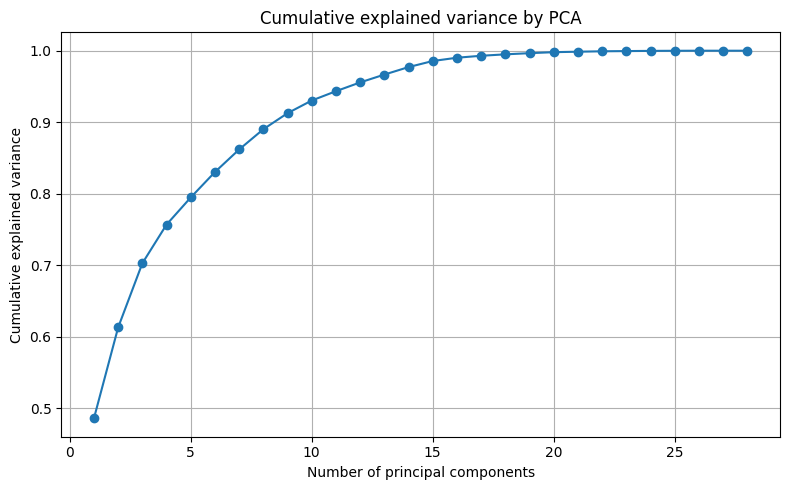

PC1 explains: 48.56%
PC2 explains: 12.71%
PC1 + PC2 explain: 61.28%


In [26]:
# -------------------------------
# Plot explained variance
# -------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(explained_var) + 1),
    cumulative_var,
    marker="o"
)

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative explained variance by PCA")

plt.grid(True)
plt.tight_layout()
plt.show()
print(f"PC1 explains: {explained_var[0]*100:.2f}%")
print(f"PC2 explains: {explained_var[1]*100:.2f}%")
print(f"PC1 + PC2 explain: {(explained_var[0] + explained_var[1])*100:.2f}%")

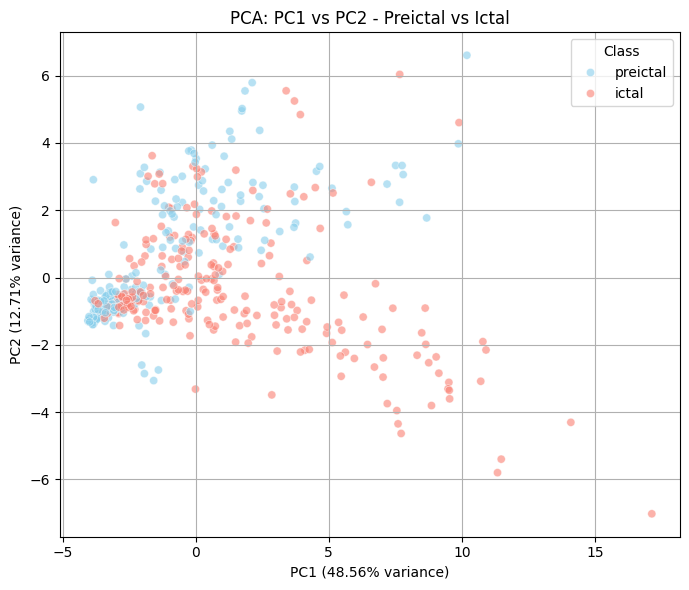

In [27]:
# -------------------------------
# Step 7: PCA scatter plot PC1 vs PC2
# -------------------------------



palette = {
    "preictal": "skyblue",
    "ictal": "salmon"
}

plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=df_pca_scores,
    x="PC1",
    y="PC2",
    hue="label",
    palette=palette,
    alpha=0.6,
    s=35
)

plt.xlabel(f"PC1 ({explained_var[0]*100:.2f}% variance)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.2f}% variance)")
plt.title("PCA: PC1 vs PC2 - Preictal vs Ictal")

plt.legend(title="Class")
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
# -------------------------------
# Step 8: PCA loadings
# -------------------------------

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])],
    index=feature_cols
)

print("Loadings shape:", loadings.shape)
print("\nFirst rows:")
print(loadings[["PC1", "PC2"]].head())

Loadings shape: (28, 28)

First rows:
                         PC1       PC2
mean_EEG_SQ_D_SQ_C -0.010694 -0.000801
std_EEG_SQ_D_SQ_C   0.236237  0.201664
var_EEG_SQ_D_SQ_C   0.223449  0.194604
rms_EEG_SQ_D_SQ_C   0.236208  0.201721
ptp_EEG_SQ_D_SQ_C   0.220513  0.219348


In [30]:
# -------------------------------
# Step 9: Top contributing features to PC1 and PC2
# -------------------------------

loadings["abs_PC1"] = loadings["PC1"].abs()
loadings["abs_PC2"] = loadings["PC2"].abs()

loadings["combined_PC1_PC2"] = (
    loadings["abs_PC1"] + loadings["abs_PC2"]
)

top_10_loadings = (
    loadings
    .sort_values("combined_PC1_PC2", ascending=False)
    .head(10)
)

top_10_loadings[["PC1", "PC2", "abs_PC1", "abs_PC2", "combined_PC1_PC2"]]

,PC1,PC2,abs_PC1,abs_PC2,combined_PC1_PC2
delta_power_EEG_SQ_D_SQ_C,0.136370,0.348091,0.136370,0.348091,0.484461
ptp_EEG_SQ_D_SQ_C,0.220513,0.219348,0.220513,0.219348,0.439861
rms_EEG_SQ_D_SQ_C,0.236208,0.201721,0.236208,0.201721,0.437929
std_EEG_SQ_D_SQ_C,0.236237,0.201664,0.236237,0.201664,0.437901
alpha_power_EEG_SQ_D_SQ_C,0.207013,0.227724,0.207013,0.227724,0.434737
beta_power_EEG_SQ_P_SQ_C,0.239901,-0.194689,0.239901,0.194689,0.434589
gamma_power_EEG_SQ_D_SQ_C,0.240798,-0.189632,0.240798,0.189632,0.430430
line_length_EEG_SQ_D_SQ_C,0.247880,-0.181796,0.247880,0.181796,0.429676
beta_power_EEG_SQ_D_SQ_C,0.240443,-0.186126,0.240443,0.186126,0.426569
line_length_EEG_SQ_P_SQ_C,0.248356,-0.175946,0.248356,0.175946,0.424303
